# TP1 · Task 1 — Understand, Audit and Prepare the Data
## Classification of Abnormal Electric-Vehicle Charging Sessions

**Course:** Mineração de Dados (MINDD) · 2026/2027, 1st semester · ISEP / DEI
**Dataset:** educational adaptation of the *China EV Charging Dataset* (Zhang et al., 2025) — 441,077 charging transactions, 92 charging posts, 13 stations, 3 districts, 2020–2021.
**Deliverable of this week:** this notebook + a concise report section (decisions, evidence, results, conclusions).

---

### How to read this notebook

The project question is:

> *To what extent can contextual, operational and historical information available **at the beginning** of a charging session be used to predict its abnormal termination?*

Everything in this notebook is organised around one constraint: **the prediction is made at session start**. Consequently, every data-preparation decision is judged against three questions:

1. **Is it legitimate?** Could this information exist at the moment the session starts (no look-ahead / leakage)?
2. **Is it supported by evidence?** Each cleaning, transformation, grouping, capping or removal decision is preceded by an *investigation* and followed by an *interpretation*.
3. **Does it respect the methodological rule of the course (slides "Data Preparation", §*Prevent data leakage*)?** Any operation that **learns parameters from data** (imputation values, scaling, category encoding, outlier thresholds, resampling, feature selection, dimensionality reduction) is fitted **on the training period only**, and is documented **separately** in the *learned-operations ledger* (Section 13).

### Roadmap (mapped to the four major tasks of the data-preparation course + the project-specific requirements)

| § | Section | Course task | Project requirement addressed |
|---|---------|-------------|-------------------------------|
| 1 | Problem framing and methodological principles | — | prediction moment, leakage, temporal validation |
| 2 | Structural audit and variable dictionary | Data understanding | data types, variable meaning, availability at prediction time |
| 3 | Cleaning (stateless) and consistency checks | Data cleaning | duplicates, inconsistent observations, data-quality problems |
| 4 | Target construction and validation | Data selection | `is_Abnormal` is **not** supplied — it must be derived and validated |
| 5 | Temporal coverage and stability | Data understanding | volume, prevalence, predictor distributions, post/user activity over time |
| 6 | Availability and leakage audit | Feature reduction (leakers) | operational availability of every predictor |
| 7 | Exploratory analysis of the legitimate predictors | Data understanding | relationships with the target, cold-start, privacy |
| 8 | Missing values | Data cleaning | structural vs. random missingness |
| 9 | Outliers | Data cleaning / outliers | univariate and multivariate detection, retain/transform/cap/remove |
| 10 | Data selection: chronological split, burn-in, sampling | Data selection / sampling | evaluation design that respects time |
| 11 | Stateless feature engineering and redundancy | Transformation / reduction | derived features, deterministic redundancy |
| 12 | Collinearity and dimensionality (VIF, PCA) | Feature reduction | multicollinearity, PCA evaluated |
| 13 | Learned transformations (fit on train only) + ledger | Transformation | imputation, encoding, scaling, capping — documented separately |
| 14 | Class imbalance | Unbalanced classes | resampling evaluated with evidence |
| 15 | Preliminary feature-group ablation and diagnostics | Feature selection | contribution of each variable group, cold start |
| 16 | Persisted artefacts and integrity checks | — | reproducibility, leakage tests |
| 17 | Synthesis | — | the five items required at the end of Task 1 |

## 0. Environment, configuration and reproducibility

All random operations use a single seed. The paths are relative, so the notebook runs from the folder that contains `Charging_Data_educational.csv`.
Required packages: `pandas`, `numpy`, `scipy`, `scikit-learn`, `matplotlib`, `seaborn`, `pyarrow` (optional, for parquet), `imbalanced-learn` (optional, only for the SMOTE experiment in §14).

In [ ]:
import json
import platform
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingClassifier, IsolationForest
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss, log_loss,
                             precision_recall_curve, roc_auc_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (FunctionTransformer, OneHotEncoder, OrdinalEncoder,
                                   StandardScaler)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ----------------------------------------------------------------------------- configuration
SEED = 42
RNG = np.random.default_rng(SEED)
DATA_PATH = Path("Charging_Data_educational.csv")
OUT_DIR = Path("prepared")            # persisted artefacts (Section 16)
FIG_DIR = OUT_DIR / "figures"         # figures reused in the report
OUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

TARGET = "is_Abnormal"

# Chronological design (justified in Sections 5 and 10 — declared here only so that they are defined once).
BURN_IN_END = pd.Timestamp("2020-04-01")   # sessions before this date are excluded from model development
TRAIN_END = pd.Timestamp("2021-07-01")     # train:      [2020-04-01, 2021-07-01)
VAL_END = pd.Timestamp("2021-10-01")       # validation: [2021-07-01, 2021-10-01)
                                           # test:       [2021-10-01, end)   -> untouched until the final evaluation

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "axes.titleweight": "bold",
                     "axes.titlesize": 11, "axes.labelsize": 10, "legend.frameon": False})
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

C_NORMAL, C_ABN, C_NEUTRAL = "#4C72B0", "#C44E52", "#7F7F7F"

print(f"python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__} | "
      f"platform {platform.system()} {platform.machine()}")

### 0.1 Small utilities

* `DECISIONS` — a decision log. Every non-trivial preparation decision is registered together with its evidence; the full log is displayed in the synthesis (§17).
* `prevalence_table` — abnormal-session prevalence per group with **Wilson 95% intervals**. With 441k rows almost every difference is "statistically significant", so intervals and effect sizes (not p-values alone) are used to judge relevance.
* `psi` — *Population Stability Index*, used to quantify the drift of a predictor between a reference period and a later period (rule of thumb: <0.10 stable, 0.10–0.25 moderate shift, >0.25 major shift).

In [2]:
DECISIONS: list[dict] = []


def log_decision(section: str, topic: str, decision: str, evidence: str, learned: bool = False) -> None:
    """Register a preparation decision in the global decision log (displayed in Section 17)."""
    DECISIONS.append({"§": section, "topic": topic, "decision": decision, "evidence": evidence,
                      "learned from data?": "yes (train only)" if learned else "no"})


def savefig(fig, name: str) -> None:
    """Save a figure for the report and display it."""
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()


def wilson_interval(k, n, z: float = 1.96):
    """Wilson score interval for a binomial proportion (vectorised)."""
    k, n = np.asarray(k, dtype=float), np.asarray(n, dtype=float)
    p = np.divide(k, n, out=np.full_like(k, np.nan), where=n > 0)
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return centre - half, centre + half


def prevalence_table(frame: pd.DataFrame, by, target: str = TARGET, min_n: int = 1) -> pd.DataFrame:
    """Number of sessions, number of abnormal sessions, prevalence and Wilson 95% CI per group."""
    g = frame.groupby(by, observed=True)[target].agg(n="size", abnormal="sum")
    g = g[g["n"] >= min_n].copy()
    g["prevalence"] = g["abnormal"] / g["n"]
    g["ci_low"], g["ci_high"] = wilson_interval(g["abnormal"], g["n"])
    return g


def psi(reference: pd.Series, current: pd.Series, bins: int = 10) -> float:
    """Population Stability Index with quantile bins learned on the reference period."""
    ref, cur = reference.dropna(), current.dropna()
    edges = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:                      # (near-)constant variable
        return np.nan
    edges[0], edges[-1] = -np.inf, np.inf
    p_ref = np.clip(np.histogram(ref, edges)[0] / len(ref), 1e-4, None)
    p_cur = np.clip(np.histogram(cur, edges)[0] / len(cur), 1e-4, None)
    return float(np.sum((p_cur - p_ref) * np.log(p_cur / p_ref)))


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Bias-corrected Cramér's V between two categorical variables (effect size of a chi-square test)."""
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct, correction=False)[0]
    n = ct.to_numpy().sum()
    phi2 = max(0.0, chi2 / n - (ct.shape[0] - 1) * (ct.shape[1] - 1) / (n - 1))
    r = ct.shape[0] - (ct.shape[0] - 1) ** 2 / (n - 1)
    k = ct.shape[1] - (ct.shape[1] - 1) ** 2 / (n - 1)
    return float(np.sqrt(phi2 / max(min(k - 1, r - 1), 1e-12)))


def auc_symmetric(y, score) -> float:
    """Direction-agnostic univariate ROC-AUC: max(AUC, 1-AUC). 0.5 = no signal, 1.0 = perfect."""
    a = roc_auc_score(y, score)
    return max(a, 1 - a)

---
## 1. Problem framing and methodological principles

### 1.1 The prediction moment and what it implies

A session is scored **when it starts** (`Start Time`). The complete transaction record contains information generated *during* and *after* the session (energy delivered, cost, payment, end time, end cause). Those variables describe the outcome and cannot be used as predictors. The dataset also contains **pre-computed historical attributes** built chronologically from *completed* sessions of the same post and the same user, and **concurrency** information — these are legitimate, but their validity must be **verified**, not assumed (§4.3) and their operational implications discussed (§7.6, §17).

### 1.2 Three consequences that drive the whole design

| Principle | Consequence in this notebook |
|-----------|------------------------------|
| **No look-ahead** | Post-hoc variables are excluded (§6); history attributes are re-computed from timestamps to prove they only use sessions completed before the start (§4.3). |
| **Temporal dependence** | Random splits would leak future regimes into the training set. A **chronological** split with a *purge* of sessions whose outcome was not yet known is used (§10). Temporal stability is investigated *before* modelling (§5). |
| **Learn only from the past** | Every fitted transformation is fitted on the training period only and applied unchanged to validation/test (§13); the course slides call this "preventing data leakage". |

### 1.3 Working definition of "abnormal"

The file does **not** contain `is_Abnormal`. It contains `end_cause` (15 categories). Which causes count as abnormal is an *assumption* that materially changes the problem, so it is **tested against the data** in §4 (the pre-computed abnormal counts supplied with the dataset act as an independent oracle).

---
## 2. Structural audit and variable dictionary

**Goal:** know exactly what each column is, how it is typed on disk, and — most importantly — *when* in the session lifecycle it becomes known.

In [3]:
t0 = time.time()
raw = pd.read_csv(DATA_PATH)
print(f"Loaded {raw.shape[0]:,} rows x {raw.shape[1]} columns in {time.time() - t0:.1f}s "
      f"(memory: {raw.memory_usage(deep=True).sum() / 1e6:,.0f} MB)")
display(raw.head(3).T.rename(columns=lambda c: f"row {c}"))

Loaded 441,077 rows x 47 columns in 1.5s (memory: 225 MB)


,row 0,row 1,row 2
UserID,11182,27510,10877
Charging Post ID,24,67,45
Location Information,Shopping Mall,Government Agency,Park B
District Name,Tongxiang,Xiuzhou,Tongxiang
Order creation time,2019-12-31 21:26:58\t,2019-12-31 21:50:58\t,2019-12-31 22:19:34\t
Transaction power/kwh,37.6500,12.0300,44.0400
Electricity cost/Yuan,33.6200,10.7400,39.3300
Service charge/Yuan,26.6200,8.5100,31.1400
Transaction Amount/Yuan,60.2400,19.2500,70.4700
Actual Payment/Yuan,60.2400,19.2500,70.4700


### 2.1 Types, cardinality and raw-text hygiene

Before parsing anything, the raw text columns are audited. Identical-looking labels that differ only by hidden characters (trailing tabs/spaces) would silently create *duplicated categories* and break time parsing.

In [4]:
dtype_table = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "n_unique": raw.nunique(),
    "n_missing": raw.isna().sum(),
    "example": raw.iloc[0].astype(str).str.slice(0, 32),
})
display(dtype_table)

text_cols = raw.select_dtypes(include=["object", "string"]).columns.tolist()
ws_audit = pd.DataFrame({
    c: {
        "rows with leading/trailing whitespace": int((raw[c] != raw[c].str.strip()).sum()),
        "rows containing a TAB": int(raw[c].str.contains("\t", regex=False).sum()),
        "n_unique (raw)": raw[c].nunique(),
        "n_unique (stripped)": raw[c].str.strip().nunique(),
    } for c in text_cols
}).T
display(ws_audit)

,dtype,n_unique,n_missing,example
UserID,int64,56115,0,11182
Charging Post ID,int64,92,0,24
Location Information,str,13,0,Shopping Mall
District Name,str,3,0,Tongxiang
Order creation time,str,438764,0,2019-12-31 21:26:58\t
Transaction power/kwh,float64,7053,0,37.65
Electricity cost/Yuan,float64,6320,0,33.62
Service charge/Yuan,float64,5129,0,26.62
Transaction Amount/Yuan,float64,8487,0,60.24
Actual Payment/Yuan,float64,8412,0,60.24


,rows with leading/trailing whitespace,rows containing a TAB,n_unique (raw),n_unique (stripped)
Location Information,18370,18370,13,13
District Name,0,0,3,3
Order creation time,441077,441077,438764,438764
Start Time,0,0,438689,438689
End Time,0,0,438679,438679
Payment time,441077,441077,421831,421831
end_cause,0,0,15,15
tariff_period,0,0,7,7


**Interpretation.**
* `Order creation time` and `Payment time` carry a **trailing TAB on every row**; `Location Information` carries one for `Industrial Park` (18,370 rows). Parsing without stripping would either fail or (for `Location Information`) create a phantom category `"Industrial Park\t"`.
* The number of unique labels does not change after stripping (13 locations) *because the un-stripped variant is the only one present* — the risk is therefore latent (a future extract that mixes both spellings would create two categories). Stripping is a **stateless, lossless** operation, adopted in §3.
* The four timestamp columns are read as text and must be parsed explicitly.
* Only four columns contain missing values, all of them "time since previous event" attributes — investigated in §8.

### 2.2 Variable dictionary and availability at prediction time

The dictionary is built programmatically (so that no column can be forgotten — an assertion checks it) and classifies each variable by **role** and by **availability at the moment the session starts**:

* `at start` — legitimately available;
* `borderline` — timing is ambiguous and needs empirical scrutiny (§6);
* `post-hoc` — generated during/after the session (leakage);
* `outcome source` — used only to construct the target;
* `identifier` — key field, not a predictor by itself (course slide *Features to remove → key fields*).

In [5]:
HIST_POST = [c for c in raw.columns if c.startswith("post_")]
HIST_USER = [c for c in raw.columns if c.startswith("user_") and c != "user_active_sessions_at_start"] + ["is_new_user"]
CONCURRENCY = ["user_active_sessions_at_start"]

BASE_INFO = {
    "UserID":                  ("identifier", "identifier", "pseudonymous account id; 56,115 distinct values"),
    "Charging Post ID":        ("identifier / location", "at start", "physical post (92); nested in a station"),
    "Location Information":    ("location", "at start", "station type/name (13); each post belongs to exactly one"),
    "District Name":           ("location", "at start", "district (3); each station belongs to exactly one"),
    "Order creation time":     ("timestamp", "borderline", "recorded around the start time, sometimes AFTER it (see §6.2)"),
    "Start Time":              ("timestamp", "at start", "defines the prediction moment"),
    "End Time":                ("timestamp", "post-hoc", "known only when the session ends"),
    "Payment time":            ("timestamp", "post-hoc", "recorded after the session"),
    "Transaction power/kwh":   ("transaction", "post-hoc", "energy delivered during the session"),
    "Electricity cost/Yuan":   ("transaction", "post-hoc", "cost of the energy delivered"),
    "Service charge/Yuan":     ("transaction", "post-hoc", "service fee of the transaction"),
    "Transaction Amount/Yuan": ("transaction", "post-hoc", "= electricity cost + service charge"),
    "Actual Payment/Yuan":     ("transaction", "post-hoc", "amount effectively paid"),
    "end_cause":               ("outcome", "outcome source", "reason for termination -> source of the target"),
    "Temperature(℃)":          ("weather", "at start", "assumed forecast/estimate (task statement); daily value per district"),
    "Relative Humidity(%)":    ("weather", "at start", "assumed forecast/estimate (task statement); daily value per district"),
    "Precipitation(mm)":       ("weather", "at start", "assumed forecast/estimate (task statement); daily value per district"),
    "electricity_price":       ("tariff", "at start", "function of the start time"),
    "tariff_period":           ("tariff", "at start", "function of the start time"),
}


def describe_column(col: str) -> tuple[str, str, str]:
    if col in BASE_INFO:
        return BASE_INFO[col]
    if col in HIST_POST:
        return ("history: post", "at start", "computed from previous *completed* sessions of the same post")
    if col in CONCURRENCY:
        return ("concurrency", "at start", "other sessions of the same account already active at start")
    if col in HIST_USER:
        return ("history: user", "at start", "computed from previous *completed* sessions of the same user")
    raise KeyError(col)


dictionary = pd.DataFrame(
    [(c, *describe_column(c)) for c in raw.columns],
    columns=["column", "group", "availability", "meaning / note"],
)
assert len(dictionary) == raw.shape[1], "every column must be classified"
display(dictionary.groupby("availability").size().rename("n_columns").to_frame())
display(dictionary.style.hide(axis="index"))

,n_columns
availability,
at start,37
borderline,1
identifier,1
outcome source,1
post-hoc,7


column,group,availability,meaning / note
UserID,identifier,identifier,"pseudonymous account id; 56,115 distinct values"
Charging Post ID,identifier / location,at start,physical post (92); nested in a station
Location Information,location,at start,station type/name (13); each post belongs to exactly one
District Name,location,at start,district (3); each station belongs to exactly one
Order creation time,timestamp,borderline,"recorded around the start time, sometimes AFTER it (see §6.2)"
Transaction power/kwh,transaction,post-hoc,energy delivered during the session
Electricity cost/Yuan,transaction,post-hoc,cost of the energy delivered
Service charge/Yuan,transaction,post-hoc,service fee of the transaction
Transaction Amount/Yuan,transaction,post-hoc,= electricity cost + service charge
Actual Payment/Yuan,transaction,post-hoc,amount effectively paid


**Reading the dictionary.**
* 26 of the 47 columns are the pre-computed **history** attributes (16 for the post, 10 + `is_new_user` for the user) plus one concurrency variable; they are the only *operational* signals of the past and will be studied as a group (ablation, §15).
* 9 columns are clearly **post-hoc** and `end_cause` is the **outcome source**. Their exclusion is not a matter of taste: §6 shows empirically how strongly they leak.
* `Order creation time` is the only genuinely ambiguous timestamp and is analysed on its own in §6.2.

---
## 3. Cleaning (stateless) and consistency checks

**Principle (project statement):** *potential data-quality problems must be investigated before corrective action is taken.* The cell below performs only **lossless, stateless** operations (whitespace stripping, timestamp parsing, column renaming). Nothing is removed, imputed or capped yet.

In [6]:
RENAME = {
    "UserID": "user_id", "Charging Post ID": "post_id", "Location Information": "location", "District Name": "district",
    "Order creation time": "order_time", "Transaction power/kwh": "energy_kwh", "Electricity cost/Yuan": "electricity_cost",
    "Service charge/Yuan": "service_charge", "Transaction Amount/Yuan": "amount", "Actual Payment/Yuan": "actual_payment",
    "Start Time": "start_time", "End Time": "end_time", "Payment time": "payment_time",
    "Temperature(℃)": "temperature", "Relative Humidity(%)": "humidity", "Precipitation(mm)": "precipitation",
}
TIME_COLS = ["order_time", "start_time", "end_time", "payment_time"]

df = raw.copy()
df.insert(0, "row_id", np.arange(len(df)))               # traceability to the original file
for c in text_cols:                                      # (1) whitespace hygiene (lossless)
    df[c] = df[c].str.strip()
df = df.rename(columns=RENAME)                           # (2) snake_case names, no spaces/units in identifiers
for c in TIME_COLS:                                      # (3) explicit timestamp parsing (fails loudly on any anomaly)
    df[c] = pd.to_datetime(df[c], format="%Y-%m-%d %H:%M:%S", errors="coerce")

assert df[TIME_COLS].notna().all().all(), "unparseable timestamps"
assert df["start_time"].is_monotonic_increasing, "file is expected to be sorted by start_time"
print("Timestamps parsed without failures; the file is already sorted chronologically by start_time.")
print("Observation window (start_time):", df["start_time"].min(), "->", df["start_time"].max())
log_decision("3", "Text hygiene / parsing", "Strip whitespace; parse timestamps explicitly; snake_case names.",
             "Trailing TAB on 100% of `Order creation time`/`Payment time` and on 18,370 `Location Information` rows.")

Timestamps parsed without failures; the file is already sorted chronologically by start_time.
Observation window (start_time): 2019-12-31 21:27:03 -> 2021-12-31 23:52:14


### 3.1 Duplicated observations

Three levels are checked because "duplicate" can mean different things: an exact repeated row, the same *physical event* (same account, post and start second), or a *logically impossible* repetition (two sessions starting at the same second on the same post).

In [7]:
dup_checks = pd.DataFrame([
    ("Exact duplicate rows (all original columns)", int(raw.duplicated().sum())),
    ("Same user + post + start_time", int(df.duplicated(["user_id", "post_id", "start_time"]).sum())),
    ("Same user + post + start_time + end_time", int(df.duplicated(["user_id", "post_id", "start_time", "end_time"]).sum())),
    ("Same post + start_time (impossible for a single post)", int(df.duplicated(["post_id", "start_time"]).sum())),
    ("Same user + start_time (different posts)", int(df.duplicated(["user_id", "start_time"]).sum())),
], columns=["check", "n_rows"])
display(dup_checks)

same_second = df[df.duplicated(["user_id", "start_time"], keep=False)].sort_values(["user_id", "start_time"])
print("Accounts involved in same-second starts:", same_second["user_id"].nunique(),
      "| distinct posts per pair:", same_second.groupby(["user_id", "start_time"])["post_id"].nunique().unique())
display(same_second[["user_id", "post_id", "start_time", "end_time", "end_cause"]].head(6))

,check,n_rows
0,Exact duplicate rows (all original columns),0
1,Same user + post + start_time,0
2,Same user + post + start_time + end_time,0
3,Same post + start_time (impossible for a singl...,0
4,Same user + start_time (different posts),17


Accounts involved in same-second starts: 15 | distinct posts per pair: [2]


,user_id,post_id,start_time,end_time,end_cause
167535,23,4,2020-12-04 11:13:49,2020-12-04 11:30:37,BMS failure
167536,23,74,2020-12-04 11:13:49,2020-12-04 12:02:37,User stops charging
34710,39,12,2020-05-20 23:55:30,2020-05-21 03:24:28,Charging ends normally
34711,39,47,2020-05-20 23:55:30,2020-05-21 00:43:06,Charging ends normally
360955,39,27,2021-09-30 23:31:00,2021-10-01 00:52:49,Charging ends normally
360956,39,63,2021-09-30 23:31:00,2021-09-30 23:35:37,User stops charging


**Interpretation.** No exact or logical duplicates exist (a post never starts two sessions in the same second). The only repetition is 17 *same account, same second, different posts* pairs — consistent with **fleet/operator accounts** starting several vehicles simultaneously (confirmed in §7.5 and by `user_active_sessions_at_start`). They are legitimate observations and are **retained**.

### 3.2 Logical and temporal consistency

Each check targets a relation that *must* hold if the data are coherent. For every violation the table states the action; ambiguous cases are examined graphically below.

In [8]:
dur_h = (df["end_time"] - df["start_time"]).dt.total_seconds() / 3600
order_minus_start_min = (df["order_time"] - df["start_time"]).dt.total_seconds() / 60      # >0: order stamped AFTER the start
pay_minus_end_h = (df["payment_time"] - df["end_time"]).dt.total_seconds() / 3600
amount_gap = (df["amount"] - (df["electricity_cost"] + df["service_charge"])).abs()

post_windows = [("post_previous_sessions_1D", "post_previous_sessions_7D", "post_previous_sessions_30D"),
                ("post_previous_abnormal_1D", "post_previous_abnormal_7D", "post_previous_abnormal_30D")]
user_windows = [("user_previous_sessions_30D", "user_previous_sessions_180D", "user_previous_sessions_730D"),
                ("user_previous_abnormal_30D", "user_previous_abnormal_180D", "user_previous_abnormal_730D")]
mono_viol = sum(int(((df[a] > df[b]) | (df[b] > df[c])).sum()) for a, b, c in post_windows + user_windows)
abn_gt_sess_viol = int(sum((df[a.replace("sessions", "abnormal")] > df[a]).sum() for grp in (post_windows[0], user_windows[0]) for a in grp))
rate_cols = [c for c in df.columns if c.endswith(tuple(f"rate_{w}" for w in ("1D", "7D", "30D", "180D", "730D")))]

consistency = pd.DataFrame([
    ("end_time < start_time", int((dur_h < 0).sum()), "none -> no action"),
    ("zero-duration sessions (end == start)", int((dur_h == 0).sum()), "kept: they are real (instant faults) and post-hoc only"),
    ("duration >= 24 h", int((dur_h >= 24).sum()), f"none; maximum = {dur_h.max():.3f} h -> sessions appear capped/censored at 24 h"),
    ("order_time stamped AFTER start_time", int((order_minus_start_min > 0).sum()), "ambiguous availability -> analysed in §6.2, excluded as predictor"),
    ("order_time > 10 min after start_time", int((order_minus_start_min > 10).sum()), "maximum lag = {:.0f} min".format(order_minus_start_min.max())),
    ("payment_time < end_time", int((pay_minus_end_h < 0).sum()), "post-hoc variable, irrelevant for prediction"),
    ("amount != electricity_cost + service_charge (>0.005)", int((amount_gap > 0.005).sum()), "none -> amounts are additive (post-hoc anyway)"),
    ("actual_payment > amount", int((df["actual_payment"] > df["amount"] + 0.005).sum()), "none"),
    ("actual_payment < amount (discounts/coupons?)", int((df["actual_payment"] < df["amount"] - 0.005).sum()), "post-hoc, irrelevant for prediction"),
    ("negative energy/cost/payment", int((df[["energy_kwh", "electricity_cost", "service_charge", "amount", "actual_payment"]] < 0).sum().sum()), "none"),
    ("history windows not monotone (1D<=7D<=30D, 30D<=180D<=730D)", mono_viol, "none -> windows are nested as expected"),
    ("abnormal count > session count (any window)", abn_gt_sess_viol, "none"),
    ("smoothed rate outside (0, 1]", int(((df[rate_cols] <= 0) | (df[rate_cols] > 1)).sum().sum()), "none -> smoothing prevents 0/1 rates"),
], columns=["check", "n_violations", "assessment / action"])
display(consistency.style.hide(axis="index"))

check,n_violations,assessment / action
end_time < start_time,0,none -> no action
zero-duration sessions (end == start),5,kept: they are real (instant faults) and post-hoc only
duration >= 24 h,0,none; maximum = 23.986 h -> sessions appear capped/censored at 24 h
order_time stamped AFTER start_time,248588,"ambiguous availability -> analysed in §6.2, excluded as predictor"
order_time > 10 min after start_time,2130,maximum lag = 4651 min
payment_time < end_time,87202,"post-hoc variable, irrelevant for prediction"
amount != electricity_cost + service_charge (>0.005),0,none -> amounts are additive (post-hoc anyway)
actual_payment > amount,0,none
actual_payment < amount (discounts/coupons?),45958,"post-hoc, irrelevant for prediction"
negative energy/cost/payment,0,none


**Interpretation.**
* The transaction record is internally coherent (amounts add up, no negative values, no impossible time order). The pre-computed history attributes are *logically* coherent (nested windows, counts ≤ sessions, smoothed rates in (0,1]).
* Sessions never reach 24 h: the maximum is 23.99 h. This looks like a **right-censoring at 24 h** (by the charger or by the dataset construction). Duration is a post-hoc variable, so it does not affect prediction, but the censoring must be remembered whenever duration is discussed.
* `Order creation time` is stamped after the start in about half of the sessions, by up to several days in extreme cases — the timing question is examined in §6.2.
* `payment_time` earlier than `end_time` (~20% of rows) suggests pre-payment or asynchronous logging. Irrelevant for a start-time predictor.

### 3.3 Structural relations that the data must satisfy (and that reveal redundancy)

Location, district, weather and tariff variables are expected to be *deterministic functions* of other variables. Verifying this is important for two reasons: it detects inconsistent labels, and it identifies **redundant** predictors (course slide: features to remove).

In [9]:
# (a) post -> location -> district hierarchy
hier = df.groupby("post_id").agg(n_locations=("location", "nunique"), n_districts=("district", "nunique"))
loc_dist = df.groupby("location")["district"].nunique()
print(f"Posts mapped to more than one location: {(hier.n_locations > 1).sum()} | to more than one district: {(hier.n_districts > 1).sum()}")
print(f"Locations mapped to more than one district: {(loc_dist > 1).sum()}")
hier_table = df.groupby(["district", "location"]).agg(posts=("post_id", "nunique"), sessions=("row_id", "size")).reset_index()
display(hier_table)

# (b) tariff: hour of day -> tariff_period -> electricity_price
hour = df["start_time"].dt.hour
print("\nDistinct tariff periods per start hour (must be 1):", df.groupby(hour)["tariff_period"].nunique().max())
print("Distinct prices per tariff period (must be 1):", df.groupby("tariff_period")["electricity_price"].nunique().max())
display(df.groupby("tariff_period").agg(hours=("start_time", lambda s: f"{s.dt.hour.min():02d}-{s.dt.hour.max():02d}h"),
                                        price=("electricity_price", "first"), sessions=("row_id", "size")))
print("Distinct price levels overall:", sorted(df["electricity_price"].unique()))
print("Price/period constant across years:", df.groupby([df["start_time"].dt.year, "tariff_period"])["electricity_price"].nunique().max() == 1)

# (c) weather granularity
for c in ["temperature", "humidity", "precipitation"]:
    per_day = df.groupby(["district", df["start_time"].dt.date])[c].nunique().max()
    print(f"Distinct '{c}' values per district-day: {per_day}")

Posts mapped to more than one location: 0 | to more than one district: 0
Locations mapped to more than one district: 0


,district,location,posts,sessions
0,Nanhu,Financial Industrial Park,8,18923
1,Nanhu,Technology Park,4,28867
2,Nanhu,Tourist Attraction,8,23659
3,Tongxiang,Bus Station,8,60809
4,Tongxiang,Industrial Park,8,18370
5,Tongxiang,Park A,8,27845
6,Tongxiang,Park B,8,57294
7,Tongxiang,Shopping Mall,8,56605
8,Xiuzhou,Expressway Service District A,4,15075
9,Xiuzhou,Expressway Service District B,4,12401



Distinct tariff periods per start hour (must be 1): 1
Distinct prices per tariff period (must be 1): 1


,hours,price,sessions
tariff_period,,,
off_peak_00_08,00-07h,0.3784,48633
off_peak_11_13,11-12h,0.3784,61760
off_peak_22_24,22-23h,0.3784,43704
peak_08_11,08-10h,0.9014,48977
peak_13_19,13-18h,0.9014,167118
peak_21_22,21-21h,0.9014,22843
sharp_19_21,19-20h,1.2064,48042


Distinct price levels overall: [np.float64(0.3784), np.float64(0.9014), np.float64(1.2064)]
Price/period constant across years: True


Distinct 'temperature' values per district-day: 1


Distinct 'humidity' values per district-day: 1


Distinct 'precipitation' values per district-day: 1


**Interpretation.**
* **Hierarchy:** every post belongs to exactly one location and every location to exactly one district (92 posts ⊂ 13 locations ⊂ 3 districts). `location` and `district` are therefore *functions of* `post_id`; they matter only as coarser fall-backs for a post never seen in training (cold-start post).
* **Tariff:** `tariff_period` is a deterministic function of the start hour and `electricity_price` is a deterministic function of `tariff_period` (only three price levels: 0.3784 / 0.9014 / 1.2064 Yuan/kWh, constant over the two years). `electricity_price` carries **no information beyond `tariff_period`**, which itself is a re-coding of the hour of day — redundancy handled in §11.
* **Weather is daily, not hourly:** each weather variable takes a single value per district and calendar day. The task statement tells us to treat weather as an estimate/forecast available at the start; a *daily* value is compatible with a daily forecast, but if it were an observed daily aggregate it would include information from after the session start. This is an **assumption to state explicitly** (§17), not a fact verifiable from the data.

---
## 4. Target construction and validation

### 4.1 The target must be derived from `end_cause`

The project defines `is_Abnormal ∈ {0,1}` but the file contains only `end_cause`. Two causes describe a session that ended as designed (`Charging ends normally`, `User stops charging`); the others are equipment, communication or vehicle failures.

,sessions,share,median_duration_min,median_energy_kWh,share_zero_energy,is_Abnormal
end_cause,,,,,,
Charging ends normally,203201,0.4607,46.6667,19.6900,0.0065,0
User stops charging,155942,0.3535,30.9000,14.3150,0.0496,0
Other faults of the charging pile,20114,0.0456,1.8500,0.0000,0.6786,1
DC Output Fault,14813,0.0336,11.6667,3.3300,0.1344,1
Vehicle communications failure,13936,0.0316,1.5000,0.0000,0.9254,1
Faulty charging connection,8539,0.0194,15.6167,6.5900,0.3147,1
BMS failure,8170,0.0185,25.7250,9.6600,0.1411,1
Failure of non-system control loop components and assemblies,6941,0.0157,1.1500,0.0000,0.8157,1
Vehicle charging faults,6429,0.0146,1.3500,0.0000,0.8403,1


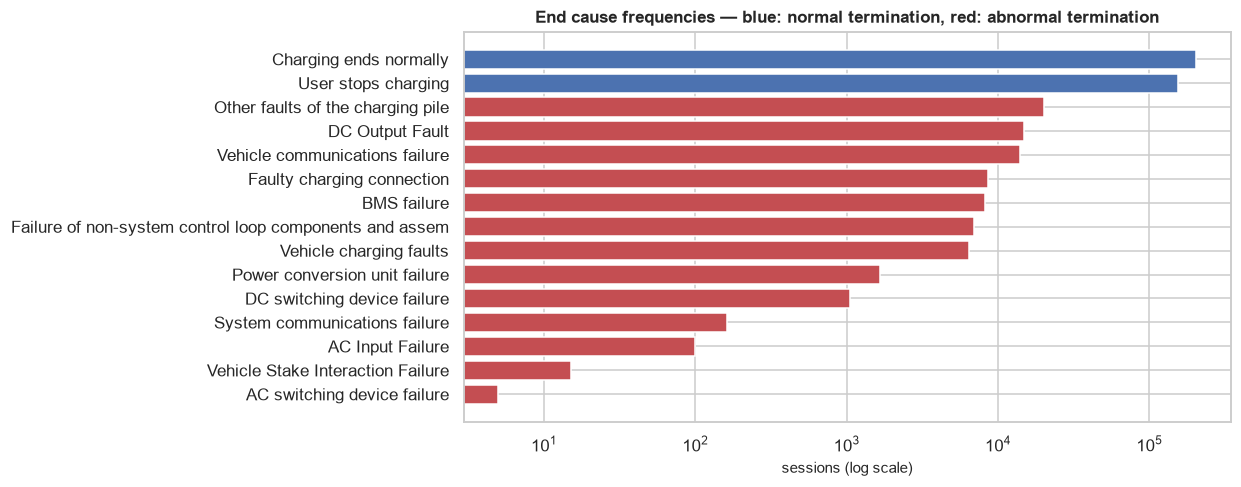


Overall prevalence of abnormal sessions: 0.1858 (81,934 abnormal vs 359,143 normal) -> imbalance ratio ≈ 1:4.4


In [10]:
NORMAL_CAUSES = {"Charging ends normally", "User stops charging"}
df[TARGET] = (~df["end_cause"].isin(NORMAL_CAUSES)).astype(np.int8)

cause = df.groupby("end_cause").agg(sessions=("row_id", "size"))
cause["share"] = cause["sessions"] / len(df)
cause["median_duration_min"] = (dur_h * 60).groupby(df["end_cause"]).median()
cause["median_energy_kWh"] = df.groupby("end_cause")["energy_kwh"].median()
cause["share_zero_energy"] = df.groupby("end_cause")["energy_kwh"].apply(lambda s: (s == 0).mean())
cause["is_Abnormal"] = [0 if c in NORMAL_CAUSES else 1 for c in cause.index]
display(cause.sort_values("sessions", ascending=False))

fig, ax = plt.subplots(figsize=(9, 4.6))
order_ = cause.sort_values("sessions")
ax.barh(order_.index.str.slice(0, 55), order_["sessions"],
        color=[C_ABN if a else C_NORMAL for a in order_["is_Abnormal"]])
ax.set_xscale("log"); ax.set_xlabel("sessions (log scale)")
ax.set_title("End cause frequencies — blue: normal termination, red: abnormal termination")
savefig(fig, "04_end_cause_frequencies")

print(f"\nOverall prevalence of abnormal sessions: {df[TARGET].mean():.4f} "
      f"({df[TARGET].sum():,} abnormal vs {(1 - df[TARGET]).sum():,.0f} normal) -> imbalance ratio ≈ 1:{(1 - df[TARGET].mean()) / df[TARGET].mean():.1f}")

**Interpretation.**
* The 13 fault causes are extremely unbalanced (from 20,114 down to 5 sessions). Because the project target is *binary*, these rare categories are **not** a modelling problem, but they matter for interpretation (§5: the *fault mix* changes over time).
* Faults are physically consistent with an abrupt end: most fault causes end after **≈1–2 minutes with no energy delivered** (`share_zero_energy` between 60% and 100%); only `DC Output Fault`, `Faulty charging connection` and `BMS failure` last 12–26 minutes and still deliver energy. This is a first hint that `energy_kwh` and `duration` are *consequences* of the outcome.
* `User stops charging` is the second most frequent cause. It is **assumed normal**: the user, not the equipment, ended the session. This assumption is tested next.

### 4.2 Validating the definition of "abnormal" with an independent oracle

The dataset ships with counts of *previous completed abnormal sessions* per post and per user, computed by the authors with their own definition of "abnormal". If our derived label is right, **re-computing those counts from our label and from the timestamps must reproduce the supplied columns**. We test three competing definitions:

* **A** — normal = {`Charging ends normally`, `User stops charging`} (our choice);
* **B** — stricter: only `Charging ends normally` is normal (a user stop would be abnormal);
* **C** — permissive: vehicle-side causes (`BMS failure`, `Vehicle charging faults`, `Vehicle communications failure`) are also considered normal (only charger-side faults are abnormal).

A session *j* is a "previous completed session" of session *i* when `end_j ≤ start_i`; a window of *W* days keeps those with `end_j > start_i − W`.

In [11]:
def history_counts(frame: pd.DataFrame, key: str, window_days: float, label: np.ndarray):
    """Recompute, from raw timestamps, the number of previous *completed* sessions and previous completed
    abnormal sessions for the same `key` (post_id or user_id) inside a trailing window."""
    start = frame["start_time"].to_numpy("datetime64[ns]").astype(np.int64)
    end = frame["end_time"].to_numpy("datetime64[ns]").astype(np.int64)
    win = int(window_days * 86_400 * 1e9)
    n_sess = np.zeros(len(frame), dtype=np.int64)
    n_abn = np.zeros(len(frame), dtype=np.int64)
    for _, idx in frame.groupby(key).indices.items():
        order = np.argsort(end[idx], kind="stable")
        e_sorted = end[idx][order]
        cum = np.concatenate([[0], np.cumsum(label[idx][order])])
        hi = np.searchsorted(e_sorted, start[idx], side="right")            # completed: end <= start
        lo = np.searchsorted(e_sorted, start[idx] - win, side="right")      # inside window: end > start - W
        n_sess[idx], n_abn[idx] = hi - lo, cum[hi] - cum[lo]
    return n_sess, n_abn


WINDOWS = [("post_id", 1, "post_previous_{}_1D"), ("post_id", 7, "post_previous_{}_7D"), ("post_id", 30, "post_previous_{}_30D"),
           ("user_id", 30, "user_previous_{}_30D"), ("user_id", 180, "user_previous_{}_180D"), ("user_id", 730, "user_previous_{}_730D")]
DEFINITIONS = {
    "A: normal = ends normally + user stops": NORMAL_CAUSES,
    "B: normal = ends normally only": {"Charging ends normally"},
    "C: vehicle-side faults also normal": NORMAL_CAUSES | {"BMS failure", "Vehicle charging faults", "Vehicle communications failure"},
}

t0 = time.time()
rows = []
sess_match = {}
for name, normal_set in DEFINITIONS.items():
    lab = (~df["end_cause"].isin(normal_set)).astype(np.int8).to_numpy()
    rec = {"definition": name}
    for key, w, pattern in WINDOWS:
        n_sess, n_abn = history_counts(df, key, w, lab)
        rec[pattern.format("abnormal").replace("_previous_abnormal", " abn")] = (n_abn == df[pattern.format("abnormal")].to_numpy()).mean()
        if name.startswith("A"):
            sess_match[pattern.format("sessions")] = (n_sess == df[pattern.format("sessions")].to_numpy()).mean()
    rows.append(rec)
oracle = pd.DataFrame(rows).set_index("definition")
print(f"(recomputation took {time.time() - t0:.0f}s)\nShare of rows where the recomputed ABNORMAL count equals the supplied column:")
display(oracle.style.format("{:.4%}").background_gradient(cmap="RdYlGn", vmin=0.0, vmax=1.0, axis=None))
print("Share of rows where the recomputed SESSION count equals the supplied column (definition-independent):")
display(pd.Series(sess_match).to_frame("match").T.style.format("{:.4%}"))

(recomputation took 4s)
Share of rows where the recomputed ABNORMAL count equals the supplied column:


,post abn_1D,post abn_7D,post abn_30D,user abn_30D,user abn_180D,user abn_730D
definition,,,,,,
A: normal = ends normally + user stops,99.9964%,99.9968%,99.9973%,99.9789%,99.9789%,99.9789%
B: normal = ends normally only,10.3952%,1.0844%,0.2632%,35.8461%,28.1368%,26.9479%
C: vehicle-side faults also normal,68.4958%,19.9623%,2.3214%,69.7298%,56.4405%,53.0941%


Share of rows where the recomputed SESSION count equals the supplied column (definition-independent):


,post_previous_sessions_1D,post_previous_sessions_7D,post_previous_sessions_30D,user_previous_sessions_30D,user_previous_sessions_180D,user_previous_sessions_730D
match,99.9798%,99.9834%,99.9839%,99.9662%,99.9674%,99.9680%


**Interpretation.**
* Definition **A reproduces the supplied abnormal counts in ≈100% of the rows in all six windows**, while B and C fail badly (B is off by far more than a tie-handling effect, C also mismatches heavily). The supplied columns therefore encode *exactly* our definition: **`is_Abnormal = 1` ⇔ `end_cause` ∉ {`Charging ends normally`, `User stops charging`}**.
* The residual mismatch (~0.02–0.04% of rows) is compatible with timestamp ties at the second resolution (an event ending exactly when another starts); it is negligible and is not corrected.
* This validation also proves that the historical windows contain only sessions **completed before the current start** (`end ≤ start`), i.e. *there is no look-ahead in the history attributes* — the property we need to use them as predictors.

**Decision.** The target is fixed as definition A: prevalence **18.6 %** (≈1 abnormal session in 5.4).

In [12]:
log_decision("4", "Target definition", "is_Abnormal = end_cause ∉ {'Charging ends normally','User stops charging'}.",
             "Only this definition reproduces the dataset's own abnormal-count history columns (≈100% of rows, 6 windows); alternatives B and C fail.")

### 4.3 What else can be verified about the pre-computed attributes?

The task statement requires that we *understand the meaning* of the history variables. The following checks re-derive the remaining attributes from raw timestamps and verify the algebraic relation between counts and rates.

In [13]:
start_ns = df["start_time"].to_numpy("datetime64[ns]").astype(np.int64)
end_ns = df["end_time"].to_numpy("datetime64[ns]").astype(np.int64)

# (a) smoothed rate identity: rate = (abnormal + 1) / (sessions + 5)  -> Laplace-type smoothing with prior 0.2 and weight 5
rate_err = {}
for key, w, pattern in WINDOWS:
    a, s, r = pattern.format("abnormal"), pattern.format("sessions"), pattern.format("abnormal_rate")
    rate_err[r] = float(np.abs((df[a] + 1) / (df[s] + 5) - df[r]).max())
print("Max |rate - (abnormal + 1)/(sessions + 5)| per window:")
display(pd.Series(rate_err).to_frame("max_abs_error").T.style.format("{:.2e}"))

# (b) time since previous completed session (post, hours; user, days) and is_new_user
def time_since_previous_completed(frame_key: pd.Series, unit_ns: float):
    out = np.full(len(df), np.nan)
    for _, idx in df.groupby(frame_key).indices.items():
        e_sorted = np.sort(end_ns[idx])
        hi = np.searchsorted(e_sorted, start_ns[idx], side="right")
        has = hi > 0
        out[idx[has]] = (start_ns[idx][has] - e_sorted[hi[has] - 1]) / unit_ns
    return out

post_h = time_since_previous_completed(df["post_id"], 3.6e12)
user_d = time_since_previous_completed(df["user_id"], 8.64e13)
ok_post = np.isclose(post_h, df["post_hours_since_previous_completed_session"], equal_nan=True, atol=1e-3)
ok_user = np.isclose(user_d, df["user_days_since_previous_completed_session"], equal_nan=True, atol=1e-4)
first_session = df.groupby("user_id")["start_time"].transform("min") == df["start_time"]
print(f"post_hours_since_previous_completed_session reproduced in {ok_post.mean():.4%} of rows")
print(f"user_days_since_previous_completed_session reproduced in {ok_user.mean():.4%} of rows")
print(f"is_new_user == 'first session of the account in the file' in {(first_session.astype(int) == df['is_new_user']).mean():.4%} of rows")

# (c) concurrency: other sessions of the same account already active when this one starts (start_j < start_i < ... end_j > start_i)
calc_active = np.zeros(len(df), dtype=np.int64)
for _, idx in df.groupby("user_id").indices.items():
    if len(idx) > 1:
        s_sorted, e_sorted = np.sort(start_ns[idx]), np.sort(end_ns[idx])
        calc_active[idx] = np.maximum(np.searchsorted(s_sorted, start_ns[idx], side="left") - np.searchsorted(e_sorted, start_ns[idx], side="right"), 0)
print(f"user_active_sessions_at_start reproduced in {(calc_active == df['user_active_sessions_at_start']).mean():.4%} of rows")

# (d) users with history flag but not new: all their previous sessions are still active (not completed) -> consistent
n_odd = int(((df["is_new_user"] == 0) & (df["user_no_previous_completed_session"] == 1)).sum())
print(f"Rows with is_new_user=0 but no *completed* previous session: {n_odd} (previous sessions still active at start)")

Max |rate - (abnormal + 1)/(sessions + 5)| per window:


,post_previous_abnormal_rate_1D,post_previous_abnormal_rate_7D,post_previous_abnormal_rate_30D,user_previous_abnormal_rate_30D,user_previous_abnormal_rate_180D,user_previous_abnormal_rate_730D
max_abs_error,1.11e-16,1.11e-16,1.11e-16,1.11e-16,1.11e-16,1.11e-16


post_hours_since_previous_completed_session reproduced in 99.9989% of rows
user_days_since_previous_completed_session reproduced in 99.9680% of rows
is_new_user == 'first session of the account in the file' in 100.0000% of rows
user_active_sessions_at_start reproduced in 99.9692% of rows
Rows with is_new_user=0 but no *completed* previous session: 531 (previous sessions still active at start)


**Interpretation.**
* **Smoothed rates are an exact algebraic function of the counts**: `rate = (abnormal + 1) / (sessions + 5)` (error ≈ 1e-16). Consequently the *abnormal count* in each window is redundant given the *session count* and the *rate* — formal evidence used for feature reduction in §11. The smoothing also means that **cold-start entities receive the prior 0.2** (`1/5`), a value that is *not* the observed prevalence (0.186) and is shared by every entity with no history.
* `post_hours_since_previous_completed_session`, `user_days_since_previous_completed_session`, `is_new_user` and `user_active_sessions_at_start` are all reproduced (≈100%) from timestamps. Their meaning is now *verified*, not just read from the documentation.
* `is_new_user` means **"first session of this account in the file"** — a definition that depends on the **observation window** (this has consequences for the start of the file, §5.3).
* The 531 rows with `is_new_user = 0` and no completed history correspond to accounts whose earlier sessions were *still active* at the start — semantics consistent with the statement that active sessions were excluded from outcome-derived history.

### 4.4 Label quality: sessions labelled *normal* that look like failures

Because the target is *derived*, label noise deserves a look. Roughly 12% of sessions deliver 0 kWh; most of them are abnormal — but some are labelled normal.

In [14]:
zero = df["energy_kwh"] == 0
noise = df.assign(zero_energy=zero, short_lt_2min=(dur_h < 2 / 60))
tab = (noise.groupby([TARGET, "zero_energy"]).size().unstack(fill_value=0)
       .rename(index={0: "normal", 1: "abnormal"}, columns={False: "energy > 0", True: "energy = 0"}))
tab["share of zero-energy"] = tab["energy = 0"] / tab.sum(axis=1)
display(tab)
zn = df[zero & (df[TARGET] == 0)]
print(f"Normal sessions with zero energy: {len(zn):,} ({len(zn) / (df[TARGET] == 0).sum():.1%} of all normal sessions); "
      f"causes: {zn['end_cause'].value_counts().to_dict()}")
print("Median duration of those sessions (min):", round(float((dur_h[zn.index] * 60).median()), 2))

zero_energy,energy > 0,energy = 0,share of zero-energy
is_Abnormal,,,
normal,350085,9058,0.0252
abnormal,36371,45563,0.5561


Normal sessions with zero energy: 9,058 (2.5% of all normal sessions); causes: {'User stops charging': 7730, 'Charging ends normally': 1328}
Median duration of those sessions (min): 0.95


**Interpretation.** About 9,000 sessions (2.5% of the normal class) are labelled normal although they delivered no energy — mostly `User stops charging` after a very short time. They are plausible *user cancellations* (the user plugged in and changed their mind) and, by the dataset's own definition (§4.2), they are normal. They represent an **irreducible label ambiguity** (part of the "noise ceiling" of any start-time model) and are **not removed**: removing them would use post-hoc information (energy) to *clean the training labels* in a way that cannot be reproduced at prediction time.

In [15]:
log_decision("4", "Label noise", "Keep normal sessions with zero energy (≈9k rows).",
             "Plausible user cancellations; defined normal by the dataset's own oracle; filtering on post-hoc energy is not reproducible at start time.")

---
## 5. Temporal coverage and stability

**Why this comes before any modelling.** The project asks whether *session volume, class prevalence, predictor distributions, user/post activity and other patterns remain stable*. If they do not, (i) a random split would be optimistic, (ii) the first weeks of the file may contain *artefacts of the observation window* rather than real behaviour, and (iii) the evaluation must be chronological.

> **Methodological note.** This section inspects the *whole* period because describing temporal change is its purpose. All *relationship* analyses that inform modelling decisions (§6–§9, §12) use **only the development window** (`2020-04-01 ≤ start < 2021-07-01`, defined in §10) so that validation and test periods do not influence feature decisions.

In [16]:
# helper columns used throughout the analysis (all derivable at, or after, the session end — used for diagnostics only)
df["duration_h"] = (df["end_time"] - df["start_time"]).dt.total_seconds() / 3600
df["order_lag_min"] = (df["order_time"] - df["start_time"]).dt.total_seconds() / 60
df["payment_lag_h"] = (df["payment_time"] - df["end_time"]).dt.total_seconds() / 3600

in_burn = df["start_time"] < BURN_IN_END
in_train_window = (df["start_time"] >= BURN_IN_END) & (df["start_time"] < TRAIN_END)
in_val = (df["start_time"] >= TRAIN_END) & (df["start_time"] < VAL_END)
in_test = df["start_time"] >= VAL_END
EDA = df[in_train_window].copy()      # development window: used for all relationship analyses
print(f"burn-in: {in_burn.sum():,} | development window: {in_train_window.sum():,} | validation: {in_val.sum():,} | test: {in_test.sum():,}")


def shade_periods(axes) -> None:
    """Shade burn-in / validation / test periods on time-axis plots."""
    spans = [(pd.Timestamp("2019-12-15"), BURN_IN_END, "#9e9e9e", "burn-in (excluded)"),
             (TRAIN_END, VAL_END, "#f4a261", "validation"), (VAL_END, pd.Timestamp("2022-01-05"), "#2a9d8f", "test")]
    for ax in np.atleast_1d(axes):
        for a, b, col, _ in spans:
            ax.axvspan(a, b, color=col, alpha=0.12, lw=0)
    ax0 = np.atleast_1d(axes)[0]
    for a, b, col, lab in spans:
        ax0.text(a + (b - a) / 2, 1.02, lab, transform=ax0.get_xaxis_transform(), ha="center", fontsize=8, color=col)

burn-in: 14,017 | development window: 271,210 | validation: 75,769 | test: 80,081


### 5.1 Coverage, volume, prevalence and activity over time

The first fifteen or so sessions belong to 31 Dec 2019 (the file starts on that evening); the series is analysed from January 2020.

,sessions,active_posts,active_users,new_user_share,mean_post_sessions_30D,median_user_sessions_180D,prevalence
month,,,,,,,
2020-01,6217,92,1963,31.4000,53.0000,2.0000,25.0000
2020-02,1391,83,516,23.7000,45.0000,4.0000,26.3000
2020-03,6392,92,1797,20.9000,67.0000,5.0000,24.8000
2020-04,11136,92,2622,15.5000,161.0000,9.0000,22.1000
2020-05,15033,92,3153,12.4000,222.0000,16.0000,19.2000
2020-06,17513,91,3185,9.7000,237.0000,23.0000,16.0000
2020-07,22032,92,3704,8.8000,272.0000,30.0000,18.2000
2020-08,25562,92,4733,10.4000,334.0000,32.0000,20.1000
2020-09,20231,92,4642,12.7000,316.0000,20.0000,18.6000


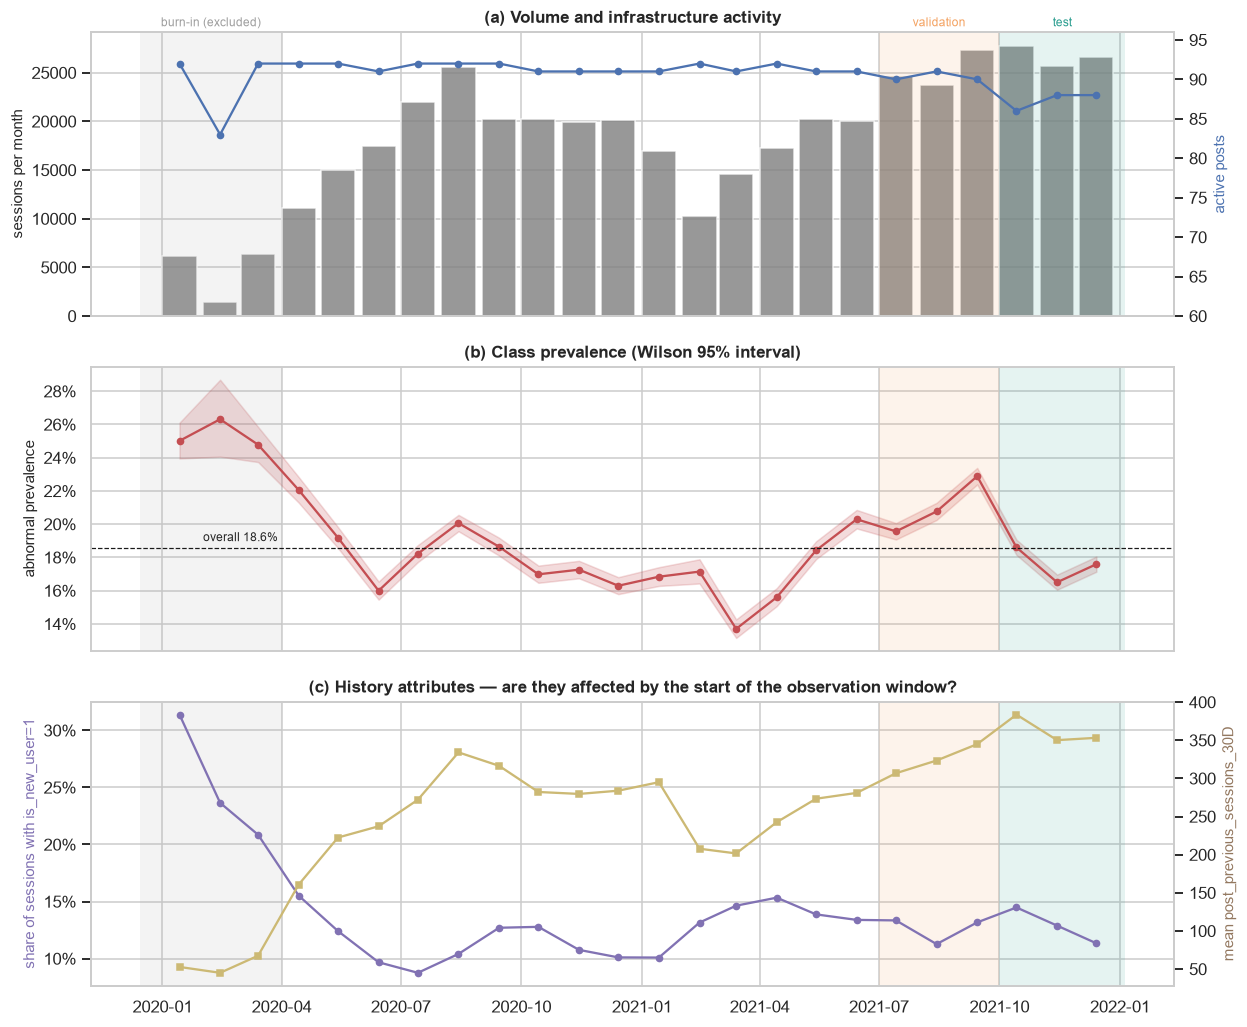

In [17]:
d = df[df["start_time"] >= "2020-01-01"].copy()
d["month"] = d["start_time"].dt.to_period("M")
monthly = d.groupby("month").agg(sessions=("row_id", "size"), abnormal=(TARGET, "sum"),
                                 active_posts=("post_id", "nunique"), active_users=("user_id", "nunique"),
                                 new_user_share=("is_new_user", "mean"),
                                 mean_post_sessions_30D=("post_previous_sessions_30D", "mean"),
                                 median_user_sessions_180D=("user_previous_sessions_180D", "median"))
monthly["prevalence"] = monthly["abnormal"] / monthly["sessions"]
monthly["ci_low"], monthly["ci_high"] = wilson_interval(monthly["abnormal"], monthly["sessions"])
display(monthly.assign(prevalence=lambda t: (t.prevalence * 100).round(1), new_user_share=lambda t: (t.new_user_share * 100).round(1),
                       mean_post_sessions_30D=lambda t: t.mean_post_sessions_30D.round(0))
        .drop(columns=["ci_low", "ci_high", "abnormal"]))

x = monthly.index.to_timestamp()
overall = df.loc[df["start_time"] >= "2020-01-01", TARGET].mean()
fig, axes = plt.subplots(3, 1, figsize=(11.5, 9.5), sharex=True)
ax = axes[0]
ax.bar(x, monthly["sessions"], width=26, align="edge", color=C_NEUTRAL, alpha=.8)
ax.set_ylabel("sessions per month"); ax.set_title("(a) Volume and infrastructure activity")
ax2 = ax.twinx(); ax2.plot(x + pd.Timedelta(days=13), monthly["active_posts"], color=C_NORMAL, marker="o", ms=4)
ax2.set_ylabel("active posts", color=C_NORMAL); ax2.set_ylim(60, 96); ax2.grid(False)
ax = axes[1]
ax.plot(x + pd.Timedelta(days=13), monthly["prevalence"], color=C_ABN, marker="o", ms=4)
ax.fill_between(x + pd.Timedelta(days=13), monthly["ci_low"], monthly["ci_high"], color=C_ABN, alpha=.2)
ax.axhline(overall, color="k", ls="--", lw=.8); ax.text(x[1], overall + .004, f"overall {overall:.1%}", fontsize=8)
ax.yaxis.set_major_locator(mtick.MultipleLocator(0.02)); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0)); ax.set_ylabel("abnormal prevalence")
ax.set_title("(b) Class prevalence (Wilson 95% interval)")
ax = axes[2]
ax.plot(x + pd.Timedelta(days=13), monthly["new_user_share"], color="#8172B3", marker="o", ms=4)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0)); ax.set_ylabel("share of sessions with is_new_user=1", color="#8172B3")
ax3 = ax.twinx(); ax3.plot(x + pd.Timedelta(days=13), monthly["mean_post_sessions_30D"], color="#CCB974", marker="s", ms=4)
ax3.set_ylabel("mean post_previous_sessions_30D", color="#937860"); ax3.grid(False)
ax.set_title("(c) History attributes — are they affected by the start of the observation window?")
shade_periods(axes)
fig.tight_layout(); savefig(fig, "05_1_monthly_volume_prevalence_history")

**Interpretation.**
* **Volume is not stationary.** Monthly sessions grow from ≈6,000 (Jan-2020) to more than 25,000 (Aug-2020), collapse in Feb-2020 (1,391 sessions) and dip again in Feb–Mar 2021 (10,283 and 14,599), and reach 25–28k per month in autumn 2021. The Feb-2020 collapse coincides with the COVID-19 restrictions and the Feb-2021 dip with the Spring Festival (external context, not contained in the data). The number of active posts is stable (90–92) until Sep-2021 and drops to 86–88 in Q4-2021 because four posts stop on 28 Sep 2021 (§5.5).
* **Prevalence is not stationary either.** It is 25–27% in Q1-2020, falls to 16% in Jun-2020, stays at 17–18% in late 2020, reaches a minimum of 13.7% in Mar-2021, climbs to 22.9% in Sep-2021 and returns to 17–19% in Q4-2021. The Wilson intervals are narrow (about ±0.5 percentage points), so these movements are **real changes, not sampling noise**. Consequences: (i) the *base rate* differs between training, validation and test; (ii) probability calibration and any decision threshold are period-dependent; (iii) threshold-independent metrics such as PR-AUC depend on prevalence, so results must always be read **relative to the base rate of the period**.
* **History attributes are censored by the start of the file.** In Jan-2020, 31% of the sessions are flagged `is_new_user` (still 24% and 21% in Feb/Mar) against 9–15% from Apr-2020 onwards, and the mean 30-day post session count is 53 against 200+ from May-2020 onwards. Part of the rise in Apr–May 2020 is genuine growth in volume, but the first months are dominated by an **observation-window artefact**: nothing before 31-Dec-2019 is visible, so "new user" means *first session in the file*, not first session ever, and rolling windows are still filling up. The 180-day and 730-day user windows never become fully populated inside the file (the 730-day window covers at most ≈24 months of data).

### 5.2 Is the *type* of failure stable? (regime changes)

A constant prevalence could hide a change in *what* is failing. The stacked bars decompose the quarterly prevalence into four failure families (contribution of each family to the abnormal-session rate).

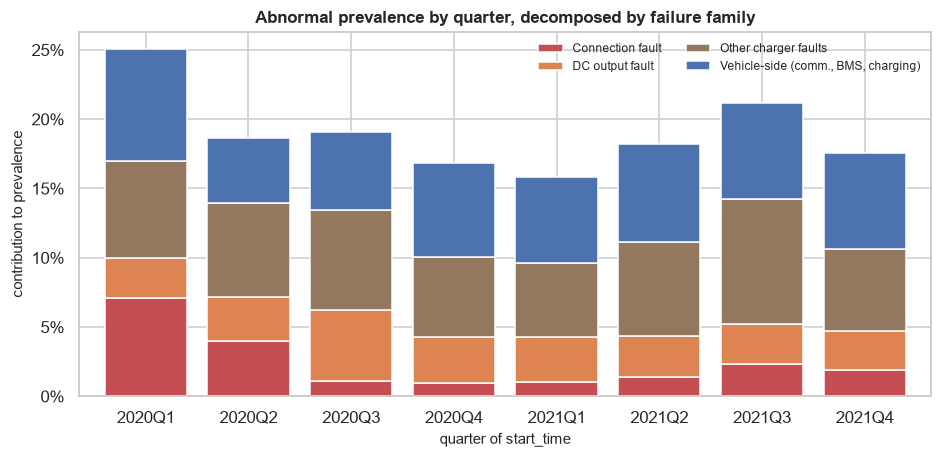

fault_family,Connection fault,DC output fault,Other charger faults,"Vehicle-side (comm., BMS, charging)"
quarter,,,,
2020Q1,7.1000,2.9000,7.0000,8.0000
2020Q2,4.0000,3.2000,6.7000,4.7000
2020Q3,1.1000,5.2000,7.2000,5.6000
2020Q4,1.0000,3.3000,5.8000,6.8000
2021Q1,1.1000,3.2000,5.4000,6.2000
2021Q2,1.4000,3.0000,6.8000,7.1000
2021Q3,2.3000,2.9000,9.0000,6.9000
2021Q4,1.9000,2.8000,6.0000,7.0000


In [18]:
FAMILY = {
    "Faulty charging connection": "Connection fault",
    "DC Output Fault": "DC output fault",
    "Vehicle communications failure": "Vehicle-side (comm., BMS, charging)",
    "BMS failure": "Vehicle-side (comm., BMS, charging)",
    "Vehicle charging faults": "Vehicle-side (comm., BMS, charging)",
    "Vehicle Stake Interaction Failure": "Vehicle-side (comm., BMS, charging)",
}
df["fault_family"] = np.where(df[TARGET] == 1, df["end_cause"].map(FAMILY).fillna("Other charger faults"), "normal")
q = df[df["start_time"] >= "2020-01-01"].copy()
q["quarter"] = q["start_time"].dt.to_period("Q").astype(str)
comp = (q.groupby(["quarter", "fault_family"]).size().unstack(fill_value=0)
        .drop(columns="normal").div(q.groupby("quarter").size(), axis=0))
fam_order = ["Connection fault", "DC output fault", "Other charger faults", "Vehicle-side (comm., BMS, charging)"]
fig, ax = plt.subplots(figsize=(10, 4.3))
comp[fam_order].plot(kind="bar", stacked=True, ax=ax, color=["#C44E52", "#DD8452", "#937860", "#4C72B0"], width=.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0)); ax.set_xlabel("quarter of start_time"); ax.set_ylabel("contribution to prevalence")
ax.set_title("Abnormal prevalence by quarter, decomposed by failure family"); ax.legend(title="", fontsize=8, ncol=2, loc="upper right")
plt.xticks(rotation=0); savefig(fig, "05_2_fault_family_by_quarter")
display((comp[fam_order] * 100).round(1))

**Interpretation.**
* **The type of failure changes, not only its frequency.** *Connection faults* contribute 7.1 percentage points to the prevalence in Q1-2020, 4.0 in Q2-2020 and only ≈1 point from Q3-2020 on. Since total prevalence falls from ≈25% to ≈17% over the same period, **this single failure family explains most of the decline** — consistent with an early-deployment problem that was later fixed (an interpretation; the data cannot confirm the cause).
* The other families are steadier: vehicle-side failures contribute 4.7–8.0 points, DC-output faults 2.9–5.2 and the remaining charger faults 5.4–9.0. The autumn-2021 bump in prevalence comes from the "other charger faults" family (9.0 points in Q3-2021).
* **Implication.** Pooling Q1-2020 with later periods would teach a model a failure regime that no longer exists, which supports excluding a burn-in period (§5.6). It also warns that the fault mix can change again after deployment: the model must be *monitored and periodically refitted*, and the history features are precisely the mechanism that lets a model react to the *current* state of each post.

### 5.3 Is prevalence stable *within* stations and posts?

Prevalence is decomposed by station over time (heat-map, cells with fewer than 200 sessions hidden), and the persistence of *post-level* prevalence between the first period and the last full year is measured. Persistence is what makes post identity and post history useful predictors.

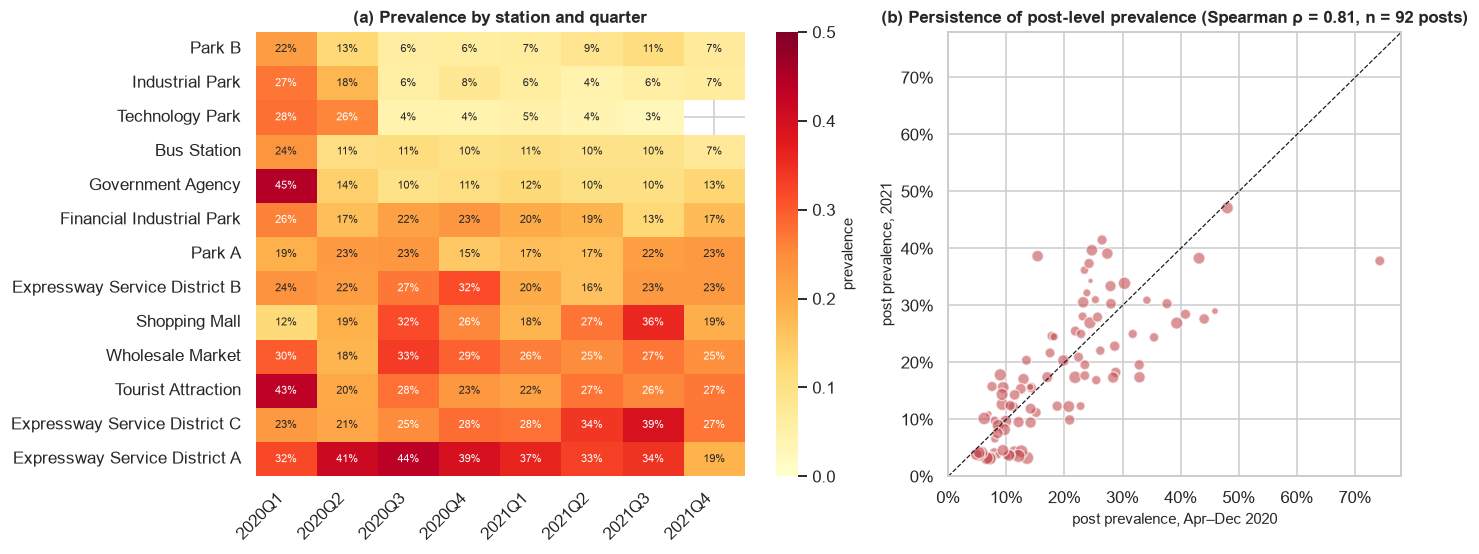

Top-10 posts (11% of posts) account for 30.5% of abnormal sessions but only 15.3% of all sessions (development window).
Post-level prevalence quantiles (development window):


,count,mean,std,min,5%,25%,50%,75%,95%,max
post prevalence,92.0000,0.1920,0.1160,0.0410,0.0530,0.0920,0.1750,0.2670,0.4050,0.6090


In [19]:
q["quarter_p"] = q["start_time"].dt.to_period("Q")
loc_q = q.groupby(["location", "quarter_p"]).agg(n=("row_id", "size"), k=(TARGET, "sum"))
loc_q["p"] = np.where(loc_q["n"] >= 200, loc_q["k"] / loc_q["n"], np.nan)
heat = loc_q["p"].unstack("quarter_p")
heat = heat.loc[heat.mean(axis=1).sort_values().index]

per_a = df[(df["start_time"] >= BURN_IN_END) & (df["start_time"] < "2021-01-01")].groupby("post_id")[TARGET].agg(["mean", "size"])
per_b = df[df["start_time"] >= "2021-01-01"].groupby("post_id")[TARGET].agg(["mean", "size"])
pp = per_a.join(per_b, lsuffix="_A", rsuffix="_B", how="inner")
rho = stats.spearmanr(pp["mean_A"], pp["mean_B"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={"width_ratios": [1.35, 1]})
sns.heatmap(heat, annot=True, fmt=".0%", cmap="YlOrRd", vmin=0, vmax=0.5, cbar_kws={"label": "prevalence"}, ax=axes[0], annot_kws={"fontsize": 7})
axes[0].set_xlabel(""); axes[0].set_ylabel(""); axes[0].set_title("(a) Prevalence by station and quarter")
axes[0].set_xticklabels([str(t.get_text()) for t in axes[0].get_xticklabels()], rotation=45, ha="right")
axes[1].scatter(pp["mean_A"], pp["mean_B"], s=np.sqrt(pp["size_A"]) * 1.2, alpha=.6, color=C_ABN, edgecolor="white")
lim = [0, max(pp[["mean_A", "mean_B"]].max()) * 1.05]
axes[1].plot(lim, lim, "k--", lw=.8); axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0)); axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
axes[1].set_xlabel("post prevalence, Apr–Dec 2020"); axes[1].set_ylabel("post prevalence, 2021")
axes[1].set_title(f"(b) Persistence of post-level prevalence (Spearman ρ = {rho.statistic:.2f}, n = {len(pp)} posts)")
fig.tight_layout(); savefig(fig, "05_3_station_heatmap_and_post_persistence")

# concentration of abnormal sessions in few posts (development window)
pc = EDA.groupby("post_id")[TARGET].agg(k="sum", n="size").sort_values("k", ascending=False)
top10 = pc["k"].head(10).sum() / pc["k"].sum()
print(f"Top-10 posts ({10 / len(pc):.0%} of posts) account for {top10:.1%} of abnormal sessions "
      f"but only {pc['n'].head(10).sum() / pc['n'].sum():.1%} of all sessions (development window).")
print("Post-level prevalence quantiles (development window):")
display((pc["k"] / pc["n"]).describe(percentiles=[.05, .25, .5, .75, .95]).round(3).to_frame("post prevalence").T)

**Interpretation.**
* **Stations differ by a factor of 3–5 and the ranking is persistent.** Park B, Industrial Park, Technology Park and Bus Station stay at roughly 3–11% from 2020-Q3 onwards, whereas Expressway Service Districts A/C, Wholesale Market, Shopping Mall and Tourist Attraction stay between roughly 17% and 44%.
* **But the levels themselves move a lot.** Government Agency goes from 45% (Q1-2020) to 10–14%; Technology Park from 28% to 3–4%; Shopping Mall from 12% to 36% (Q3-2021) and back to 19%; Expressway A from 44% (Q3-2020) to 19% (Q4-2021). A *static* post/station effect therefore captures only part of the signal; **recent history is needed to track the drift**.
* **Post-level prevalence is persistent**: Spearman ρ = 0.81 between Apr–Dec 2020 and 2021 across 92 posts (points hug the diagonal; the few exceptions are posts that improved, e.g. one at ≈74% in 2020 and ≈38% in 2021).
* **Failures are concentrated**: the ten worst posts (11% of the posts) account for 30.5% of all abnormal sessions but only 15.3% of the sessions, and post-level prevalence ranges from 4% to 61% (5th–95th percentile: 5%–41%).
* **Implication.** Post identity is a strong, mostly persistent predictor, and preventive maintenance can target a small number of posts. The risk is that a model *memorises post identity* and generalises poorly to new posts or to posts whose condition changes — station/district (coarser) and history features act as fall-backs and are examined in §7 and §15.

### 5.4 Predictor drift: Population Stability Index by quarter

The reference distribution is the development window (learned once). PSI < 0.10 is *stable*, 0.10–0.25 *moderate*, > 0.25 *major*. Weather is expected to drift for seasonal reasons (the reference window has a different mix of seasons than a single quarter).

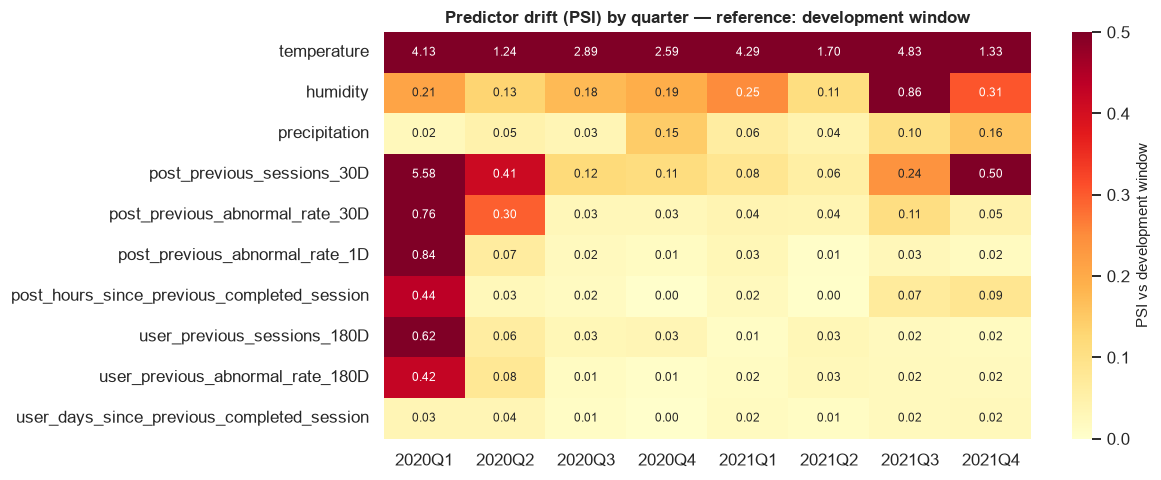

,2020Q1,2020Q2,2020Q3,2020Q4,2021Q1,2021Q2,2021Q3,2021Q4
temperature,4.1300,1.2400,2.8900,2.5900,4.2900,1.7000,4.8300,1.3300
humidity,0.2100,0.1300,0.1800,0.1900,0.2500,0.1100,0.8600,0.3100
precipitation,0.0200,0.0500,0.0300,0.1500,0.0600,0.0400,0.1000,0.1600
post_previous_sessions_30D,5.5800,0.4100,0.1200,0.1100,0.0800,0.0600,0.2400,0.5000
post_previous_abnormal_rate_30D,0.7600,0.3000,0.0300,0.0300,0.0400,0.0400,0.1100,0.0500
post_previous_abnormal_rate_1D,0.8400,0.0700,0.0200,0.0100,0.0300,0.0100,0.0300,0.0200
post_hours_since_previous_completed_session,0.4400,0.0300,0.0200,0.0000,0.0200,0.0000,0.0700,0.0900
user_previous_sessions_180D,0.6200,0.0600,0.0300,0.0300,0.0100,0.0300,0.0200,0.0200
user_previous_abnormal_rate_180D,0.4200,0.0800,0.0100,0.0100,0.0200,0.0300,0.0200,0.0200
user_days_since_previous_completed_session,0.0300,0.0400,0.0100,0.0000,0.0200,0.0100,0.0200,0.0200


In [20]:
ref = EDA
psi_feats = ["temperature", "humidity", "precipitation",
             "post_previous_sessions_30D", "post_previous_abnormal_rate_30D", "post_previous_abnormal_rate_1D",
             "post_hours_since_previous_completed_session",
             "user_previous_sessions_180D", "user_previous_abnormal_rate_180D", "user_days_since_previous_completed_session"]
d = df[df["start_time"] >= "2020-01-01"].copy()
d["quarter"] = d["start_time"].dt.to_period("Q").astype(str)
psi_tab = pd.DataFrame({qq: {f: psi(ref[f], g[f]) for f in psi_feats} for qq, g in d.groupby("quarter")})
fig, ax = plt.subplots(figsize=(9.5, 4.8))
sns.heatmap(psi_tab, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=0.5, ax=ax, cbar_kws={"label": "PSI vs development window"}, annot_kws={"fontsize": 8})
ax.set_title("Predictor drift (PSI) by quarter — reference: development window"); ax.set_xlabel("")
savefig(fig, "05_4_psi_by_quarter")
display(psi_tab.round(2))

**Interpretation.**
* **Q1-2020 is an outlier for every history feature** (PSI: post 30-day sessions 5.6, post 1-day rate 0.84, post 30-day rate 0.76, user 180-day rate 0.42, all ≫ 0.25). This quantifies the censoring at the start of the file (§5.1). From Q3-2020 onwards almost all history features have PSI ≤ 0.10: **after the burn-in, their distributions are reasonably stationary**.
* **Weather drifts for seasonal reasons** (temperature PSI 1.2–4.8; humidity 0.86 in the very wet Q3-2021). This is expected — a single quarter covers a narrower range than the 15-month reference — and is not a data-quality problem. It does mean that weather effects are estimated from a little more than one annual cycle.
* **The test quarter (2021-Q4)** shows moderate-to-high drift only for the 30-day post session count (PSI 0.50, traffic growth) and for temperature; the post and user *rates* and the time-since variables are stable (PSI ≤ 0.09). Raw **counts scale with traffic** and will extrapolate worse than bounded **rates**; this is a reason to monitor them and to prefer rate-type features when a choice exists.

### 5.5 Post life-cycle

Posts that start late or stop early matter for both cold-start and for the assumption that the same posts appear in training and test.

In [21]:
life = df.groupby("post_id").agg(first_session=("start_time", "min"), last_session=("start_time", "max"), sessions=("row_id", "size"),
                                 location=("location", "first")).sort_values("first_session")
print("Posts whose first session is after 2020-01-15:")
display(life[life["first_session"] > "2020-01-15"])
print("Posts with no session after the validation period started (2021-10-01 = test start):")
display(life[life["last_session"] < VAL_END])

Posts whose first session is after 2020-01-15:


,first_session,last_session,sessions,location
post_id,,,,
85,2020-01-25 16:32:30,2021-12-31 22:23:49,4661,Wholesale Market


Posts with no session after the validation period started (2021-10-01 = test start):


,first_session,last_session,sessions,location
post_id,,,,
20,2020-01-01 11:59:54,2021-09-28 20:51:02,7178,Technology Park
18,2020-01-01 12:14:43,2021-09-28 20:30:53,7426,Technology Park
19,2020-01-01 12:52:10,2021-09-28 19:16:27,6935,Technology Park
17,2020-01-01 15:27:51,2021-09-28 20:08:03,7328,Technology Park


**Interpretation.**
* Only **post 85** starts late (25-Jan-2020): a genuine post cold-start, inside the burn-in.
* **Posts 17–20 (all in Technology Park) stop on 28-Sep-2021**, so they and Technology Park itself are absent from the test period (the gap in the heat-map). The synchronous stop points to a decommissioning or to an interruption of data collection, not to a data error.
* **No post of the validation/test periods is unseen in training**, therefore this split does **not** test post cold-start. In production new posts will appear; station and district (and history features) are the only available fall-backs, and this limitation is stated in the synthesis (§17). Cold-start is evaluated for *users* in §15.

### 5.6 Consequences for development and evaluation (decisions)

| Finding (evidence) | Decision |
|--------------------|----------|
| History attributes are censored and the failure regime differs in Q1-2020 (§5.1, §5.2, §5.4: PSI ≫ 0.25; new-user share 31% vs ≈13%; connection faults 7.1 vs ≈1 points) | **Exclude the burn-in period `start_time < 2020-04-01`** (14,017 sessions, 3.2% of the file) from model development. The cut-off is the first full month after which the PSI of the history features becomes small. Its effect is checked empirically in §15.4. |
| Volume, prevalence and fault mix drift over time (§5.1–5.3) | **Chronological split**: development window Apr-2020 → Jun-2021 (train), **validation = 2021-Q3**, **test = 2021-Q4** (the two last complete quarters). Random K-fold is not used; model selection will use expanding-window cross-validation *inside* the training window (§10). |
| A session's label is only known when it ends (up to 24 h) | **Purge**: training sessions that end after the split boundary are removed, as their label would not be known at fit time (§10). |
| Prevalence differs across periods (13.7%–22.9%) | Report PR-AUC **together with the base rate** and lift; choose thresholds on validation knowing that the prevalence may shift (§14). |
| Raw counts scale with traffic (PSI 0.50 in Q4-2021), rates are stable | Keep rates as the primary history signal; treat raw counts with caution and monitor them. |

In [22]:
log_decision("5/10", "Burn-in period", "Exclude sessions with start_time < 2020-04-01 from model development (kept only for building history in the raw file).",
             "History attributes are censored by the start of the file (new-user share, 30-day counts, PSI), fault mix differs; sensitivity check in §15 shows the exclusion is harmless.")
log_decision("5/10", "Evaluation design", "Chronological split (train ≤ Jun-2021, validation Q3-2021, test Q4-2021) with purge; no random split.",
             "Prevalence, volume and predictor distributions drift over time; post prevalence persists (Spearman ρ = 0.81 across years) but the fault mix and levels change.")

---
## 6. Availability and leakage audit

### 6.1 Empirical evidence: how much do post-hoc variables "know" about the outcome?

For each candidate variable the **direction-agnostic univariate ROC-AUC** is computed on the development window (0.5 = no information, 1.0 = perfect separation). A legitimate start-time predictor rarely exceeds 0.8 on its own; a variable that measures the *result* of the session will separate the classes almost perfectly.

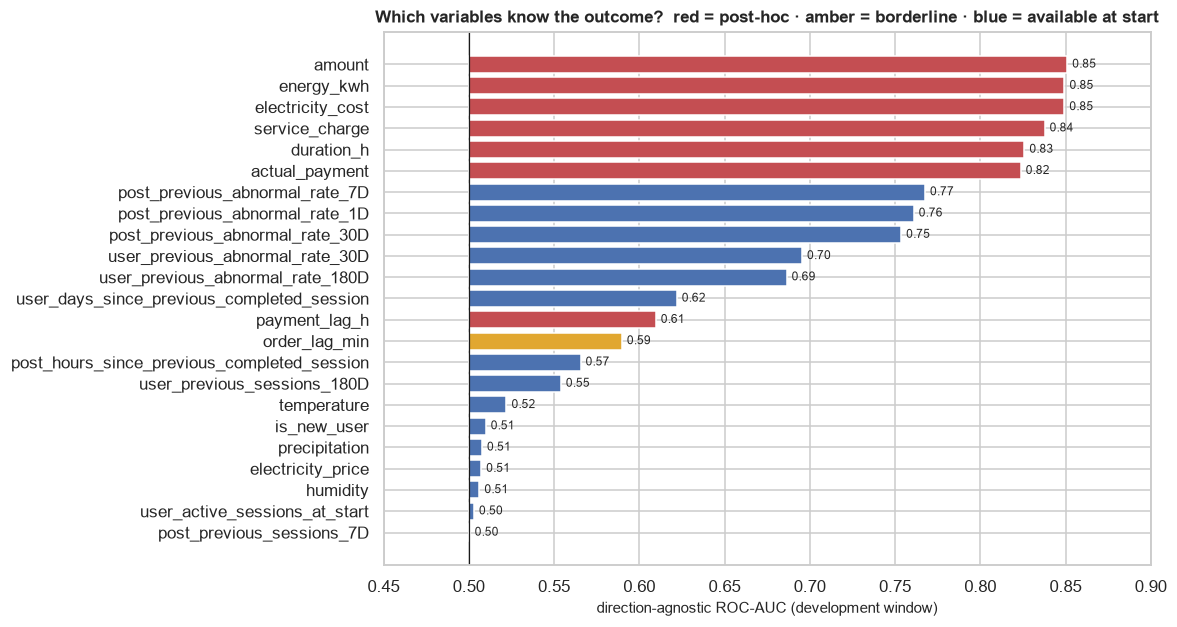

In [23]:
def fill_median(s: pd.Series) -> pd.Series:
    return s.fillna(s.median())

cand = {
    # post-hoc variables (generated during / after the session)
    "energy_kwh": "post-hoc", "electricity_cost": "post-hoc", "service_charge": "post-hoc", "amount": "post-hoc",
    "actual_payment": "post-hoc", "duration_h": "post-hoc", "payment_lag_h": "post-hoc",
    # ambiguous timing
    "order_lag_min": "borderline",
    # legitimate at start
    "post_previous_abnormal_rate_7D": "at start", "post_previous_abnormal_rate_30D": "at start", "post_previous_abnormal_rate_1D": "at start",
    "user_previous_abnormal_rate_180D": "at start", "user_previous_abnormal_rate_30D": "at start",
    "post_hours_since_previous_completed_session": "at start", "post_previous_sessions_7D": "at start",
    "user_previous_sessions_180D": "at start", "user_days_since_previous_completed_session": "at start",
    "is_new_user": "at start", "user_active_sessions_at_start": "at start",
    "temperature": "at start", "humidity": "at start", "precipitation": "at start", "electricity_price": "at start",
}
leak = pd.DataFrame({"availability": pd.Series(cand),
                     "univariate_AUC": {c: auc_symmetric(EDA[TARGET], fill_median(EDA[c])) for c in cand}}).sort_values("univariate_AUC")
fig, ax = plt.subplots(figsize=(9, 6.3))
cols = leak["availability"].map({"post-hoc": C_ABN, "borderline": "#E1A730", "at start": C_NORMAL})
ax.barh(leak.index, leak["univariate_AUC"] - 0.5, left=0.5, color=cols)
ax.axvline(0.5, color="k", lw=.8); ax.set_xlim(0.45, 0.9); ax.set_xlabel("direction-agnostic ROC-AUC (development window)")
ax.set_title("Which variables know the outcome?  red = post-hoc · amber = borderline · blue = available at start")
for i, (name, v) in enumerate(leak["univariate_AUC"].items()):
    ax.text(v + .003, i, f"{v:.2f}", va="center", fontsize=8)
savefig(fig, "06_1_univariate_auc_by_availability")

**Interpretation.**
* The six post-hoc energy/money/duration variables reach an AUC of **0.82–0.85 on their own** — higher than any legitimate single variable (best: 0.77) — and even the *payment lag* (0.61) carries outcome information. This is not accidental: they are consequences of the outcome by construction (abnormal sessions are very short and deliver little energy, §4.1). A model fed with them would learn to *recognise a session that has already failed* rather than to *anticipate* one; their combination is expected to be far stronger than any single one (shown in §15.3).
* Among the legitimate variables the hierarchy is clear: **post history (0.75–0.77) > user history (0.69–0.70) > time-since variables (0.57–0.62) > context** (weather, tariff, `is_new_user`, concurrency ≈ 0.50–0.52). Univariate AUC ignores interactions, so it only sets expectations: a start-time model will be driven mostly by the history of the post and, to a smaller extent, of the user.
* `order_lag_min` (0.59) sits in between and is discussed next.

### 6.2 The ambiguous timestamp: `Order creation time`

The order timestamp is recorded around the start. Whether it is *available at the decision moment* depends on whether the order exists before the start. The table and chart show its position relative to `Start Time` and whether that position is informative.

,n,abnormal,prevalence,share of sessions
lag_bin,,,,
-3 to -1,14095,2490,17.7%,5.2%
-1 to 0,102023,24633,24.1%,37.6%
0 to +1,79921,12019,15.0%,29.5%
+1 to +3,70682,7973,11.3%,26.1%
+3 to +10,3522,1011,28.7%,1.3%
+10 to +60,899,188,20.9%,0.3%
> +60,68,6,8.8%,0.0%


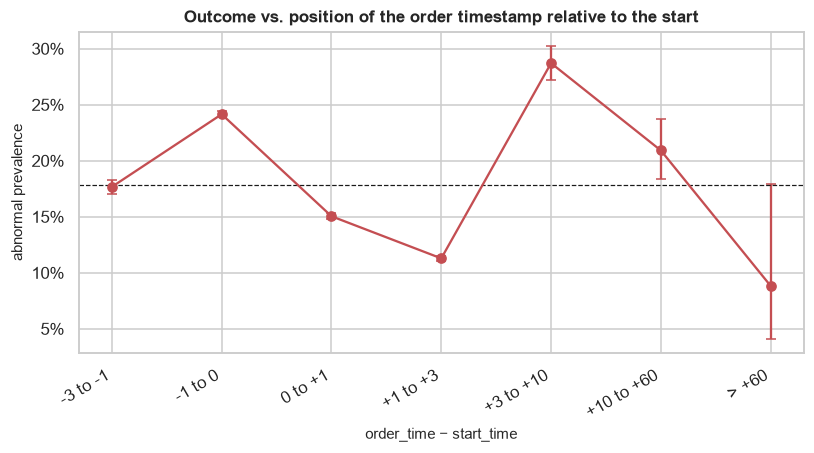

Share of sessions with order_time after start_time: 57.2%; AUC of the lag = 0.590


In [24]:
bins = [-np.inf, -3, -1, 0, 1, 3, 10, 60, np.inf]
labels = ["< -3 min", "-3 to -1", "-1 to 0", "0 to +1", "+1 to +3", "+3 to +10", "+10 to +60", "> +60"]
lag_bin = pd.cut(EDA["order_lag_min"], bins=bins, labels=labels)
lag_prev = prevalence_table(EDA.assign(lag_bin=lag_bin), "lag_bin")
lag_prev["share of sessions"] = lag_prev["n"] / lag_prev["n"].sum()
display(lag_prev.drop(columns=["ci_low", "ci_high"]).style.format({"prevalence": "{:.1%}", "share of sessions": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.errorbar(range(len(lag_prev)), lag_prev["prevalence"], yerr=[lag_prev["prevalence"] - lag_prev["ci_low"], lag_prev["ci_high"] - lag_prev["prevalence"]],
            fmt="o-", color=C_ABN, capsize=3)
ax.set_xticks(range(len(lag_prev))); ax.set_xticklabels(lag_prev.index, rotation=30, ha="right")
ax.axhline(EDA[TARGET].mean(), color="k", ls="--", lw=.8); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_xlabel("order_time − start_time"); ax.set_ylabel("abnormal prevalence"); ax.set_title("Outcome vs. position of the order timestamp relative to the start")
savefig(fig, "06_2_order_time_lag")
print(f"Share of sessions with order_time after start_time: {(EDA['order_lag_min'] > 0).mean():.1%}; "
      f"AUC of the lag = {auc_symmetric(EDA[TARGET], EDA['order_lag_min']):.3f}")

**Interpretation.**
* In **57.2%** of the sessions the order is stamped *after* the start, by up to 4,651 minutes. Even though the typical lag is a few minutes, the order timestamp is **not guaranteed to exist when the session starts**.
* The lag is associated with the outcome in a **non-monotone** way (24.1% abnormal when the order is stamped up to one minute *before* the start; 15.0% and 11.3% when it is stamped 0–3 minutes after; 28.7% when 3–10 minutes after), with a univariate AUC of 0.59. A plausible reading is that the lag reflects the *hand-shake between vehicle, post and platform* — information about how the start procedure went, which only exists after the session has begun.
* Because its availability at decision time is doubtful and its signal is small, `Order creation time` is **excluded from the main feature set**; its incremental value is quantified as a sensitivity experiment in §15.3.

### 6.3 Operational availability of the *legitimate* groups — an explicit statement

| Group | Formally available at start? | Operational condition that must hold in production | Verified? |
|-------|-----------------------------|----------------------------------------------------|-----------|
| Calendar / tariff | yes (deterministic function of the start timestamp) | none | trivially |
| Location (post, station, district) | yes | post is known when the plug is connected | trivially |
| Weather (daily, per district) | **assumed** (task statement) | a daily forecast for the district must be available; an *observed* daily aggregate would contain post-start information | **not verifiable** — stated as an assumption |
| Post history (16 attributes) | yes, if the platform keeps a rolling record of completed sessions per post | the outcome (`end_cause`) of a session is known when it ends, so only sessions completed *before* the start may be used | **yes** — recomputed from timestamps in §4.2–4.3 (`end ≤ start`) |
| User history (11 attributes) | yes, **if the account is identified at start** | requires linking the session to a persistent account identifier (privacy — §7.6/§17) | **yes**, same evidence |
| Concurrency (`user_active_sessions_at_start`) | yes | requires knowing which sessions of the same account are still running | **yes** — recomputed in §4.3 |
| Order creation time | ambiguous | see §6.2 | borderline → excluded |
| Energy, cost, amount, payment, end time, payment time | **no** | — | leakage (§6.1) |

**Decision.** Post-hoc variables and `end_cause` never enter a feature set; `Order creation time` is excluded from the main feature set and re-introduced only as a *sensitivity experiment* in §15.

In [25]:
log_decision("6", "Post-hoc variables", "Exclude energy_kwh, electricity_cost, service_charge, amount, actual_payment, end_time, payment_time (and any duration derived from end_time).",
             "Single post-hoc variables reach univariate AUC 0.82–0.85, above any legitimate variable (best 0.77); they measure the result of the session.")
log_decision("6", "Order creation time", "Exclude from the main feature set; test as a borderline group in §15.",
             "Stamped after the start in about half of the sessions (up to days later); its lag to the start is associated with the outcome.")

---
## 7. Exploratory analysis of the legitimate predictors

All statistics in this section use the **development window** (`EDA`). For every figure the questions are: *does the variable separate normal from abnormal sessions? by how much (effect size, not just significance)? is the relationship stable and generalisable? what does it imply for preparation and modelling?*

### 7.1 Location: post, station, district

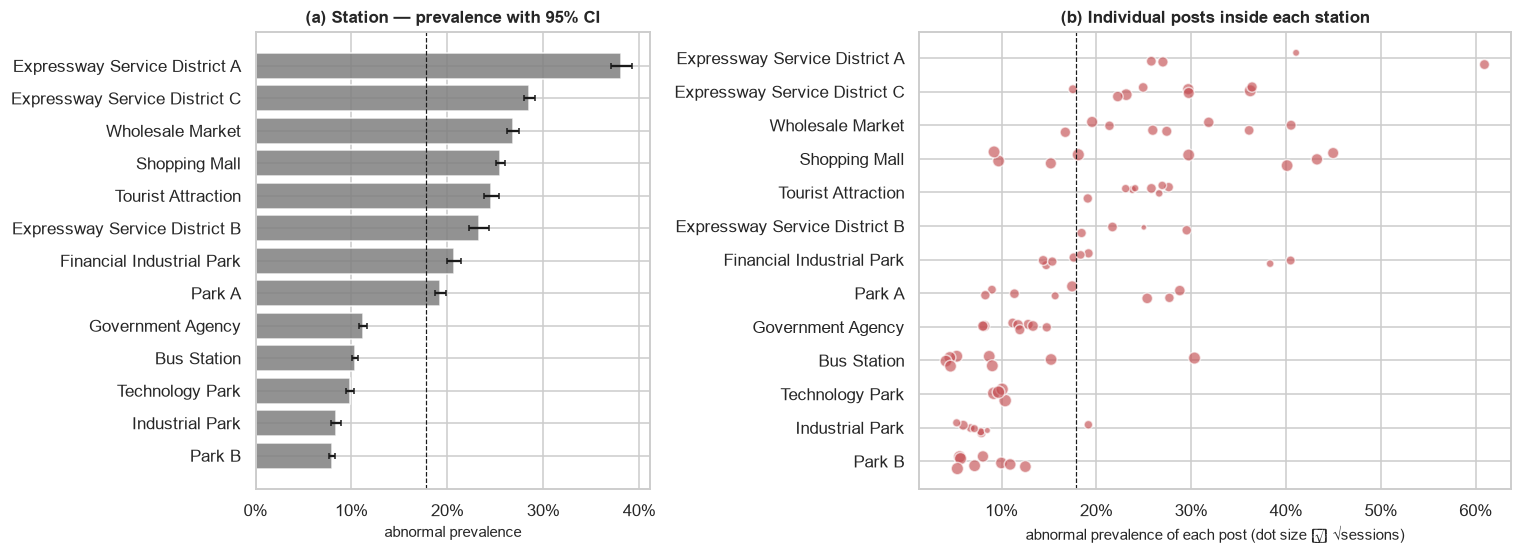

Share of target variance explained (in-sample η²):


,district (3),station (13),post (92)
eta²,0.012,0.051,0.092


In [26]:
by_loc = prevalence_table(EDA, "location").sort_values("prevalence")
by_dist = prevalence_table(EDA, "district").sort_values("prevalence")
by_post = prevalence_table(EDA, "post_id")
post_meta = EDA.groupby("post_id").agg(location=("location", "first"), district=("district", "first"))
by_post = by_post.join(post_meta)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1, 1.5]})
ax = axes[0]
ax.barh(by_loc.index, by_loc["prevalence"], xerr=[by_loc["prevalence"] - by_loc["ci_low"], by_loc["ci_high"] - by_loc["prevalence"]], color=C_NEUTRAL, alpha=.85, capsize=2)
ax.axvline(EDA[TARGET].mean(), color="k", ls="--", lw=.8); ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_title("(a) Station — prevalence with 95% CI"); ax.set_xlabel("abnormal prevalence")
ax = axes[1]
order_loc = by_loc.index.tolist()
bp = by_post.assign(loc_rank=by_post["location"].map({l: i for i, l in enumerate(order_loc)}))
ax.scatter(bp["prevalence"], bp["loc_rank"] + RNG.uniform(-.22, .22, len(bp)), s=np.sqrt(bp["n"]) * .9, alpha=.65, color=C_ABN, edgecolor="white")
ax.set_yticks(range(len(order_loc))); ax.set_yticklabels(order_loc); ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.axvline(EDA[TARGET].mean(), color="k", ls="--", lw=.8); ax.set_xlabel("abnormal prevalence of each post (dot size ∝ √sessions)")
ax.set_title("(b) Individual posts inside each station")
fig.tight_layout(); savefig(fig, "07_1_location_and_post_prevalence")

# variance decomposition: how much of the target variation is explained by station vs post (eta^2 / R^2 of one-way models)
def eta_squared(frame, by):
    m = frame.groupby(by)[TARGET].transform("mean")
    return float(((m - frame[TARGET].mean()) ** 2).sum() / ((frame[TARGET] - frame[TARGET].mean()) ** 2).sum())
print("Share of target variance explained (in-sample η²):")
display(pd.Series({"district (3)": eta_squared(EDA, "district"), "station (13)": eta_squared(EDA, "location"), "post (92)": eta_squared(EDA, "post_id")}).to_frame("eta²").T.style.format("{:.3f}"))

**Interpretation.**
* **Location matters, mostly through the post rather than the station or district.** The share of target variance explained is 1.2% (district), 5.1% (station) and 9.2% (post); Cramér's V is 0.11, 0.23 and 0.30 (in-sample; with 271k rows and 92 groups the optimism of η² is below 0.05 percentage points).
* Stations range from about 8% (Park B) to 38% (Expressway A) with narrow intervals — real differences. **Inside a station the posts are heterogeneous**: posts of Shopping Mall range from ≈9% to ≈45%, Bus Station from ≈4% to ≈30%, and one post of Expressway A reaches ≈61%. Station alone therefore does not identify a "bad" post; something specific to the *post* (hardware, maintenance) matters.
* **Implication.** Keep `post_id` as a categorical feature (92 levels, none rare — checked in §13), and keep `location` and `district` as *coarser hierarchical fall-backs* (they are functions of `post_id`, §3.3, but are the only information available for a post never seen in training). Post prevalence is only partially persistent (§5.3), so encodings that memorise it can be optimistic; the history features complement them.

### 7.2 Calendar and tariff

With ≈290k development sessions every hour-of-day difference is "significant"; the relevant question is the **effect size** (Cramér's V) and the **range** of prevalence.

,Cramér's V vs target
post_id,0.303
location,0.225
district,0.111
hour,0.042
tariff_period,0.038
is_new_user,0.023
dow,0.018
rain,0.012
is_weekend,0.001


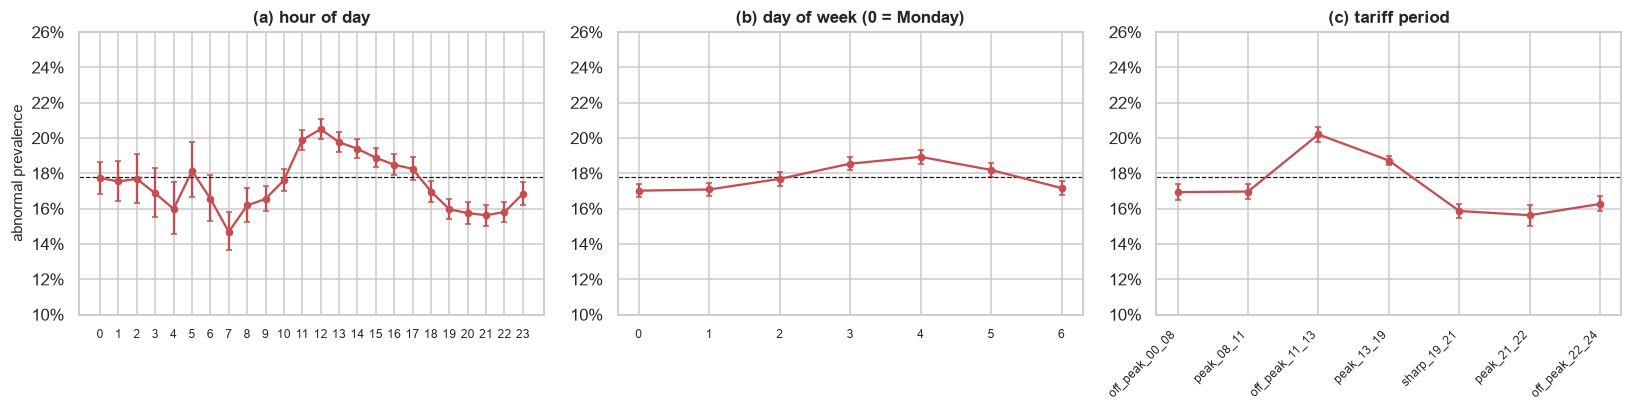

In [27]:
E = EDA.assign(hour=EDA["start_time"].dt.hour, dow=EDA["start_time"].dt.dayofweek, is_weekend=(EDA["start_time"].dt.dayofweek >= 5).astype(int),
               rain=(EDA["precipitation"] > 0).astype(int))
cv = pd.Series({c: cramers_v(E[c], E[TARGET]) for c in ["post_id", "location", "district", "tariff_period", "hour", "dow", "is_weekend", "rain", "is_new_user"]}).sort_values(ascending=False)
display(cv.to_frame("Cramér's V vs target").style.format("{:.3f}"))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.9))
for ax, (col, ttl, xt) in zip(axes, [("hour", "(a) hour of day", None), ("dow", "(b) day of week (0 = Monday)", None), ("tariff_period", "(c) tariff period", None)]):
    t = prevalence_table(E, col)
    if col == "tariff_period":
        t = t.loc[["off_peak_00_08", "peak_08_11", "off_peak_11_13", "peak_13_19", "sharp_19_21", "peak_21_22", "off_peak_22_24"]]
    xs = np.arange(len(t))
    ax.errorbar(xs, t["prevalence"], yerr=[t["prevalence"] - t["ci_low"], t["ci_high"] - t["prevalence"]], fmt="o-", color=C_ABN, capsize=2, ms=4)
    ax.axhline(E[TARGET].mean(), color="k", ls="--", lw=.8)
    ax.set_xticks(xs); ax.set_xticklabels(t.index, rotation=45 if col == "tariff_period" else 0, ha="right" if col == "tariff_period" else "center", fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0)); ax.set_title(ttl); ax.set_ylim(0.10, 0.26)
axes[0].set_ylabel("abnormal prevalence")
fig.tight_layout(); savefig(fig, "07_2_calendar_and_tariff")

**Interpretation.**
* **The calendar effects are small.** Cramér's V: hour 0.042, tariff period 0.038, day of week 0.018, weekend flag 0.001. The prevalence ranges from 14.7% (07h) to 20.5% (12h) across hours, from 15.6% (peak 21–22h) to 20.2% (off-peak 11–13h) across tariff periods and from 17.0% to 19.0% across weekdays. The midday hours are the riskiest; possible reasons (peak demand, shared power) are hypotheses that the data cannot test. The night hours have wide intervals (few sessions).
* The tariff curve **mirrors the hour curve** — expected, since the tariff period is a re-coding of the hour (§3.3) — and the weekend flag carries no information (V = 0.001), while the weekday curve is a mild inverted U (Thursday–Friday highest).
* **Implication.** Keep the hour and the day of week as *cyclical* features and the tariff period as a categorical; drop `is_weekend` (no signal, redundant with the day of week) and `electricity_price` (redundant, §3.3). Expect only weak marginal gains from this group, to be measured by ablation (§15).

### 7.3 Weather

Weather bins follow **domain-based cut points** (course slide: *custom/domain-based discretization*): meteorological rain classes and temperature bands. Bins are used here only for *exploration* — the models will receive the continuous values (see the discretization decision in §13).

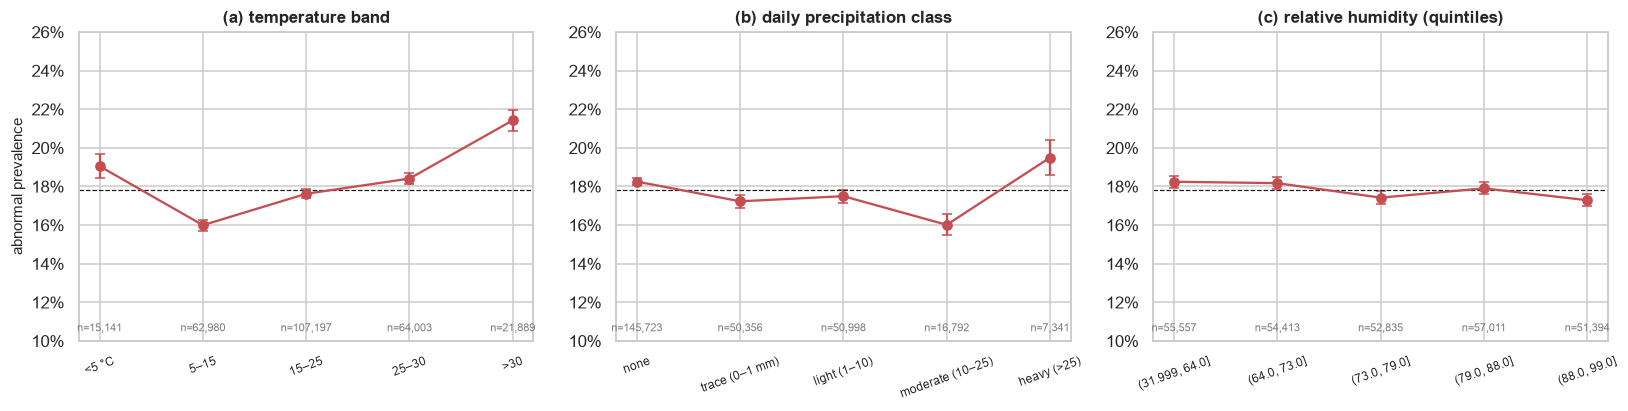

,temperature,humidity,precipitation
temperature,1.0000,0.1700,0.0600
humidity,0.1700,1.0000,0.7000
precipitation,0.0600,0.7000,1.0000


Share of sessions with precipitation > 0: 46.3% | Cramér's V (rain flag): 0.012


In [28]:
W = EDA.copy()
W["temp_band"] = pd.cut(W["temperature"], [-np.inf, 5, 15, 25, 30, np.inf], labels=["<5 °C", "5–15", "15–25", "25–30", ">30"])
W["rain_class"] = pd.cut(W["precipitation"], [-np.inf, 0, 1, 10, 25, np.inf], labels=["none", "trace (0–1 mm)", "light (1–10)", "moderate (10–25)", "heavy (>25)"])
W["hum_band"] = pd.qcut(W["humidity"], 5, duplicates="drop")
fig, axes = plt.subplots(1, 3, figsize=(15, 3.9))
for ax, col, ttl in zip(axes, ["temp_band", "rain_class", "hum_band"], ["(a) temperature band", "(b) daily precipitation class", "(c) relative humidity (quintiles)"]):
    t = prevalence_table(W, col)
    xs = np.arange(len(t))
    ax.errorbar(xs, t["prevalence"], yerr=[t["prevalence"] - t["ci_low"], t["ci_high"] - t["prevalence"]], fmt="o-", color=C_ABN, capsize=3)
    ax.axhline(W[TARGET].mean(), color="k", ls="--", lw=.8)
    ax.set_xticks(xs); ax.set_xticklabels([str(i) for i in t.index], rotation=20, fontsize=8); ax.set_title(ttl)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0)); ax.set_ylim(0.10, 0.26)
    for xi, n_ in zip(xs, t["n"]): ax.text(xi, 0.105, f"n={n_:,}", ha="center", fontsize=7, color=C_NEUTRAL)
axes[0].set_ylabel("abnormal prevalence")
fig.tight_layout(); savefig(fig, "07_3_weather")
display(EDA[["temperature", "humidity", "precipitation"]].corr(method="spearman").round(2))
print("Share of sessions with precipitation > 0:", f"{(EDA['precipitation'] > 0).mean():.1%}",
      "| Cramér's V (rain flag):", round(cv["rain"], 3))

**Interpretation.**
* **Weak, non-linear and partly noisy relationships.** Temperature is U-shaped: 16.0% abnormal at 5–15 °C against 19.0% below 5 °C and 21.4% above 30 °C. Rain is non-monotone (18.2% without rain, 16.0% for moderate rain, 19.5% for heavy rain with only 7,341 sessions) and humidity is flat (17.3–18.2%). Cramér's V of the rain flag is 0.012.
* **Humidity and precipitation are strongly related** (Spearman ρ = 0.70) while temperature is almost independent of both; 46% of the sessions fall on days with rain, so precipitation is *zero-inflated and right-skewed*.
* **The effective sample size of weather is small**: weather takes one value per district and day, i.e. roughly 3 districts × 456 days ≈ 1,400 distinct values, not 271k. A model can easily over-fit them, and their effect is confounded with season and with the temporal regime changes of §5.
* **Implication.** Keep the three variables as one group with low expectations. Linear models need a non-linear encoding of temperature (the U-shape); precipitation is transformed with `log1p` (and a rain flag is added) in §11; tree models handle both natively.

### 7.4 History attributes — the main operational signal

Each panel bins a history variable into deciles (equal-frequency discretization, only for visualisation) and shows the observed prevalence per bin. A monotone, steep curve means that recent history *discriminates* future outcomes; a flat curve means it does not.

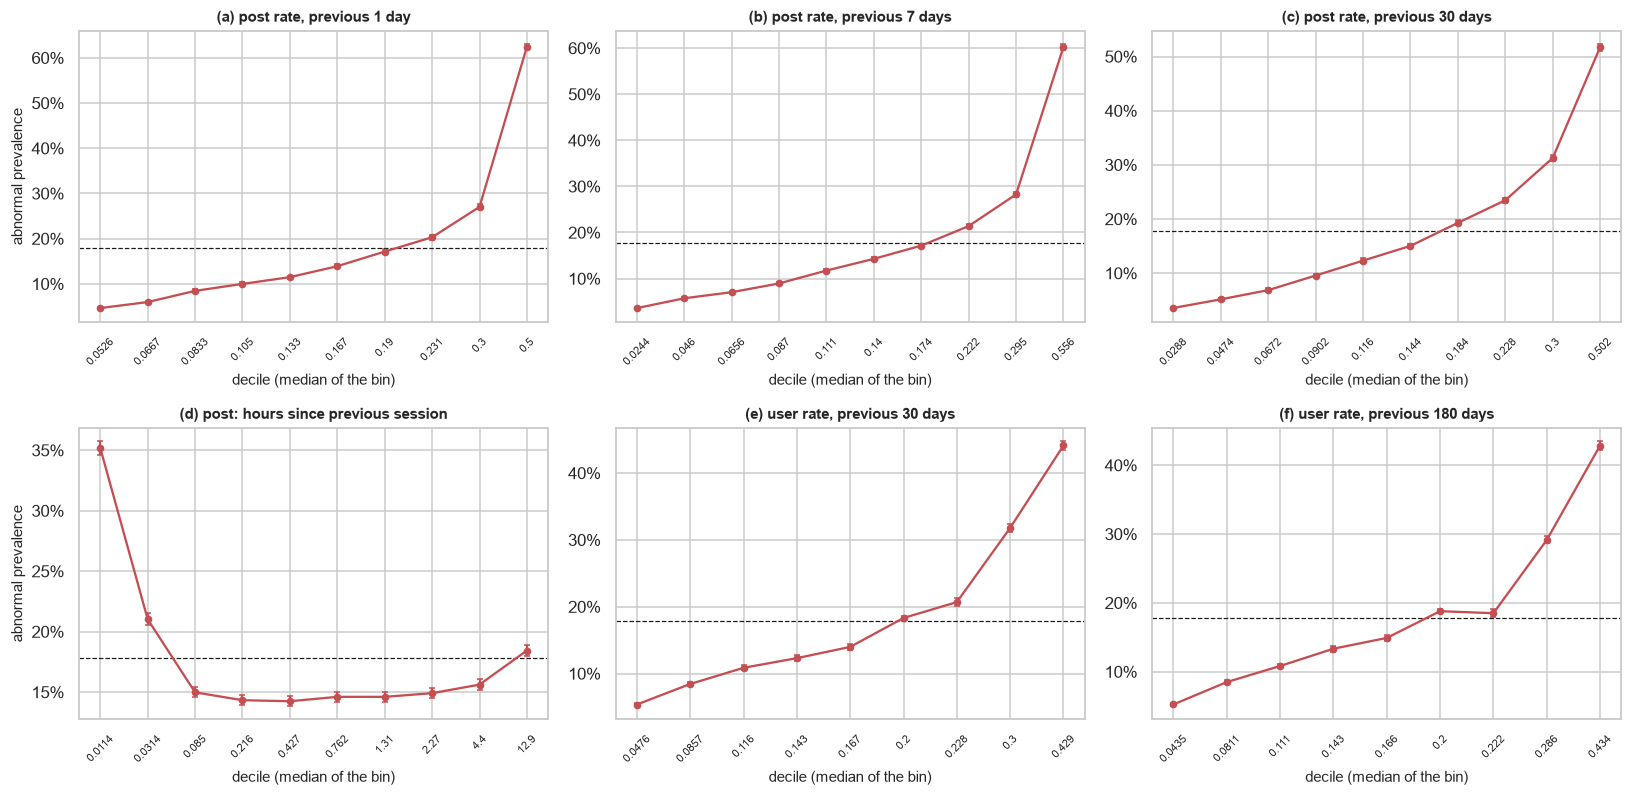

In [29]:
def decile_curve(ax, frame, col, title, q=10, log_x=False):
    b = pd.qcut(frame[col], q, duplicates="drop")
    t = prevalence_table(frame.assign(bin=b), "bin")
    centres = frame.groupby(b, observed=True)[col].median().to_numpy()
    ax.errorbar(range(len(t)), t["prevalence"], yerr=[t["prevalence"] - t["ci_low"], t["ci_high"] - t["prevalence"]], fmt="o-", color=C_ABN, capsize=2, ms=4)
    ax.axhline(frame[TARGET].mean(), color="k", ls="--", lw=.8)
    ax.set_xticks(range(len(t))); ax.set_xticklabels([f"{c:.3g}" for c in centres], rotation=45, fontsize=7)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0)); ax.set_title(title, fontsize=10); ax.set_xlabel("decile (median of the bin)")

panels = [("post_previous_abnormal_rate_1D", "(a) post rate, previous 1 day"),
          ("post_previous_abnormal_rate_7D", "(b) post rate, previous 7 days"),
          ("post_previous_abnormal_rate_30D", "(c) post rate, previous 30 days"),
          ("post_hours_since_previous_completed_session", "(d) post: hours since previous session"),
          ("user_previous_abnormal_rate_30D", "(e) user rate, previous 30 days"),
          ("user_previous_abnormal_rate_180D", "(f) user rate, previous 180 days")]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.4))
for ax, (c, t_) in zip(axes.ravel(), panels):
    decile_curve(ax, EDA.dropna(subset=[c]), c, t_)
for ax in axes[:, 0]: ax.set_ylabel("abnormal prevalence")
fig.tight_layout(); savefig(fig, "07_4_history_decile_curves")

**Interpretation.**
* **Post history has strong, monotone gradients.** From the lowest to the highest decile of the 7-day post rate the observed prevalence goes from ≈4% to ≈60%; the 1-day rate has the steepest tail (62% in the top decile) but is noisier, while the 30-day rate is smoother (3% → 52%). Short windows react quickly (a failing post keeps failing), long windows are more stable — **the three windows carry different time scales and are all kept**.
* **Time since the previous completed session (d) is U-shaped**: when the previous session ended only about 40 seconds earlier the prevalence is 35%, at 2 minutes 21%, it is flat at 14–15% between ≈5 minutes and one day, and rises again to 18.5% for gaps of many hours. Rapid successions look like *retry cycles after a failure*; long gaps may reflect out-of-service periods. The non-monotone shape argues for a non-linear model or a log transform.
* **User history gradients are also monotone** (5% → 44% for the 30-day rate). The value 0.2 (the prior given to users without history, §4.3) lies in the middle deciles: **cold-start users are mapped to mid-range risk by construction**.
* All confidence intervals are tiny, so these curves are stable estimates, not noise.

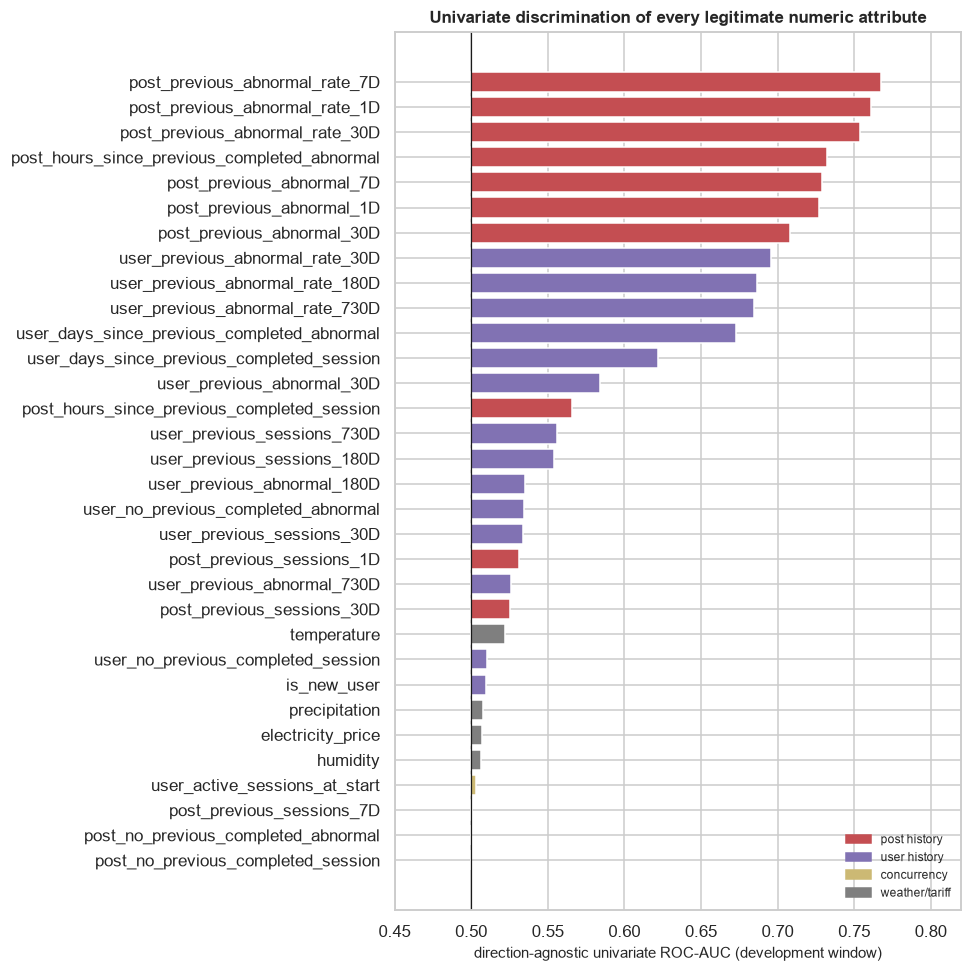

,AUC,missing %,skewness,group
post_previous_abnormal_rate_7D,0.768,0.0,2.3,post history
post_previous_abnormal_rate_1D,0.761,0.0,2.2,post history
post_previous_abnormal_rate_30D,0.754,0.0,2.1,post history
post_hours_since_previous_completed_abnormal,0.732,0.0,7.8,post history
post_previous_abnormal_7D,0.729,0.0,4.3,post history
post_previous_abnormal_1D,0.727,0.0,5.3,post history
post_previous_abnormal_30D,0.708,0.0,3.3,post history
user_previous_abnormal_rate_30D,0.695,0.0,1.5,user history
user_previous_abnormal_rate_180D,0.686,0.0,1.5,user history
user_previous_abnormal_rate_730D,0.685,0.0,1.5,user history


In [30]:
# Ranking of all numeric legitimate attributes by univariate discrimination (missing values filled with the median only for this diagnostic).
numeric_legit = (["temperature", "humidity", "precipitation", "electricity_price", "user_active_sessions_at_start"]
                 + [c for c in HIST_POST + HIST_USER if c not in ("is_new_user",)] + ["is_new_user"])
uni = pd.DataFrame({
    "AUC": {c: auc_symmetric(EDA[TARGET], fill_median(EDA[c])) for c in numeric_legit},
    "missing %": {c: EDA[c].isna().mean() * 100 for c in numeric_legit},
    "skewness": {c: EDA[c].skew() for c in numeric_legit},
}).sort_values("AUC", ascending=False)
uni["group"] = ["post history" if c in HIST_POST else "user history" if c in HIST_USER else "concurrency" if c in CONCURRENCY else "weather/tariff" for c in uni.index]
fig, ax = plt.subplots(figsize=(9, 9))
palette_g = {"post history": C_ABN, "user history": "#8172B3", "concurrency": "#CCB974", "weather/tariff": C_NEUTRAL}
ax.barh(uni.index[::-1], uni["AUC"][::-1] - .5, left=.5, color=uni["group"][::-1].map(palette_g))
ax.axvline(.5, color="k", lw=.8); ax.set_xlim(.45, .82); ax.set_xlabel("direction-agnostic univariate ROC-AUC (development window)")
ax.set_title("Univariate discrimination of every legitimate numeric attribute")
handles = [plt.Rectangle((0, 0), 1, 1, color=v) for v in palette_g.values()]
ax.legend(handles, palette_g.keys(), loc="lower right", fontsize=8)
plt.tight_layout(); savefig(fig, "07_4b_univariate_auc_ranking")
display(uni.head(12).style.format({"AUC": "{:.3f}", "missing %": "{:.1f}", "skewness": "{:.1f}"}))

**Interpretation.**
* The ranking confirms that **the seven post-history variables occupy the top positions** (AUC 0.71–0.77; `post_hours_since_previous_completed_abnormal` reaches 0.73, an indicator of fault clustering), followed by the user-history variables (0.67–0.70). Volume-type counts have AUCs of only 0.50–0.57 individually.
* Time-since and count variables are **strongly right-skewed** (skewness 4–8), which matters for linear/distance-based models (transformation in §11/§13). Missing values occur only in the four time-since variables (0–30%), and they are structural (§8).
* A univariate ranking cannot see interactions or redundancy between the 26 history variables; it is complemented by the correlation/VIF analysis (§12) and by the group ablation (§15).

### 7.5 Users: concentration and heterogeneity

Users cannot be used as an identifier feature (56k accounts, most with one or two sessions, and most users seen in the test period have never been seen in training). But *how* users are distributed affects the meaning of the user-history attributes.

Accounts: 34,294 | median sessions per account: 2 | accounts with a single session: 44.9%
Top 1% of accounts hold 34.2% of sessions; top-10 accounts hold 6.8%


,sessions,abnormal,posts_used,prevalence
user_id,,,,
39,9044,1366,92,0.1510
23,3308,580,92,0.1753
7841,905,107,41,0.1182
1087,864,155,43,0.1794
35,748,143,22,0.1912
4990,746,53,13,0.0710
1457,713,129,58,0.1809
3679,702,104,50,0.1481


,n,abnormal,prevalence,share of sessions,accounts
user_volume,,,,,
1,15404,1294,8.4%,5.7%,15404
2–5,36689,9837,26.8%,13.5%,13042
6–20,36572,8724,23.9%,13.5%,3702
21–100,76616,12117,15.8%,28.2%,1686
>100,105929,16348,15.4%,39.1%,460


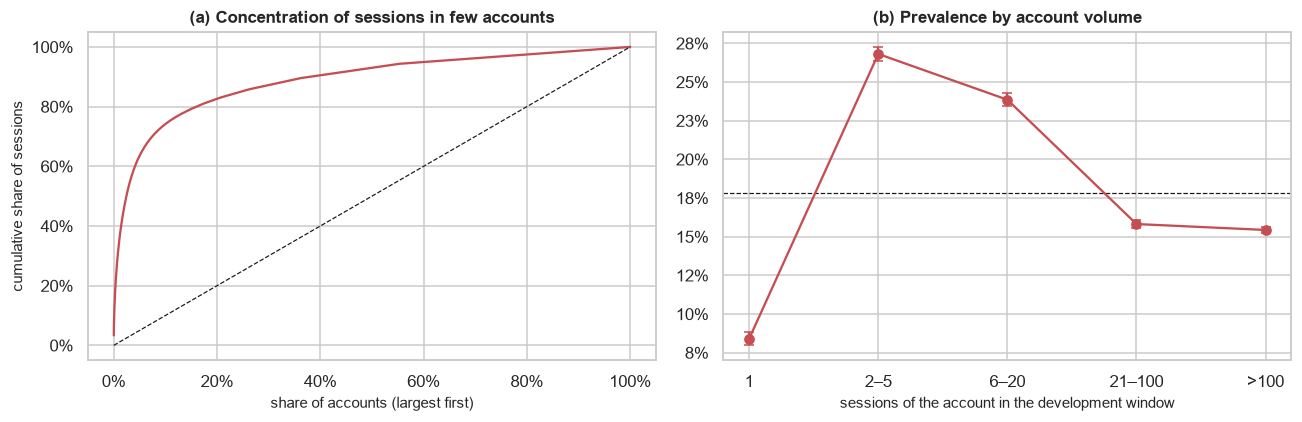

In [31]:
u = EDA.groupby("user_id").agg(sessions=("row_id", "size"), abnormal=(TARGET, "sum"), posts_used=("post_id", "nunique"))
u["prevalence"] = u["abnormal"] / u["sessions"]
u_sorted = u.sort_values("sessions", ascending=False)
share_top1 = u_sorted["sessions"].head(int(len(u) * .01)).sum() / u["sessions"].sum()
share_top10 = u_sorted["sessions"].head(10).sum() / u["sessions"].sum()
print(f"Accounts: {len(u):,} | median sessions per account: {u['sessions'].median():.0f} | accounts with a single session: {(u['sessions'] == 1).mean():.1%}")
print(f"Top 1% of accounts hold {share_top1:.1%} of sessions; top-10 accounts hold {share_top10:.1%}")
display(u_sorted.head(8))

seg = EDA.merge(u["sessions"].rename("user_sessions_in_window"), left_on="user_id", right_index=True)
seg["user_volume"] = pd.cut(seg["user_sessions_in_window"], [0, 1, 5, 20, 100, np.inf], labels=["1", "2–5", "6–20", "21–100", ">100"])
seg_t = prevalence_table(seg, "user_volume")
seg_t["share of sessions"] = seg_t["n"] / seg_t["n"].sum()
seg_t["accounts"] = u.groupby(pd.cut(u["sessions"], [0, 1, 5, 20, 100, np.inf], labels=["1", "2–5", "6–20", "21–100", ">100"]), observed=True).size()
display(seg_t.drop(columns=["ci_low", "ci_high"]).style.format({"prevalence": "{:.1%}", "share of sessions": "{:.1%}"}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cum = np.cumsum(u_sorted["sessions"].to_numpy()) / u["sessions"].sum()
axes[0].plot(np.arange(1, len(cum) + 1) / len(cum), cum, color=C_ABN); axes[0].plot([0, 1], [0, 1], "k--", lw=.8)
axes[0].set_xlabel("share of accounts (largest first)"); axes[0].set_ylabel("cumulative share of sessions"); axes[0].set_title("(a) Concentration of sessions in few accounts")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0)); axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
axes[1].errorbar(range(len(seg_t)), seg_t["prevalence"], yerr=[seg_t["prevalence"] - seg_t["ci_low"], seg_t["ci_high"] - seg_t["prevalence"]], fmt="o-", color=C_ABN, capsize=3)
axes[1].set_xticks(range(len(seg_t))); axes[1].set_xticklabels(seg_t.index); axes[1].set_xlabel("sessions of the account in the development window")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0)); axes[1].axhline(EDA[TARGET].mean(), color="k", ls="--", lw=.8)
axes[1].set_title("(b) Prevalence by account volume")
fig.tight_layout(); savefig(fig, "07_5_user_concentration")

**Interpretation.**
* **Users are extremely concentrated.** The development window has 34,294 accounts; the median account has 2 sessions and 44.9% have a single session, while the top 1% of accounts hold 34.2% of the sessions. Accounts 39 and 23 have 9,044 and 3,308 sessions in 15 months and use all 92 posts: they are probably operator, fleet or aggregator accounts (this cannot be verified from the data).
* Prevalence by *account volume in the window* is 8.4% for one-session accounts, 26.8% for 2–5 sessions, 23.9% for 6–20, 15.8% for 21–100 and 15.4% above 100. **This variable uses future sessions and can never be a feature**, but the pattern is informative: users whose session failed come back to retry, so accounts with a few sessions are enriched in failures, and one-session accounts in successes. It is a selection effect that explains *why previous outcomes of the user are predictive*.
* **Implications.** `user_id` is a key field and is dropped as a feature (56k levels, and most test sessions come from accounts never seen in training — quantified in §10); the history attributes are the legitimate substitute. Fleet accounts are *valid observations with a very different scale* — they are retained and handled by transformation, not by deletion (§9). **Privacy:** user history is a behavioural profile attached to a persistent pseudonymous identifier; under data-minimisation and purpose-limitation principles (GDPR-type regulation) it should be used only if it adds value beyond post-level information — this is tested in the ablation (§15) and discussed in §17.

### 7.6 Cold start, concurrency, privacy and generalisation

**Cold-start cases** are sessions for which the *history features carry no information*: `is_new_user = 1` (no earlier session of the account) or a post without earlier sessions. For them the smoothed rate is the constant prior 0.2 (§4.3) and the time-since variables are missing.

In [32]:
cs = pd.DataFrame({
    "sessions": [(EDA["is_new_user"] == 1).sum(), (EDA["is_new_user"] == 0).sum(),
                 (EDA["user_no_previous_completed_abnormal"] == 1).sum(), (EDA["user_no_previous_completed_abnormal"] == 0).sum(),
                 (EDA["post_no_previous_completed_session"] == 1).sum()],
}, index=["is_new_user = 1 (cold-start user)", "is_new_user = 0", "user without any previous abnormal session", "user with ≥ 1 previous abnormal session", "post without previous completed session"])
cs["abnormal prevalence"] = [EDA.loc[EDA["is_new_user"] == 1, TARGET].mean(), EDA.loc[EDA["is_new_user"] == 0, TARGET].mean(),
                             EDA.loc[EDA["user_no_previous_completed_abnormal"] == 1, TARGET].mean(), EDA.loc[EDA["user_no_previous_completed_abnormal"] == 0, TARGET].mean(),
                             EDA.loc[EDA["post_no_previous_completed_session"] == 1, TARGET].mean()]
cs["share of sessions"] = cs["sessions"] / len(EDA)
display(cs.style.format({"abnormal prevalence": "{:.1%}", "share of sessions": "{:.2%}"}))

conc = EDA.assign(active=EDA["user_active_sessions_at_start"].clip(upper=3))
conc_t = prevalence_table(conc, "active")
display(conc_t.rename(index={3: "3+"}).style.format({"prevalence": "{:.1%}", "ci_low": "{:.1%}", "ci_high": "{:.1%}"}))
print("Rows whose user_previous_abnormal_rate_730D equals exactly the prior 0.2 (no history):",
      f"{(EDA['user_previous_sessions_730D'] == 0).mean():.1%}")

,sessions,abnormal prevalence,share of sessions
is_new_user = 1 (cold-start user),32561,20.2%,12.01%
is_new_user = 0,238649,17.5%,87.99%
user without any previous abnormal session,80433,14.4%,29.66%
user with ≥ 1 previous abnormal session,190777,19.3%,70.34%
post without previous completed session,0,nan%,0.00%


,n,abnormal,prevalence,ci_low,ci_high
active,,,,,
0,258953,45884,17.7%,17.6%,17.9%
1,6471,1572,24.3%,23.3%,25.4%
2,1946,322,16.5%,15.0%,18.3%
3+,3840,542,14.1%,13.0%,15.3%


Rows whose user_previous_abnormal_rate_730D equals exactly the prior 0.2 (no history): 12.1%


**Interpretation.**
* **Cold-start users** (`is_new_user = 1`) are 12.0% of the development sessions; their prevalence is 20.2% against 17.5% for the others, but the flag alone has an AUC of only 0.51. For them all user history is absent or equal to the prior, so the model can rely only on post and context information.
* Users **without any previous abnormal session** (29.7% of the sessions) have 14.4% prevalence against 19.3% for those with at least one: a previous failure of the user is a real (repeat/retry or vehicle-related) signal.
* **Concurrency** is non-monotone: 17.7% with no other active session, 24.3% with exactly one (n = 6,471), 16.5% with two and 14.1% with three or more. The effect is small in isolation (AUC 0.50) and may only matter through interactions.
* **No post cold-start exists in the development window**: the two post "no history" flags are 1 only for the first sessions of each post in January 2020 (burn-in). In training they are constant, cannot be learned and are dropped (§11).
* **Generalisation.** History features let the model use *the past of the post and of the user* instead of identities, which generalises to unseen users (most test sessions belong to accounts not in training — §10) but not to unseen posts without a history.

---
## 8. Missing values

Course slide: *missing data can appear in several forms* (`<empty>`, `0`, `.`, `999`, `unknown`, …) — **standardise the codes first**, then decide. Only after understanding *why* a value is missing is an imputation strategy chosen (mean/median imputation "reduces the variance and may distort the distribution"; model-based imputation is required if missingness is *not at random*).

### 8.1 Where are values missing, and why?

In [33]:
FLAG_OF = {
    "post_hours_since_previous_completed_session": "post_no_previous_completed_session",
    "post_hours_since_previous_completed_abnormal": "post_no_previous_completed_abnormal",
    "user_days_since_previous_completed_session": "user_no_previous_completed_session",
    "user_days_since_previous_completed_abnormal": "user_no_previous_completed_abnormal",
}
miss = pd.DataFrame({
    "n missing": df[list(FLAG_OF)].isna().sum(),
    "% missing": df[list(FLAG_OF)].isna().mean() * 100,
    "companion indicator": pd.Series(FLAG_OF),
    "NaN ⇔ indicator = 1 (every row)": {c: bool((df[c].isna() == (df[f] == 1)).all()) for c, f in FLAG_OF.items()},
})
display(miss.style.format({"n missing": "{:,.0f}", "% missing": "{:.2f}"}))
print("Columns with missing values in the whole file:", df.columns[df.isna().any()].tolist())

# standardisation of missing-value codes: scan for disguised missing values in every numeric column
SENTINELS = [-1, -9, -99, -999, -9999, 999, 9999, 99999]
num_all = [c for c in df.select_dtypes(include="number").columns if c not in ("row_id", "user_id", "post_id", "duration_h", "order_lag_min", "payment_lag_h", TARGET)]
hits = pd.DataFrame({c: {f"= {v}": int((df[c] == v).sum()) for v in SENTINELS} for c in num_all}).T
hits = hits.loc[hits.sum(axis=1) > 0]
print("\nNumeric columns containing a typical 'disguised missing' code (count of rows):")
display(hits if len(hits) else "none")
print("Text columns — labels that mean 'unknown':",
      {c: [v for v in df[c].unique() if str(v).strip().lower() in {"unknown", "unk", "na", "n/a", "", "-", "none", "null"}] for c in ["location", "district", "tariff_period", "end_cause"]})

# temporal pattern and informativeness of the missingness (development window for prevalence)
qtr = df["start_time"].dt.to_period("Q").astype(str)
display((df[list(FLAG_OF)].isna().groupby(qtr).mean() * 100).round(2).T.rename_axis("% missing by quarter"))
info = pd.DataFrame({c: {"prevalence if missing": EDA.loc[EDA[c].isna(), TARGET].mean() if EDA[c].isna().any() else np.nan,
                         "prevalence if observed": EDA.loc[EDA[c].notna(), TARGET].mean(),
                         "sessions missing (dev. window)": int(EDA[c].isna().sum())} for c in FLAG_OF}).T
display(info.style.format({"prevalence if missing": "{:.1%}", "prevalence if observed": "{:.1%}", "sessions missing (dev. window)": "{:,.0f}"}))

,n missing,% missing,companion indicator,NaN ⇔ indicator = 1 (every row)
post_hours_since_previous_completed_session,92,0.02,post_no_previous_completed_session,True
post_hours_since_previous_completed_abnormal,367,0.08,post_no_previous_completed_abnormal,True
user_days_since_previous_completed_session,"56,647",12.84,user_no_previous_completed_session,True
user_days_since_previous_completed_abnormal,"136,279",30.90,user_no_previous_completed_abnormal,True


Columns with missing values in the whole file: ['post_hours_since_previous_completed_session', 'post_hours_since_previous_completed_abnormal', 'user_days_since_previous_completed_session', 'user_days_since_previous_completed_abnormal']

Numeric columns containing a typical 'disguised missing' code (count of rows):


,= -1,= -9,= -99,= -999,= -9999,= 999,= 9999,= 99999
user_previous_sessions_30D,0,0,0,0,0,2,0,0
user_previous_sessions_180D,0,0,0,0,0,1,0,0
user_previous_sessions_730D,0,0,0,0,0,2,2,0
user_previous_abnormal_730D,0,0,0,0,0,1,0,0


Text columns — labels that mean 'unknown': {'location': [], 'district': [], 'tariff_period': [], 'end_cause': []}


start_time,2019Q4,2020Q1,2020Q2,2020Q3,2020Q4,2021Q1,2021Q2,2021Q3,2021Q4
% missing by quarter,,,,,,,,,
post_hours_since_previous_completed_session,100.0000,0.5400,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
post_hours_since_previous_completed_abnormal,100.0000,2.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
user_days_since_previous_completed_session,100.0000,26.2900,12.2600,10.6300,11.3200,12.5400,14.2300,12.7600,13.0500
user_days_since_previous_completed_abnormal,100.0000,48.1100,30.7700,25.7700,27.7200,30.7100,34.6700,30.4000,32.5400


,prevalence if missing,prevalence if observed,sessions missing (dev. window)
post_hours_since_previous_completed_session,nan%,17.8%,0
post_hours_since_previous_completed_abnormal,nan%,17.8%,0
user_days_since_previous_completed_session,20.3%,17.5%,"32,829"
user_days_since_previous_completed_abnormal,14.4%,19.3%,"80,433"


**Interpretation.**
* **Missingness is structural, not accidental.** In every row, `NaN` in a "time since previous …" variable coincides *exactly* with the companion indicator equal to 1 (the entity has no previous completed session/abnormal session). The value does not exist because the event never happened — it is *not* "unknown". No disguised missing codes (`-1`, `999`, …) exist beyond isolated legitimate counts, and no text label means "unknown".
* **Time pattern.** The two *post* variables are missing only at the start of the file (each post's first session or first failure), so they vanish after the burn-in; the two *user* variables stay missing permanently (12% and 30% of the development sessions) because new and never-failed users keep arriving.
* **The missingness is informative.** Users with no previous abnormal session have a lower prevalence (14.4% vs 19.3%; §7.6). Any strategy that hides the missingness (e.g. plain median imputation) throws this information away.

**Decisions** (the imputation *values* are learned on the training window only, §13):

| Aspect | Decision | Justification |
|--------|----------|---------------|
| Row deletion | **No** rows are dropped for missingness | 12–30% of the rows in the user variables; deleting them would remove exactly the cold-start users the model must handle. |
| Mean/median imputation | **Rejected** | Structural missingness ≠ "typical value"; a median gap (e.g. 0.7 days) would tell the model that a brand-new user is a frequent user; it also shrinks variance (slide *Dealing with missing values*). |
| Model-based imputation (regression/kNN) | **Rejected** | The data-generating mechanism is known (event never happened); predicting a "plausible gap" from other variables fabricates information. |
| **Tree view** | **Keep `NaN`** (native support in gradient boosting) + keep the indicators | Lets the model split on "no event" directly, no fabricated value. |
| **Linear/distance view** | Impute with the **training-set maximum** of the (log-)variable + keep the indicators | "Never happened" ≡ arbitrarily long time since the last event, i.e. the far end of the observable range; the indicator lets the model correct the level. Compared against median imputation in §13.4. |
| Post indicators | see §11 | They are constant in the development window. |

In [34]:
log_decision("8", "Missing values", "No deletion / no median or model-based imputation. Tree view: keep NaN + indicators. Linear view: impute with training maximum of the (log-)variable + keep indicators.",
             "NaN ⇔ companion indicator = 1 in 100% of rows (structural); informative (14.4% vs 19.3% prevalence); no disguised codes.", learned=True)

---
## 9. Outliers

**Principle (course slides).** Outliers "have distinct characteristics from most of the other objects, *but they may be valid*". The workflow is therefore: **detect → investigate validity → choose among retention / transformation / capping / removal** according to the meaning of the variable and the sensitivity of the model (decision trees are insensitive; distance/gradient-based models are not).

### 9.1 Univariate screening (numerical summaries)

Tukey's fences (Q1 − 1.5·IQR, Q3 + 1.5·IQR) are computed for the numeric legitimate variables. For zero-inflated variables the IQR is 0 and the fences degenerate, which the table flags explicitly.

,min,median,p99,max,max / p99,skewness,IQR = 0,% beyond fences
post_hours_since_previous_completed_session,0.00111,0.576,26.1,2.26e+03,86.5,66.1,False,12.3
user_active_sessions_at_start,0,0,3,14,4.7,8.7,True,4.5
post_hours_since_previous_completed_abnormal,0.00111,19.9,396,2.31e+03,5.8,7.8,False,9.2
user_days_since_previous_completed_session,1.16e-05,0.716,138,533,3.9,7.7,False,15.2
user_previous_sessions_30D,0,9,1.93e+03,2.6e+03,1.3,7.4,False,6.7
precipitation,0,0,36.2,152,4.2,6.8,False,16.5
user_previous_sessions_180D,0,21,4.83e+03,6.5e+03,1.3,6.3,False,10.8
user_previous_sessions_730D,0,24,7.23e+03,9.95e+03,1.4,6.2,False,11.5
user_previous_abnormal_30D,0,1,260,329,1.3,6.2,False,11.1
user_previous_abnormal_730D,0,3,1.12e+03,1.55e+03,1.4,6.0,False,12.7


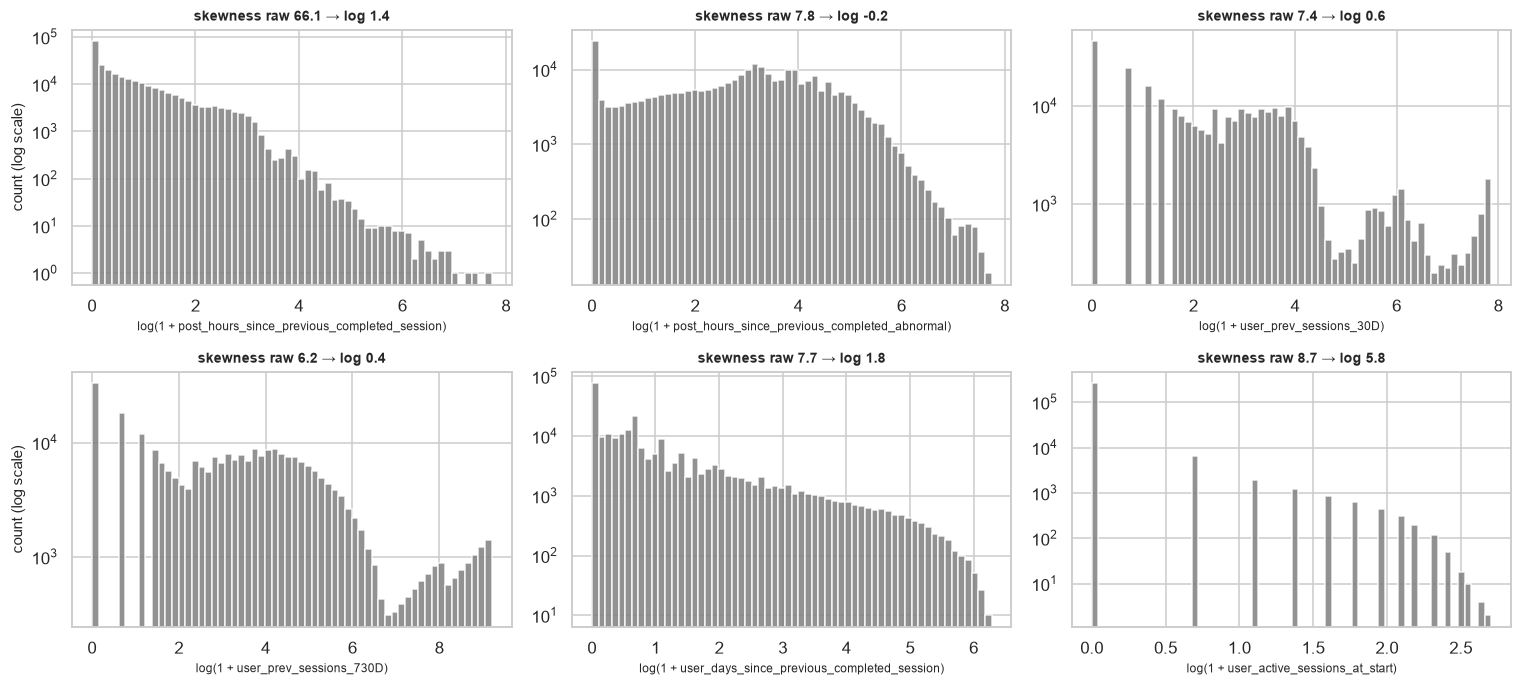

In [35]:
cont_cols = [c for c in numeric_legit if EDA[c].nunique() > 2]


def tukey_report(s: pd.Series) -> dict:
    s = s.dropna()
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return {"min": s.min(), "median": s.median(), "p99": s.quantile(.99), "max": s.max(),
            "max / p99": s.max() / s.quantile(.99) if s.quantile(.99) > 0 else np.nan,
            "skewness": s.skew(), "IQR = 0": iqr == 0, "% beyond fences": ((s < lo) | (s > hi)).mean() * 100}


out_tab = pd.DataFrame({c: tukey_report(EDA[c]) for c in cont_cols}).T.sort_values("skewness", ascending=False)
display(out_tab.style.format({"min": "{:,.3g}", "median": "{:,.3g}", "p99": "{:,.3g}", "max": "{:,.3g}", "max / p99": "{:,.1f}",
                              "skewness": "{:,.1f}", "% beyond fences": "{:,.1f}"}))

heavy = ["post_hours_since_previous_completed_session", "post_hours_since_previous_completed_abnormal", "user_previous_sessions_30D",
         "user_previous_sessions_730D", "user_days_since_previous_completed_session", "user_active_sessions_at_start"]
fig, axes = plt.subplots(2, 3, figsize=(14, 6.4))
for ax, c in zip(axes.ravel(), heavy):
    v = np.log1p(EDA[c].dropna())
    ax.hist(v, bins=60, color=C_NEUTRAL, alpha=.85)
    ax.set_yscale("log"); ax.set_xlabel(f"log(1 + {c.replace('post_previous', 'post_prev').replace('user_previous', 'user_prev')})", fontsize=8)
    ax.set_title(f"skewness raw {EDA[c].skew():.1f} → log {v.skew():.1f}", fontsize=9)
axes[0, 0].set_ylabel("count (log scale)"); axes[1, 0].set_ylabel("count (log scale)")
fig.tight_layout(); savefig(fig, "09_1_heavy_tailed_features_log_scale")

**Interpretation.**
* Three families appear: (i) **bounded, mildly skewed variables** — post rates (skewness 2.1–2.3), user rates (1.5), volume counts of the post (0.1–1.4) — and **symmetric weather variables** (temperature, humidity) and tariff price; (ii) **heavy-tailed counts and time-since variables** with skewness between 3 and 9 (66 for `post_hours_since_previous_completed_session`, whose maximum is 86 times its 99th percentile, i.e. a handful of extremely long idle periods); the user counts have skewness 6–7 with a maximum only 1.3 times the 99th percentile because the 99th percentile itself already lies in the fleet-account range; (iii) **zero-inflated variables** (`user_active_sessions_at_start`, and `precipitation`, with skewness 8.7 and 6.8) for which the fences degenerate (IQR = 0 for the former), so "% beyond fences" is not meaningful there.
* A logarithmic transformation reduces the skewness of the heavy-tailed variables to below 2 (histograms; note the log-scaled counts), except for the zero-inflated `user_active_sessions_at_start`. This is the course's *log transformation* for "features with severe skewness".
* These figures say nothing yet about *validity*. That is investigated next.

### 9.2 Are the extremes errors or real phenomena?

Three concrete extremes are investigated: (a) very long idle periods of a post, (b) accounts with thousands of sessions, (c) very high rainfall.

In [36]:
# (a) very long idle gaps of a post (> 14 days)
long_gap = EDA[EDA["post_hours_since_previous_completed_session"] > 24 * 14]
print(f"(a) Sessions starting after a post idle for > 14 days: {len(long_gap)} | posts involved: {long_gap['post_id'].nunique()} | "
      f"prevalence {long_gap[TARGET].mean():.1%} vs {EDA[TARGET].mean():.1%} overall")
display(long_gap.groupby("post_id").agg(sessions=("row_id", "size"), first=("start_time", "min"), max_gap_days=("post_hours_since_previous_completed_session", lambda s: s.max() / 24)).sort_values("max_gap_days", ascending=False).head(6))

# (b) heavy accounts
heavy_users = EDA.groupby("user_id").size()
big = heavy_users[heavy_users > 500].index
b = EDA[EDA["user_id"].isin(big)]
print(f"\n(b) Accounts with > 500 sessions in the window: {len(big)} | sessions: {len(b):,} ({len(b) / len(EDA):.1%}) | prevalence {b[TARGET].mean():.1%} vs {EDA.loc[~EDA['user_id'].isin(big), TARGET].mean():.1%} for the other accounts")
print("    Distinct posts used by these accounts (median):", int(b.groupby("user_id")["post_id"].nunique().median()))
print("    Max user_previous_sessions_30D:", EDA["user_previous_sessions_30D"].max(), "(≈", round(EDA["user_previous_sessions_30D"].max() / 30, 1), "sessions per day)")

# (c) extreme precipitation
rain = df[df["precipitation"] >= 100].groupby(["district", df["start_time"].dt.date])["precipitation"].agg(["first", "size"])
print("\n(c) Days with precipitation ≥ 100 mm (value, sessions):")
display(rain)
print("    Other weather variables on those days (min-max):",
      df[df["precipitation"] >= 100][["temperature", "humidity"]].agg(["min", "max"]).to_dict())

(a) Sessions starting after a post idle for > 14 days: 41 | posts involved: 26 | prevalence 39.0% vs 17.8% overall


,sessions,first,max_gap_days
post_id,,,
84,1,2021-01-07 15:58:06,94.1346
33,4,2020-07-15 10:07:29,68.0219
24,1,2021-04-23 11:27:51,62.7832
15,2,2021-04-08 10:27:11,49.2241
83,1,2021-02-05 11:23:53,42.7130
36,1,2020-07-12 13:26:40,41.9462



(b) Accounts with > 500 sessions in the window: 21 | sessions: 24,683 (9.1%) | prevalence 15.1% vs 18.1% for the other accounts
    Distinct posts used by these accounts (median): 41
    Max user_previous_sessions_30D: 2605 (≈ 86.8 sessions per day)

(c) Days with precipitation ≥ 100 mm (value, sessions):


first  size
district start_time               
Nanhu    2020-08-05 152.1000   159
         2021-09-10 151.4000   144
Xiuzhou  2021-09-10 151.4000   349

    Other weather variables on those days (min-max): {'temperature': {'min': 25.6, 'max': 28.7}, 'humidity': {'min': 87, 'max': 91}}


**Interpretation.**
* **(a)** After an idle period of more than 14 days a post produced 41 sessions (26 different posts). Their abnormal prevalence is **39.0% against 17.8% overall** — more than twice as high. They are *returns to service after an outage or maintenance*, a real operating state that is highly informative, not a sensor error.
* **(b)** 21 accounts have more than 500 sessions in the window (9.1% of all sessions) and use a median of 41 different posts; one account reaches 2,605 sessions in 30 days (≈87 per day). This is consistent with **fleet / operator accounts**. Their prevalence (15.1%) is slightly *below* that of the other accounts (18.1%), so they are not an anomalous population with respect to the target: they are a different *scale*.
* **(c)** The extreme precipitation values (≈152 mm) correspond to **two rainstorm days** (5-Aug-2020 in Nanhu and 10-Sep-2021 in Nanhu and Xiuzhou), with high humidity (87–91%) and summer temperatures — physically coherent. The *identical* value 151.4 mm in two districts on the same day suggests that districts near each other share the same meteorological source, i.e. the weather resolution is coarser than the district.
* **Conclusion: none of the investigated extremes is an error.** Removing them would delete real, informative situations (a post coming back after maintenance is exactly when failures are likely) and would bias the evaluation towards "easy" sessions.

### 9.3 Multivariate screening with Isolation Forest

Univariate fences cannot see *unusual combinations*. An Isolation Forest (course slide: ML methods for multivariate outliers) is fitted on a random subsample of the development window using the log-transformed, standardised numeric variables; the 1% most isolated sessions are inspected.

In [37]:
iso_cols = [c for c in cont_cols if c != "electricity_price"]
iso_sample = EDA.sample(60_000, random_state=SEED)
Xi = iso_sample[iso_cols].copy()
skewed = [c for c in iso_cols if EDA[c].skew() > 1]
Xi[skewed] = np.log1p(Xi[skewed])
Xi = Xi.fillna(Xi.max())
Xi_z = pd.DataFrame(StandardScaler().fit_transform(Xi), columns=iso_cols, index=Xi.index)
iso = IsolationForest(n_estimators=300, contamination=0.01, random_state=SEED, n_jobs=-1).fit(Xi_z)
flag = iso.predict(Xi_z) == -1
cmp = pd.DataFrame({
    "flagged": [flag.sum(), iso_sample.loc[flag, TARGET].mean(), (iso_sample.loc[flag, "user_id"].isin(big)).mean(), iso_sample.loc[flag, "user_previous_sessions_30D"].median()],
    "others": [(~flag).sum(), iso_sample.loc[~flag, TARGET].mean(), (iso_sample.loc[~flag, "user_id"].isin(big)).mean(), iso_sample.loc[~flag, "user_previous_sessions_30D"].median()],
}, index=["sessions", "abnormal prevalence", "share from accounts with > 500 sessions", "median user_previous_sessions_30D"])
display(cmp.style.format({"flagged": "{:,.3g}", "others": "{:,.3g}"}))
drivers = (Xi_z[flag].mean() - Xi_z[~flag].mean()).sort_values(key=np.abs, ascending=False).head(6)
print("Features whose (standardised) mean differs most between flagged and other sessions:")
display(drivers.round(2).to_frame("mean difference (z units)").T)

,flagged,others
sessions,600,5.94e+04
abnormal prevalence,0.577,0.175
share from accounts with > 500 sessions,0.558,0.0841
median user_previous_sessions_30D,410,9


Features whose (standardised) mean differs most between flagged and other sessions:


,user_active_sessions_at_start,user_previous_abnormal_30D,user_previous_abnormal_180D,post_previous_abnormal_rate_1D,user_previous_abnormal_730D,post_previous_abnormal_rate_7D
mean difference (z units),3.0200,2.3400,1.9900,1.9500,1.9200,1.8800


**Interpretation.** The 1% most isolated sessions (600 of 60,000) are far from random garbage: **55.8% of them come from the very active accounts** (against 8.4% of the other sessions), their median 30-day user history is 410 sessions (against 9), and they are driven by many *concurrent* sessions of the account and by large absolute counts of previous failures together with a high recent post failure rate. Their **abnormal prevalence is 57.7% against 17.5%** for the rest — they carry strong outcome information. Univariate and multivariate screenings therefore agree: the extremes are valid, informative observations.

### 9.4 Decision for outliers

| Model family | Strategy | Reason |
|--------------|----------|--------|
| **Tree-based** (tree view) | **Retain, no transformation, no capping** | Trees split on order, not on magnitude; the extremes are valid and informative. |
| **Linear / distance / neural** (linear view) | **Retain** + `log1p` for variables with skewness > 1 + **capping (winsorisation) at the 0.1th–99.9th percentile of the training window** for the heavy-tailed variables, followed by standardisation | Log-transformation solves the skewness; capping only limits the leverage of the last ~0.1% of the rows, without deleting any session. Thresholds are *learned parameters* → training window only, documented in §13. |
| Removal | **Never** | Evidence (§9.2) shows real operating states; removal would use hindsight to "clean" the evaluation set. |

In [38]:
log_decision("9", "Outliers", "Retain all observations; tree view untouched; linear view: log1p (skewness>1) + winsorisation at train 0.1/99.9 percentiles + standardisation.",
             "Extremes are valid (out-of-service posts, fleet accounts, rainstorms); Isolation Forest flags informative, not erroneous, sessions.", learned=True)

---
## 10. Data selection: chronological split, purge, expanding-window folds and sampling

### 10.1 Chronological split with purge

Design (motivated in §5.6):

* **burn-in** `start_time < 2020-04-01` — excluded from model development;
* **train** `2020-04-01 ≤ start_time < 2021-07-01`;
* **validation** `2021-07-01 ≤ start_time < 2021-10-01` (used for model selection and thresholds);
* **test** `start_time ≥ 2021-10-01` — untouched until the final evaluation.

**Purge.** A session's label (`end_cause`) is only known when the session ends (up to 24 hours later). A training session that *ends after* the boundary would, in production, still be unlabeled when the model is fitted; keeping it would leak information from the validation period into the training labels. These sessions are removed from the training set.

In [39]:
split = np.select([in_burn, in_train_window, in_val, in_test], ["burn_in", "train", "val", "test"], default="?")
purged = (split == "train") & (df["end_time"] >= TRAIN_END)
split[purged] = "purged"
df["split"] = split
assert (df["split"] != "?").all()

TRAIN, VAL, TEST = (df[df["split"] == s].copy() for s in ("train", "val", "test"))
train_users, train_posts = set(TRAIN["user_id"]), set(TRAIN["post_id"])
summary = pd.DataFrame({
    "sessions": [(df["split"] == s).sum() for s in ("burn_in", "train", "purged", "val", "test")],
}, index=["burn-in", "train", "purged (end after boundary)", "validation", "test"])
summary["from"] = [df.loc[df["split"] == s, "start_time"].min().date() for s in ("burn_in", "train", "purged", "val", "test")]
summary["to"] = [df.loc[df["split"] == s, "start_time"].max().date() for s in ("burn_in", "train", "purged", "val", "test")]
summary["prevalence"] = [df.loc[df["split"] == s, TARGET].mean() for s in ("burn_in", "train", "purged", "val", "test")]
summary["accounts"] = [df.loc[df["split"] == s, "user_id"].nunique() for s in ("burn_in", "train", "purged", "val", "test")]
summary["posts"] = [df.loc[df["split"] == s, "post_id"].nunique() for s in ("burn_in", "train", "purged", "val", "test")]
display(summary.style.format({"sessions": "{:,.0f}", "prevalence": "{:.1%}"}))

gen = pd.DataFrame({
    "% sessions from accounts never seen in train": [(~VAL["user_id"].isin(train_users)).mean() * 100, (~TEST["user_id"].isin(train_users)).mean() * 100],
    "% sessions with is_new_user = 1": [VAL["is_new_user"].mean() * 100, TEST["is_new_user"].mean() * 100],
    "posts never seen in train": [len(set(VAL["post_id"]) - train_posts), len(set(TEST["post_id"]) - train_posts)],
    "posts in train but absent from the period": [len(train_posts - set(VAL["post_id"])), len(train_posts - set(TEST["post_id"]))],
}, index=["validation", "test"])
display(gen.style.format("{:.1f}"))
print(f"Prevalence — train {TRAIN[TARGET].mean():.3%} | validation {VAL[TARGET].mean():.3%} | test {TEST[TARGET].mean():.3%}")

,sessions,from,to,prevalence,accounts,posts
burn-in,"14,017",2019-12-31,2020-03-31,25.0%,3629,92
train,"271,182",2020-04-01,2021-06-30,17.8%,34293,92
purged (end after boundary),28,2021-06-30,2021-06-30,7.1%,28,28
validation,"75,769",2021-07-01,2021-09-30,21.1%,14423,91
test,"80,081",2021-10-01,2021-12-31,17.6%,15801,88


,% sessions from accounts never seen in train,% sessions with is_new_user = 1,posts never seen in train,posts in train but absent from the period
validation,39.9,12.6,0.0,1.0
test,61.3,12.9,0.0,4.0


Prevalence — train 17.818% | validation 21.138% | test 17.592%


**Interpretation.**
* The split leaves **271,182 training sessions** (only 28 purged), **75,769 for validation** and **80,081 for the test**. Prevalence is **17.8% (train), 21.1% (validation) and 17.6% (test)**: the 3.5-point gap between validation and test is the kind of drift documented in §5 and must be accounted for when comparing metrics between the two periods (a threshold or a PR-AUC tuned on the validation period will meet a different base rate in the test).
* **A large share of the sessions come from accounts never seen in training — 39.9% in validation and 61.3% in test** (the share grows as time passes) — while ≈13% of the sessions are first-time users. This is the quantitative justification for *not* using `user_id` as a feature and for relying on history attributes, which generalise to new accounts.
* All posts of the test period were seen in training (no post cold-start is tested); the four decommissioned posts (17–20) appear in training but not in test.

In [40]:
log_decision("10", "Split", "Train 2020-04-01…2021-06-30 (with purge), validation 2021-Q3, test 2021-Q4.",
             "Prevalence 17.8/21.1/17.6%; 40%/61% of validation/test sessions belong to unseen accounts; label delay ≤24h requires purge.")

### 10.2 Expanding-window folds for model selection (used in the modelling tasks)

A random K-fold would mix future and past. Inside the training window, model selection uses **expanding-window** folds: each fold is fitted on all labelled sessions *before* a boundary and validated on the following quarter. Only the fold definition (not any fitted object) is created here.

In [41]:
FOLD_BOUNDS = [("2020-10-01", "2021-01-01"), ("2021-01-01", "2021-04-01"), ("2021-04-01", "2021-07-01")]


def expanding_window_folds(frame: pd.DataFrame, bounds=FOLD_BOUNDS):
    """Yield (train_index, valid_index, description). Training rows must START and END before the fold boundary
    (their labels must be known when the model is fitted)."""
    base = frame[frame["split"].isin(["train", "purged"])]
    for lo, hi in bounds:
        lo, hi = pd.Timestamp(lo), pd.Timestamp(hi)
        tr_idx = base.index[(base["start_time"] < lo) & (base["end_time"] < lo)]
        va_idx = base.index[(base["start_time"] >= lo) & (base["start_time"] < hi)]
        yield tr_idx, va_idx, f"fit on Apr-2020 … {lo.date() - pd.Timedelta(days=1)}, validate {lo.date()} … {hi.date() - pd.Timedelta(days=1)}"


fold_rows = [{"fold": i + 1, "definition": d, "train sessions": len(t), "validation sessions": len(v),
              "train prevalence": df.loc[t, TARGET].mean(), "validation prevalence": df.loc[v, TARGET].mean()}
             for i, (t, v, d) in enumerate(expanding_window_folds(df))]
display(pd.DataFrame(fold_rows).style.format({"train prevalence": "{:.1%}", "validation prevalence": "{:.1%}", "train sessions": "{:,.0f}", "validation sessions": "{:,.0f}"}))

,fold,definition,train sessions,validation sessions,train prevalence,validation prevalence
0,1,"fit on Apr-2020 … 2020-09-30, validate 2020-10-01 … 2020-12-31","111,470","60,364",18.9%,16.8%
1,2,"fit on Apr-2020 … 2020-12-31, validate 2021-01-01 … 2021-03-31","171,832","41,797",18.2%,15.8%
2,3,"fit on Apr-2020 … 2021-03-31, validate 2021-04-01 … 2021-06-30","213,641","57,542",17.7%,18.2%


### 10.3 Sampling for expensive diagnostics

Some analyses (VIF, PCA, mutual information, permutation importance) are expensive on 270k rows. Following the course principle — *a sample is representative if it has approximately the same properties as the original data* — a **stratified random sample** of the training set (target proportion preserved) is drawn and its representativeness is verified. The sample is used **only for diagnostics**, never for the final fit.

In [42]:
N_SAMPLE = 100_000
SAMPLE = TRAIN.groupby(TARGET).sample(frac=N_SAMPLE / len(TRAIN), random_state=SEED).sort_values("start_time")
print(f"Sample: {len(SAMPLE):,} rows ({len(SAMPLE) / len(TRAIN):.1%} of train) | prevalence sample {SAMPLE[TARGET].mean():.4f} vs train {TRAIN[TARGET].mean():.4f}")
ks = pd.Series({c: stats.ks_2samp(SAMPLE[c].dropna(), TRAIN[c].dropna()).statistic for c in cont_cols}).sort_values(ascending=False)
chi = stats.chi2_contingency(pd.crosstab(pd.concat([SAMPLE["post_id"], TRAIN["post_id"]]), np.r_[np.ones(len(SAMPLE)), np.zeros(len(TRAIN))]))[1]
print(f"Largest Kolmogorov–Smirnov distance between sample and train over {len(ks)} numeric variables: {ks.iloc[0]:.4f} ({ks.index[0]}); "
      f"chi-square p-value for the post_id distribution: {chi:.2f} (a sample of 37% of the train is not independent of it, so this p-value is only indicative)")

Sample: 100,000 rows (36.9% of train) | prevalence sample 0.1782 vs train 0.1782


Largest Kolmogorov–Smirnov distance between sample and train over 27 numeric variables: 0.0037 (post_previous_abnormal_rate_30D); chi-square p-value for the post_id distribution: 1.00 (a sample of 37% of the train is not independent of it, so this p-value is only indicative)


**Interpretation.** The stratified sample reproduces the prevalence and every numeric distribution (largest KS distance ≈ 0.004, i.e. practically identical) and the distribution over posts. It is therefore a **representative** sample for diagnostics. Time is deliberately *not* stratified: the diagnostics describe relationships among predictors, not generalisation over time — generalisation is assessed only with the chronological split.

---
## 11. Stateless feature engineering and rule-based feature reduction

This section applies only operations that **do not learn anything from the data** (deterministic re-codings and deletions justified by definitions or by evidence gathered in the previous sections). They can therefore be applied to the whole file without any leakage risk. Everything that *does* learn (imputation values, scaling, encoders, cap thresholds) is deferred to §13.

### 11.1 Derived variables

| Derived variable | Definition | Why |
|------------------|-----------|-----|
| `hour`, `dow` | hour of day (0–23) and day of week (0–6) of `start_time` | The only calendar information that is a legitimate predictor (§7.2). They are **circular**: 23h is next to 0h and Sunday next to Monday. Tree models can use the integers; the linear view applies a sine/cosine encoding (course slide: *cyclical encoding preserves the circular nature*), which is stateless and is implemented in §13. |
| `rain_flag` | `precipitation > 0` | Precipitation is zero-inflated (46% of the sessions are on rainy days); the flag adds an explicit "rain / no rain" step that a linear model cannot obtain from a log-transformed magnitude alone. |

Calendar variables *not* created: `month`/`year`/time index (a trend index cannot be extrapolated to a future period; the history features already track the drift) and a public-holiday flag (effect measured on the raw data: 19.5% vs 18.5%, a 1-point difference that does not justify maintaining a hand-written holiday calendar).

In [43]:
def add_derived_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Stateless derived variables (safe to apply to any period)."""
    out = frame.copy()
    out["hour"] = out["start_time"].dt.hour.astype("int8")
    out["dow"] = out["start_time"].dt.dayofweek.astype("int8")
    out["rain_flag"] = (out["precipitation"] > 0).astype("int8")
    return out


df = add_derived_features(df)
TRAIN, VAL, TEST = (df[df["split"] == s].copy() for s in ("train", "val", "test"))
EDA = df[in_train_window].copy()
SAMPLE = TRAIN.groupby(TARGET).sample(frac=N_SAMPLE / len(TRAIN), random_state=SEED).sort_values("start_time")
print("Derived columns added:", ["hour", "dow", "rain_flag"], "| all splits re-created from the enriched frame.")

Derived columns added: ['hour', 'dow', 'rain_flag'] | all splits re-created from the enriched frame.


### 11.2 Evidence for the rule-based removals

Each removal below is a deterministic consequence of something *verified* earlier or of a check made right here (training window only).

In [44]:
# (1) near-duplicate indicators: is_new_user vs user_no_previous_completed_session
phi_user = np.corrcoef(TRAIN["is_new_user"], TRAIN["user_no_previous_completed_session"])[0, 1]
disc = int((TRAIN["is_new_user"] != TRAIN["user_no_previous_completed_session"]).sum())
print(f"(1) phi(is_new_user, user_no_previous_completed_session) = {phi_user:.4f}; discordant training rows: {disc:,} ({disc / len(TRAIN):.2%})")

# (2) post indicators: variance in the training window
for c in ["post_no_previous_completed_session", "post_no_previous_completed_abnormal"]:
    print(f"(2) {c}: number of ones in TRAIN = {int(TRAIN[c].sum())} | in VAL = {int(VAL[c].sum())} | in TEST = {int(TEST[c].sum())} (burn-in: {int(df.loc[in_burn, c].sum())})")

# (3) counts of abnormal sessions are exact functions of sessions and rate:  abnormal = rate * (sessions + 5) - 1
worst = 0.0
for key, w, pattern in WINDOWS:
    a, s_, r = pattern.format("abnormal"), pattern.format("sessions"), pattern.format("abnormal_rate")
    worst = max(worst, float(np.abs(df[r] * (df[s_] + 5) - 1 - df[a]).max()))
print(f"(3) max |abnormal - (rate*(sessions+5) - 1)| over the six windows = {worst:.2e}  -> abnormal counts carry no extra information")

# (4) electricity_price is a function of tariff_period (see §3.3)
print(f"(4) distinct electricity_price per tariff_period: max = {df.groupby('tariff_period')['electricity_price'].nunique().max()} (3 price levels for 7 periods)")

# (5) weekend flag: Cramér's V with the target (development window)
print(f"(5) Cramér's V(weekend, target) = {cramers_v((EDA['dow'] >= 5).astype(int), EDA[TARGET]):.4f}; V(day of week, target) = {cramers_v(EDA['dow'], EDA[TARGET]):.4f}")

(1) phi(is_new_user, user_no_previous_completed_session) = 0.9954; discordant training rows: 268 (0.10%)
(2) post_no_previous_completed_session: number of ones in TRAIN = 0 | in VAL = 0 | in TEST = 0 (burn-in: 92)
(2) post_no_previous_completed_abnormal: number of ones in TRAIN = 0 | in VAL = 0 | in TEST = 0 (burn-in: 367)
(3) max |abnormal - (rate*(sessions+5) - 1)| over the six windows = 1.36e-12  -> abnormal counts carry no extra information
(4) distinct electricity_price per tariff_period: max = 1 (3 price levels for 7 periods)
(5) Cramér's V(weekend, target) = 0.0011; V(day of week, target) = 0.0180


**Interpretation → decisions.**
1. `user_no_previous_completed_session` and `is_new_user` are practically the same indicator (φ ≈ 1; they differ in ≈0.1% of the rows — accounts whose earlier sessions were still running). **Drop `user_no_previous_completed_session`**, keep `is_new_user` (documented meaning: first session of the account in the file).
2. The two **post** indicators are all zeros in the training, validation and test periods (all ones occur in the burn-in). A constant column cannot be learned (course slide: *features with no or little variability*). **Dropped.** If a new post appears in production its missing "time since" values will be handled by the imputers of §13 and by the station/district fall-backs.
3. The six **abnormal-count** columns are exact functions of the session counts and the smoothed rates (error ≈ 1e-13). **Dropped**; the information is retained (counts of sessions and rates). This also removes an obvious source of multicollinearity. The choice is verified empirically with a tree model in §15.4.
4. `electricity_price` is a re-coding of `tariff_period`. **Dropped.**
5. `is_weekend` is not created (V ≈ 0.001; the day of week already contains it).

### 11.3 Feature disposition table (every original column accounted for)

In [45]:
GROUPS = {
    "calendar": ["hour", "dow"],
    "tariff": ["tariff_period"],
    "location": ["post_id", "location", "district"],
    "weather": ["temperature", "humidity", "precipitation", "rain_flag"],
    "post_history": ["post_previous_sessions_1D", "post_previous_sessions_7D", "post_previous_sessions_30D",
                     "post_previous_abnormal_rate_1D", "post_previous_abnormal_rate_7D", "post_previous_abnormal_rate_30D",
                     "post_hours_since_previous_completed_session", "post_hours_since_previous_completed_abnormal"],
    "user_history": ["is_new_user", "user_previous_sessions_30D", "user_previous_sessions_180D", "user_previous_sessions_730D",
                     "user_previous_abnormal_rate_30D", "user_previous_abnormal_rate_180D", "user_previous_abnormal_rate_730D",
                     "user_days_since_previous_completed_session", "user_days_since_previous_completed_abnormal",
                     "user_no_previous_completed_abnormal"],
    "concurrency": ["user_active_sessions_at_start"],
}
MODEL_FEATURES = [c for g in GROUPS.values() for c in g]
CATEGORICAL = ["post_id", "location", "district", "tariff_period"]
CYCLICAL = {"hour": 24, "dow": 7}
NUMERIC = [c for c in MODEL_FEATURES if c not in CATEGORICAL and c not in CYCLICAL]     # calendar variables are circular: handled separately
BINARY = ["rain_flag", "is_new_user", "user_no_previous_completed_abnormal"]
BORDERLINE = ["order_lag_min"]                                             # sensitivity experiment only (§15.3)
POST_HOC = ["energy_kwh", "electricity_cost", "service_charge", "amount", "actual_payment", "duration_h", "payment_lag_h"]
assert len(MODEL_FEATURES) == len(set(MODEL_FEATURES)) == 29

DROP_REASON = {
    "row_id": "technical identifier (traceability only)",
    "user_id": "key field: 56k levels, 40–61% of validation/test sessions come from unseen accounts (§10) — replaced by history attributes",
    "order_time": "borderline availability (§6.2) — tested only as a sensitivity group",
    "start_time": "converted into hour/dow; also defines the chronological split",
    "end_time": "post-hoc (§6.1); used only for purge and history validation",
    "payment_time": "post-hoc (§6.1)",
    "energy_kwh": "post-hoc (§6.1)", "electricity_cost": "post-hoc (§6.1)", "service_charge": "post-hoc (§6.1)",
    "amount": "post-hoc (§6.1)", "actual_payment": "post-hoc (§6.1)",
    "end_cause": "outcome source — used only to build the target",
    "electricity_price": "deterministic function of tariff_period (§3.3, §11.2-4)",
    "post_no_previous_completed_session": "constant in train/val/test (§11.2-2)",
    "post_no_previous_completed_abnormal": "constant in train/val/test (§11.2-2)",
    "user_no_previous_completed_session": "φ ≈ 1 with is_new_user (§11.2-1)",
    TARGET: "target",
}
for key, w, pattern in WINDOWS:
    DROP_REASON[pattern.format("abnormal")] = "exact function of sessions and rate (§4.3, §11.2-3)"

original_cols = [c for c in df.columns if c not in ("split", "duration_h", "order_lag_min", "payment_lag_h", "fault_family", "hour", "dow", "rain_flag")]
rows = []
for c in original_cols:
    if c in MODEL_FEATURES:
        grp = next(g for g, cols in GROUPS.items() if c in cols)
        rows.append((c, "KEEP", grp, "—"))
    else:
        rows.append((c, "DROP", "—", DROP_REASON[c]))
for c in ["hour", "dow", "rain_flag"]:
    rows.append((c, "KEEP (derived)", next(g for g, cols in GROUPS.items() if c in cols), "derived in §11.1"))
disposition = pd.DataFrame(rows, columns=["column", "decision", "group", "reason"])
assert set(original_cols) <= set(disposition["column"]), "every original column must have a disposition"
display(disposition.groupby("decision").size().to_frame("n_columns"))
display(disposition[disposition["decision"] == "DROP"].style.hide(axis="index"))
print("\nModel features per group:", {g: len(c) for g, c in GROUPS.items()}, "| total =", len(MODEL_FEATURES))

,n_columns
decision,
DROP,23
KEEP,26
KEEP (derived),3


column,decision,group,reason
row_id,DROP,—,technical identifier (traceability only)
user_id,DROP,—,"key field: 56k levels, 40–61% of validation/test sessions come from unseen accounts (§10) — replaced by history attributes"
order_time,DROP,—,borderline availability (§6.2) — tested only as a sensitivity group
energy_kwh,DROP,—,post-hoc (§6.1)
electricity_cost,DROP,—,post-hoc (§6.1)
service_charge,DROP,—,post-hoc (§6.1)
amount,DROP,—,post-hoc (§6.1)
actual_payment,DROP,—,post-hoc (§6.1)
start_time,DROP,—,converted into hour/dow; also defines the chronological split
end_time,DROP,—,post-hoc (§6.1); used only for purge and history validation



Model features per group: {'calendar': 2, 'tariff': 1, 'location': 3, 'weather': 4, 'post_history': 8, 'user_history': 10, 'concurrency': 1} | total = 29


**Reading the table.** 29 features remain (2 calendar, 1 tariff, 3 location, 4 weather, 8 post-history, 10 user-history, 1 concurrency). 21 of the 47 original columns are dropped (plus the technical `row_id` and the target itself), each with an explicit, evidence-linked reason; 3 derived variables are added. The **groups** defined here are the unit of the *ablation* required by the project (§15).

### 11.4 Discretization — considered and not adopted

The course presents three discretization methods (equal-width, equal-frequency, domain-based). They **were used for exploration** (decile curves in §7.4, domain-based weather classes in §7.3) but are **not applied to the model inputs**:

* Tree models discretise on the fly ("decision trees build discretization on the fly").
* For linear/distance models, binning would discard the fine ordering that carries the signal (the decile curves are smooth and monotone) and would introduce arbitrary cut points; the *log* transformation and the non-linear models are more appropriate.
* Naïve Bayes, which *requires* discretization, is not among the intended model families (to be confirmed in the modelling task).

In [46]:
log_decision("11", "Derived features", "Add hour, dow (cyclical in the linear view) and rain_flag; no month/year/time index; no holiday flag.",
             "Only start-time calendar variables are legitimate; trend indices cannot be extrapolated; holiday effect 1 point.")
log_decision("11", "Rule-based reduction", "Drop 6 abnormal-count columns, electricity_price, 2 post indicators, user_no_previous_completed_session (+ leakers/identifiers) -> 29 features in 7 groups.",
             "Exact algebraic identity (counts), deterministic mapping (price), constant columns (post flags), φ≈1 (user flag).")
log_decision("11", "Discretization", "Not applied to model inputs (used only in EDA).",
             "Trees discretise internally; decile curves are smooth/monotone so binning would lose information.")

---
## 12. Collinearity, dimensionality and filter diagnostics

Course guidance: *high correlation ≠ zero unique information*; for **tree-based models** keep correlated features unless speed/memory matter, for **linear/distance models** multicollinearity inflates coefficient variance and distorts distances and must be handled (drop one, ratio, PCA or regularisation). The analysis below is done on the **stratified training sample** (§10.3); NaNs are filled with the column maximum and skewed variables are `log1p`-transformed (rule: training skewness > 1), exactly as the linear view will do.

,train skewness,skewness after log1p,|skew| reduction,log1p?
post_hours_since_previous_completed_session,66.08,1.42,98%,True
user_active_sessions_at_start,8.68,5.79,33%,False
post_hours_since_previous_completed_abnormal,7.80,-0.18,98%,True
user_days_since_previous_completed_session,7.69,1.76,77%,True
user_previous_sessions_30D,7.43,0.56,92%,True
precipitation,6.83,1.65,76%,True
user_previous_sessions_180D,6.29,0.32,95%,True
user_previous_sessions_730D,6.23,0.37,94%,True
user_days_since_previous_completed_abnormal,3.82,0.42,89%,True
post_previous_sessions_1D,1.37,-0.94,32%,False


log1p is applied to 8 variables; the zero-inflated user_active_sessions_at_start (skewness 8.7 -> 5.8) is NOT log-transformed but handled by capping (§13); the bounded post/user rates keep their natural scale.


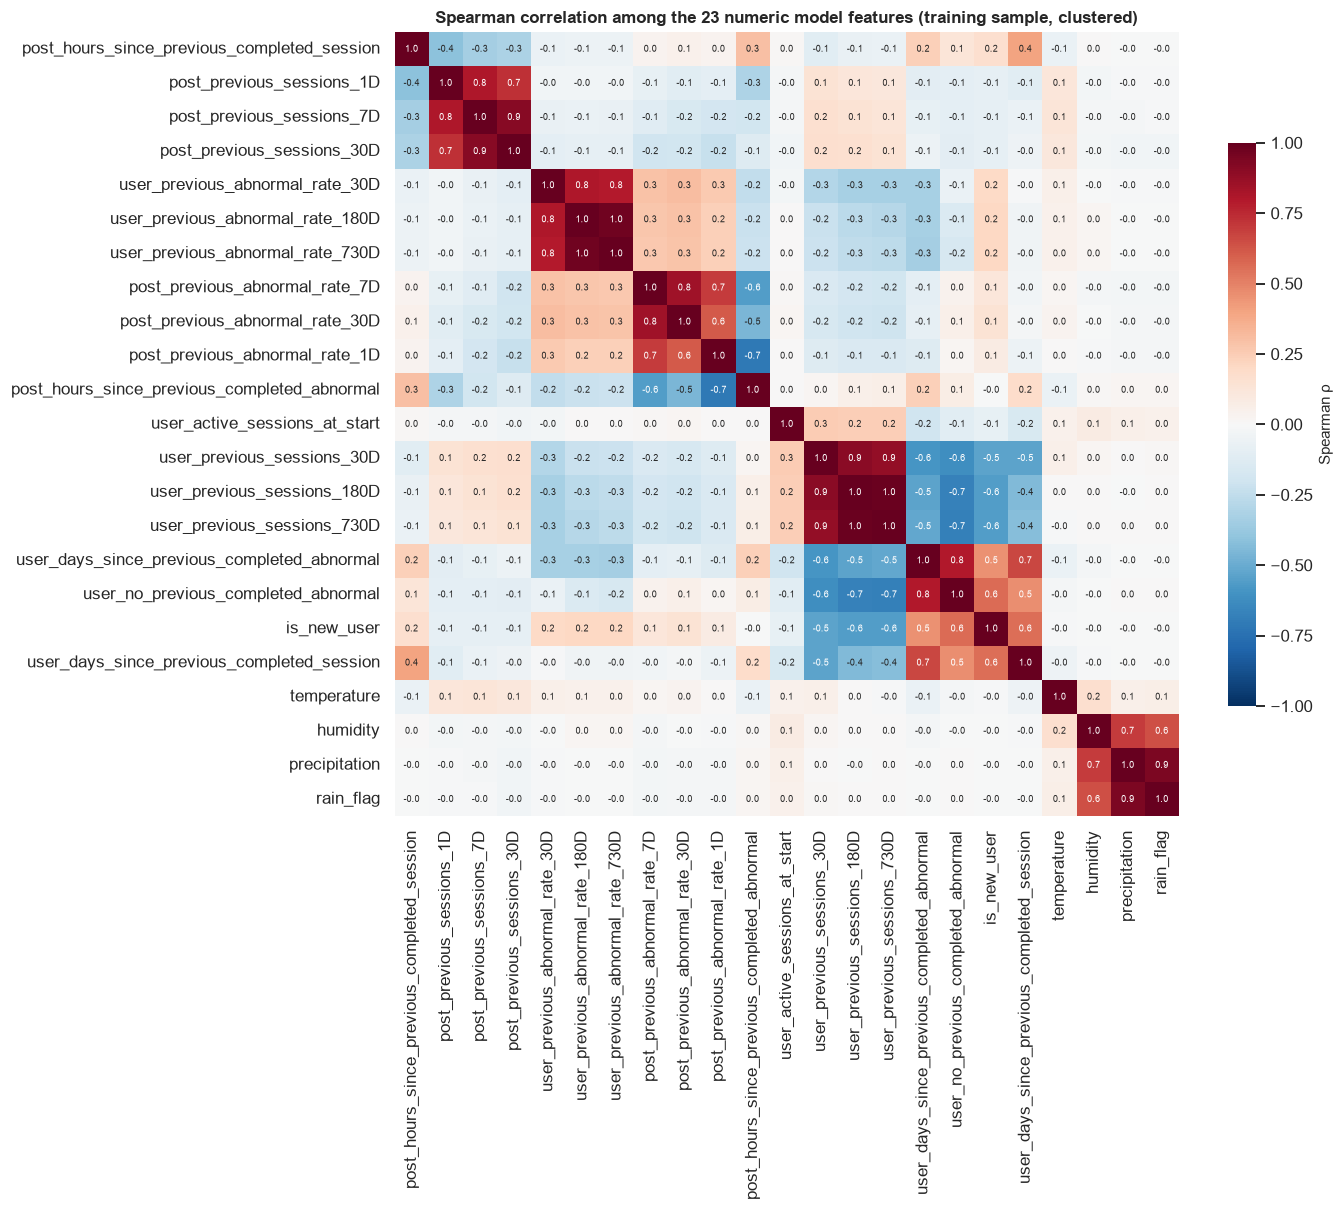

Pairs with |ρ| ≥ 0.85: 6


feature A,feature B,rho
user_previous_sessions_180D,user_previous_sessions_730D,0.988
user_previous_abnormal_rate_180D,user_previous_abnormal_rate_730D,0.969
precipitation,rain_flag,0.939
post_previous_sessions_7D,post_previous_sessions_30D,0.909
user_previous_sessions_30D,user_previous_sessions_180D,0.905
user_previous_sessions_30D,user_previous_sessions_730D,0.876


In [47]:
# Rule for the log transformation (declared before looking at the result; parameters are learned on TRAIN only):
#   apply log1p to an UNBOUNDED, non-negative variable when its training skewness > 1 AND the transformation removes at least
#   half of the absolute skewness. Bounded rates (0-1) stay on their natural scale, and variables where the log barely helps
#   (or over-corrects) are left as they are.
UNBOUNDED = [c for c in NUMERIC if c not in BINARY and "rate" not in c and c not in ("temperature", "humidity")]
skew_tab = pd.DataFrame({"train skewness": TRAIN[UNBOUNDED].skew(), "skewness after log1p": np.log1p(TRAIN[UNBOUNDED]).skew()})
skew_tab["|skew| reduction"] = 1 - skew_tab["skewness after log1p"].abs() / skew_tab["train skewness"].abs()
skew_tab["log1p?"] = (skew_tab["train skewness"] > 1) & (skew_tab["|skew| reduction"] >= 0.5)
SKEW_LOG = skew_tab.index[skew_tab["log1p?"]].tolist()
display(skew_tab.sort_values("train skewness", ascending=False).style.format({"train skewness": "{:.2f}", "skewness after log1p": "{:.2f}", "|skew| reduction": "{:.0%}"}))
print(f"log1p is applied to {len(SKEW_LOG)} variables; the zero-inflated user_active_sessions_at_start (skewness 8.7 -> 5.8) is NOT log-transformed "
      "but handled by capping (§13); the bounded post/user rates keep their natural scale.")


def linear_numeric_matrix(frame: pd.DataFrame, fill: pd.Series | None = None) -> pd.DataFrame:
    """Numeric features for diagnostics: log1p on skewed columns, NaN -> column maximum (of the reference frame)."""
    x = frame[NUMERIC].copy()
    x[SKEW_LOG] = np.log1p(x[SKEW_LOG])
    return x.fillna(fill if fill is not None else x.max())


X_diag = linear_numeric_matrix(SAMPLE)
rho = X_diag.corr(method="spearman")

# reorder by hierarchical clustering so that blocks of redundant variables are visible
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import squareform
order = leaves_list(linkage(squareform(1 - rho.abs().to_numpy(), checks=False), method="average"))
rho_ord = rho.iloc[order, order]
fig, ax = plt.subplots(figsize=(11.5, 9.5))
sns.heatmap(rho_ord, cmap="RdBu_r", vmin=-1, vmax=1, center=0, square=True, cbar_kws={"label": "Spearman ρ", "shrink": .7}, ax=ax,
            annot=True, fmt=".1f", annot_kws={"fontsize": 6})
ax.set_title("Spearman correlation among the 23 numeric model features (training sample, clustered)")
savefig(fig, "12_1_spearman_correlation")

pairs = (rho.where(np.triu(np.ones(rho.shape, dtype=bool), 1)).stack().rename("rho").reset_index()
         .rename(columns={"level_0": "feature A", "level_1": "feature B"}))
pairs = pairs[pairs["rho"].abs() >= 0.85].sort_values("rho", key=np.abs, ascending=False)
print(f"Pairs with |ρ| ≥ 0.85: {len(pairs)}")
display(pairs.style.format({"rho": "{:.3f}"}).hide(axis="index"))

**Interpretation.**
* **The correlation structure is block-wise and the blocks follow the feature groups.** (i) The *user volume* block (30/180/730-day session counts, ρ = 0.88–0.99) is also tied to `is_new_user`, to the time-since variables and to `user_no_previous_completed_abnormal` (ρ = −0.4 to −0.7): they are different views of one latent dimension, *how experienced/active the account is*. (ii) The *user rate* block (ρ = 0.8–0.97). (iii) The *post rate* block (ρ = 0.6–0.8), which is negatively tied to `post_hours_since_previous_completed_abnormal` (−0.5 to −0.7): *recent failure intensity of the post*. (iv) The *post session-count* block (0.7–0.9). (v) *humidity–precipitation–rain flag* (0.6–0.94).
* **Only six pairs reach |ρ| ≥ 0.85**, and the highest (0.99) are windows of the *same* quantity. The three windows of the *post rate* are much less correlated with one another (0.6–0.8), confirming that they carry different time scales (§7.4).
* **Correlations between groups are low** (post rates vs user rates ≈ 0.2–0.3; weather and concurrency are essentially independent of everything else), so the groups behave as approximately separate sources of information — a prerequisite for the group-wise ablation of §15.

### 12.2 Variance Inflation Factor (multi-variable redundancy)

Pairwise correlations miss *combinations* of variables (course pro-tip). VIF regresses each feature on all the others: VIF > 10 indicates that the feature is almost a linear combination of the others (an R² > 0.9).

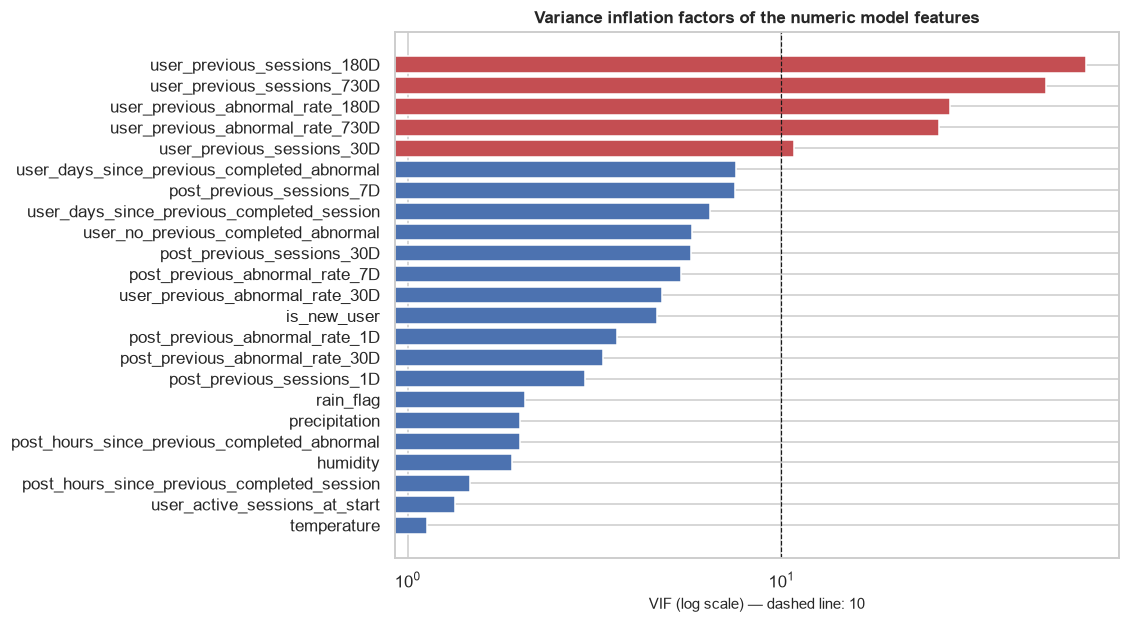

,user_previous_sessions_180D,user_previous_sessions_730D,user_previous_abnormal_rate_180D,user_previous_abnormal_rate_730D,user_previous_sessions_30D,user_days_since_previous_completed_abnormal,post_previous_sessions_7D,user_days_since_previous_completed_session,user_no_previous_completed_abnormal,post_previous_sessions_30D,post_previous_abnormal_rate_7D,user_previous_abnormal_rate_30D,is_new_user,post_previous_abnormal_rate_1D,post_previous_abnormal_rate_30D,post_previous_sessions_1D,rain_flag,precipitation,post_hours_since_previous_completed_abnormal,humidity,post_hours_since_previous_completed_session,user_active_sessions_at_start,temperature
VIF,65.4000,50.9000,28.3000,26.4000,10.8000,7.5000,7.5000,6.4000,5.8000,5.7000,5.4000,4.8000,4.7000,3.6000,3.3000,3.0000,2.1000,2.0000,2.0000,1.9000,1.5000,1.3000,1.1000


In [48]:
Xs = pd.DataFrame(StandardScaler().fit_transform(X_diag), columns=X_diag.columns)


def vif_series(X: pd.DataFrame) -> pd.Series:
    out = {}
    for c in X.columns:
        others = X.drop(columns=c).to_numpy()
        r2 = LinearRegression().fit(others, X[c].to_numpy()).score(others, X[c].to_numpy())
        out[c] = 1 / (1 - r2) if r2 < 1 - 1e-12 else np.inf
    return pd.Series(out)


vif = vif_series(Xs).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8.5, 6.2))
ax.barh(vif.index[::-1], vif.values[::-1], color=np.where(vif.values[::-1] > 10, C_ABN, C_NORMAL))
ax.axvline(10, color="k", ls="--", lw=.8); ax.set_xscale("log"); ax.set_xlabel("VIF (log scale) — dashed line: 10")
ax.set_title("Variance inflation factors of the numeric model features")
savefig(fig, "12_2_vif")
display(vif.round(1).to_frame("VIF").T)

**Interpretation.**
* **Only five of the 23 features exceed the usual VIF threshold of 10**, and all are *user-history windows*: `user_previous_sessions_180D` (65), `user_previous_sessions_730D` (51), `user_previous_abnormal_rate_180D` (28), `user_previous_abnormal_rate_730D` (26) and `user_previous_sessions_30D` (10.8). Every post-history variable has a VIF ≤ 7.5, weather ≤ 2.1 and calendar ≈ 1.
* The reason is structural: the file spans only two years and most accounts are short-lived, so the 730-day and the 180-day windows are practically the same set of sessions (ρ = 0.99). The long user windows add almost nothing *linearly* once the 30-day and 180-day windows are known.
* VIF measures *linear* redundancy; for tree-based models such a redundancy is harmless (course slide: trees "natively handle multicollinearity without performance loss").

### 12.3 What to do with the redundancy? (decision by model family)

Following the course's step-by-step strategy: **(1) assess the model type; (2) if a feature must go, keep the one with better target association, fewer missing values and cheaper collection; (3) alternatives: regularisation or PCA.**

A *pre-declared* rule is applied for the reduced set used by **unregularised** linear/distance models: iterate over the features from the highest to the lowest univariate AUC and keep a feature only if its |ρ| with every feature already kept is below **0.90**. The threshold is fixed *before* looking at the result. The full set (29 features) remains available for tree models and for regularised (L2/L1) linear models.

In [49]:
auc_diag = pd.Series({c: auc_symmetric(SAMPLE[TARGET], X_diag[c]) for c in NUMERIC}).sort_values(ascending=False)
kept, dropped = [], {}
for c in auc_diag.index:
    clash = [(k, abs(rho.loc[c, k])) for k in kept if abs(rho.loc[c, k]) >= 0.90]
    if clash:
        dropped[c] = max(clash, key=lambda t: t[1])
    else:
        kept.append(c)
reduction = pd.DataFrame([(c, auc_diag[c], f"|ρ| = {v:.2f} with {k}") for c, (k, v) in dropped.items()],
                         columns=["dropped (reduced linear set)", "univariate AUC", "reason"])
display(reduction.style.hide(axis="index").format({"univariate AUC": "{:.3f}"}))
LINEAR_REDUCED_NUMERIC = kept
print(f"\nReduced numeric set: {len(kept)} of {len(NUMERIC)} numeric features kept.")
vif_red = vif_series(pd.DataFrame(StandardScaler().fit_transform(X_diag[kept]), columns=kept))
print(f"Maximum VIF: full numeric set = {vif.max():.1f} → reduced set = {vif_red.max():.1f}")

dropped (reduced linear set),univariate AUC,reason
user_previous_abnormal_rate_730D,0.687,|ρ| = 0.97 with user_previous_abnormal_rate_180D
user_previous_sessions_180D,0.554,|ρ| = 0.99 with user_previous_sessions_730D
precipitation,0.508,|ρ| = 0.94 with rain_flag
post_previous_sessions_7D,0.505,|ρ| = 0.91 with post_previous_sessions_30D



Reduced numeric set: 19 of 23 numeric features kept.


Maximum VIF: full numeric set = 65.4 → reduced set = 8.6


**Interpretation.**
**Decision by model family.**
* **Tree-based models (the tree view): keep all 29 features.** Removing redundant windows would only lose potential threshold effects; speed is not a constraint (a full fit takes seconds).
* **Regularised linear models (L1/L2): keep all features**; the penalty stabilises the coefficients despite VIF > 10 (course slide: *regularisation when keeping both*).
* **Unregularised linear or distance-based models (e.g. k-NN, plain logistic regression): use the reduced numeric set of 19 features**, which removes `user_previous_abnormal_rate_730D` (ρ = 0.97 with the 180-day rate), `user_previous_sessions_180D` (ρ = 0.99 with the 730-day count), `precipitation` (ρ = 0.94 with `rain_flag`) and `post_previous_sessions_7D` (ρ = 0.91 with the 30-day count). The maximum VIF falls from 65 to 8.6. In every dropped pair the two members have almost the same univariate AUC (differences ≤ 0.002), so the choice by AUC is immaterial. A limitation is acknowledged: dropping `precipitation` in favour of the flag discards the *magnitude* of rain, whose effect is weak and not monotone (§7.3). In this reduced view the categorical variables are also reduced to `post_id` and `tariff_period`, because `location` and `district` are exact linear combinations of the `post_id` dummies (nested hierarchy).
* Two alternatives from the course remain open for the modelling task: *feature engineering* (e.g. the ratio between the 1-day and the 30-day post rate as a "trend" indicator) and *PCA*, evaluated next.

### 12.4 PCA — evaluated, not adopted

PCA is applied to the standardised numeric features (fitted on the training sample only) to measure how much of the variance a smaller set of components could summarise, following the course criterion (≈90% of the variance).

Components needed: 90% of the variance -> 11 of 23; 95% -> 14; first component explains 22.8%


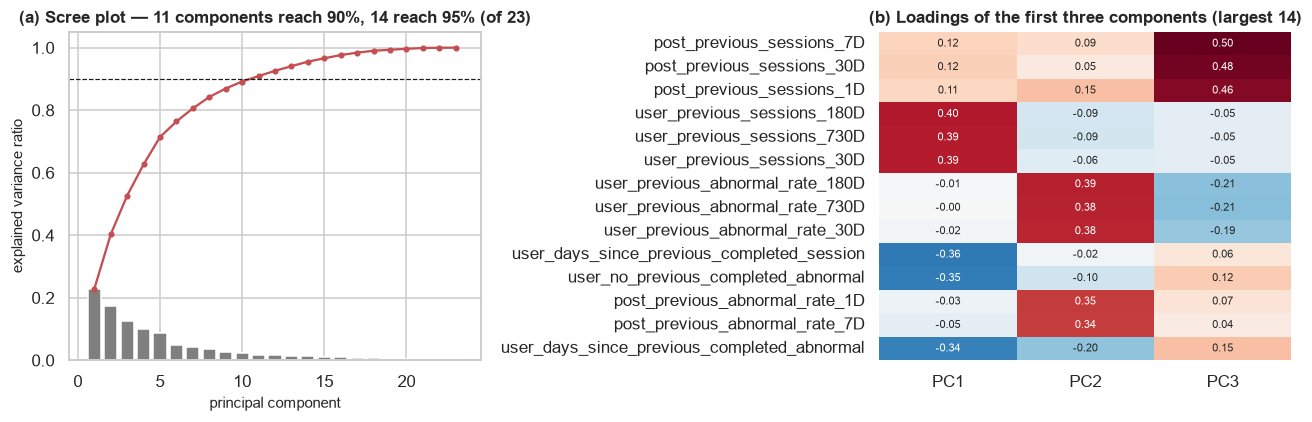

Univariate AUC of the first five components: {'PC1': 0.509, 'PC2': 0.803, 'PC3': 0.533, 'PC4': 0.501, 'PC5': 0.591}


In [50]:
pca = PCA(random_state=SEED).fit(Xs)
cum = np.cumsum(pca.explained_variance_ratio_)
k90, k95 = int(np.searchsorted(cum, 0.90) + 1), int(np.searchsorted(cum, 0.95) + 1)
print(f"Components needed: 90% of the variance -> {k90} of {Xs.shape[1]}; 95% -> {k95}; first component explains {pca.explained_variance_ratio_[0]:.1%}")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, len(cum) + 1), pca.explained_variance_ratio_, color=C_NEUTRAL)
axes[0].plot(range(1, len(cum) + 1), cum, "o-", color=C_ABN, ms=3)
axes[0].axhline(.9, color="k", ls="--", lw=.8); axes[0].set_xlabel("principal component"); axes[0].set_ylabel("explained variance ratio")
axes[0].set_title(f"(a) Scree plot — {k90} components reach 90%, {k95} reach 95% (of {Xs.shape[1]})")
load = pd.DataFrame(pca.components_[:3].T, index=Xs.columns, columns=["PC1", "PC2", "PC3"])
sns.heatmap(load.loc[load.abs().max(axis=1).sort_values(ascending=False).index[:14]], cmap="RdBu_r", center=0, annot=True, fmt=".2f", annot_kws={"fontsize": 7}, ax=axes[1], cbar=False)
axes[1].set_title("(b) Loadings of the first three components (largest 14)")
fig.tight_layout(); savefig(fig, "12_4_pca")
# does the leading component carry outcome information?
pcs = pca.transform(Xs)
print("Univariate AUC of the first five components:", {f"PC{i + 1}": round(auc_symmetric(SAMPLE[TARGET], pcs[:, i]), 3) for i in range(5)})

**Interpretation.**
* **The variance is spread over many dimensions**: 11 of the 23 components are needed to reach 90% of the variance (14 for 95%), so PCA offers little compression (23 → 11).
* **Variance is not predictive relevance.** The first component (22.8% of the variance) is the *user experience/volume* axis (loadings on the user counts and time-since variables) and has a univariate AUC of only **0.51**. The second component (≈17%) is the *failure-rate* axis (user rates and post rates) and has an AUC of **0.80 — higher than any single original variable (best 0.77)**: the discriminating signal lives in a combination of post- and user-level failure rates that is *not* the direction of maximal variance.
* **Decision: PCA is not adopted.** (i) The compression is modest; (ii) components mix post-level and user-level information, which would make the group ablation and the privacy assessment of user data impossible; (iii) the direction of maximal variance is irrelevant to the target; (iv) tree-based models do not need it. PCA remains a *diagnostic*; nothing fitted here is used downstream.

### 12.5 Filter diagnostics: mutual information and ANOVA F

Two *filter* statistics (course slides: filters rank features independently of any model) complement the univariate AUC. Mutual information also detects non-linear/non-monotone relations; ANOVA F assumes approximately normal features and is "less reliable when the target is imbalanced" (course slide), so it is shown for comparison only. They are **diagnostics** — no feature is selected automatically from them (the decision is the group ablation, §15) — and are computed on a subsample of the training sample.

In [51]:
from sklearn.feature_selection import f_classif

diag_idx = SAMPLE.sample(40_000, random_state=SEED).index
Xmi = linear_numeric_matrix(SAMPLE.loc[diag_idx])
for c in ["post_id"]:
    Xmi[c] = SAMPLE.loc[diag_idx, c].astype("category").cat.codes
Xmi["hour"] = SAMPLE.loc[diag_idx, "hour"]; Xmi["dow"] = SAMPLE.loc[diag_idx, "dow"]
ymi = SAMPLE.loc[diag_idx, TARGET]
discrete_mask = [c in BINARY + ["post_id", "hour", "dow"] for c in Xmi.columns]
mi = pd.Series(mutual_info_classif(Xmi, ymi, discrete_features=discrete_mask, random_state=SEED, n_neighbors=5), index=Xmi.columns)
fvals = pd.Series(f_classif(Xmi, ymi)[0], index=Xmi.columns)
filt = pd.DataFrame({"mutual information (nats)": mi, "ANOVA F": fvals})
filt["univariate AUC"] = {c: auc_symmetric(ymi, Xmi[c]) for c in Xmi.columns}
filt["group"] = [next(g for g, cols in GROUPS.items() if c in cols) for c in filt.index]
filt = filt.sort_values("mutual information (nats)", ascending=False)
display(filt.style.format({"mutual information (nats)": "{:.4f}", "ANOVA F": "{:,.0f}", "univariate AUC": "{:.3f}"}))
print("Spearman rank agreement between the three rankings (MI vs AUC / MI vs F):",
      round(stats.spearmanr(filt.iloc[:, 0], filt["univariate AUC"]).statistic, 2), "/", round(stats.spearmanr(filt.iloc[:, 0], filt.iloc[:, 1]).statistic, 2))

,mutual information (nats),ANOVA F,univariate AUC,group
post_previous_abnormal_rate_1D,0.0891,"10,664",0.763,post_history
post_previous_abnormal_rate_7D,0.0832,"9,720",0.767,post_history
post_previous_abnormal_rate_30D,0.0673,"6,722",0.754,post_history
post_hours_since_previous_completed_abnormal,0.0612,"4,749",0.735,post_history
post_id,0.0451,119,0.543,location
user_previous_abnormal_rate_30D,0.0431,"4,095",0.700,user_history
user_previous_abnormal_rate_180D,0.0391,"3,636",0.689,user_history
user_previous_abnormal_rate_730D,0.0387,"3,566",0.687,user_history
user_days_since_previous_completed_abnormal,0.0363,"1,243",0.649,user_history
user_days_since_previous_completed_session,0.0236,30,0.597,user_history


Spearman rank agreement between the three rankings (MI vs AUC / MI vs F): 0.77 / 0.77


**Interpretation.**
* **The three filters agree** (Spearman rank agreement between mutual information and AUC / ANOVA F: 0.77 / 0.77). The top of the ranking is occupied by the post failure rates (MI 0.067–0.089 nats) and `post_hours_since_previous_completed_abnormal` (0.061), followed by the user rates (0.039–0.043) and `user_days_since_previous_completed_abnormal` (0.036).
* `post_id` obtains MI 0.045, but the comparison is not fair to the continuous variables (a 92-level discrete variable has an upward-biased MI estimate), and its ANOVA F and AUC computed on arbitrary integer codes are meaningless — they are shown only for completeness.
* **Calendar, weather and concurrency have MI ≤ 0.006** (`hour` 0.001, `dow` 0.0002, `is_new_user` 0.0002), consistent with the weak effects seen in §7. Note the disagreement with ANOVA F for some user counts (F ≈ 160–180 with MI ≈ 0.001): F detects tiny linear mean differences in a very large sample, MI says they are negligible — another illustration of *significance ≠ relevance*.
* **No automatic selection is applied.** Marginal filters cannot see interactions (e.g. a weak variable that matters only for one post) or conditional redundancy (three windows of the same rate all rank high). The decision on which *groups* to keep is left to the ablation of §15, which measures the predictive contribution of each group inside a model.